In [1]:
import pandas as pd
import numpy as np
import pandas_ta as ta
pd.options.display.float_format = '{:.2f}'.format
pd.options.display.max_columns = None

from datetime import datetime, date
from dateutil.relativedelta import relativedelta
import time
import random

import yfinance as yf
import requests
from fredapi import Fred

from statsmodels.tsa.seasonal import STL
from sktime.utils.plotting import plot_correlations
from scipy.stats import randint, uniform, loguniform
from scipy.special import boxcox, inv_boxcox

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
plt.rcParams['figure.figsize'] = (18, 9)
plt.rcParams["figure.autolayout"] = True

from pmdarima import auto_arima
from get_data import DataMaker  # самодельная библиотека для сбора датасетов
from ml_models import *

import shap

from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import RobustScaler, StandardScaler, FunctionTransformer
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, make_scorer, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor

from sklearn.decomposition import PCA
from sklearn.exceptions import ConvergenceWarning

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, LSTM, GRU, Conv1D, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import backend as K

from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore')

In [6]:
day = pd.read_csv('new_day_df.csv', parse_dates=['Date'], index_col=['Date'])
hour = pd.read_csv('new_hour_df.csv', parse_dates=['Datetime'], index_col=['Datetime'])
week = pd.read_csv('new_week_df.csv', parse_dates=['Date'], index_col=['Date'])


[2025-05-29 06:12:24] Ridge начала обучаться



[2025-05-29 06:12:55] Ridge закончила обучаться

[2025-05-29 06:12:55] Lasso начала обучаться

[2025-05-29 06:12:59] Lasso закончила обучаться

[2025-05-29 06:12:59] ElasticNet начала обучаться

[2025-05-29 06:15:43] ElasticNet закончила обучаться


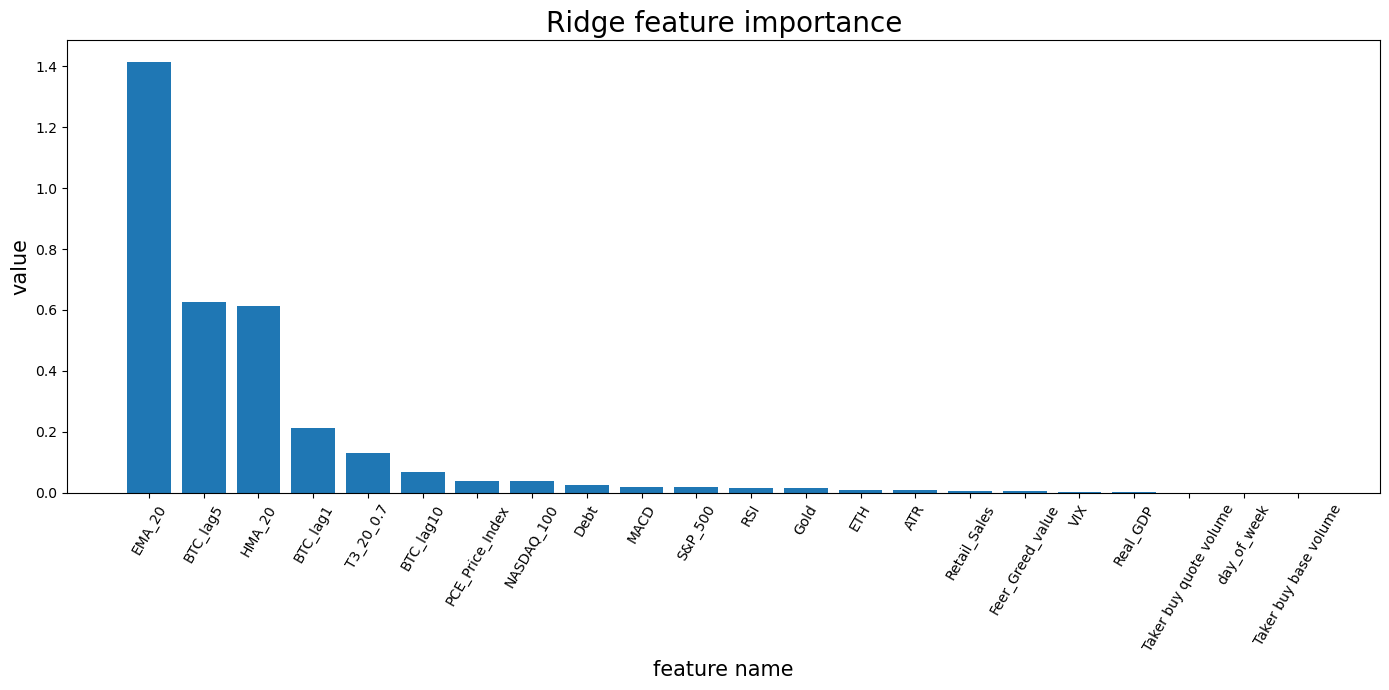

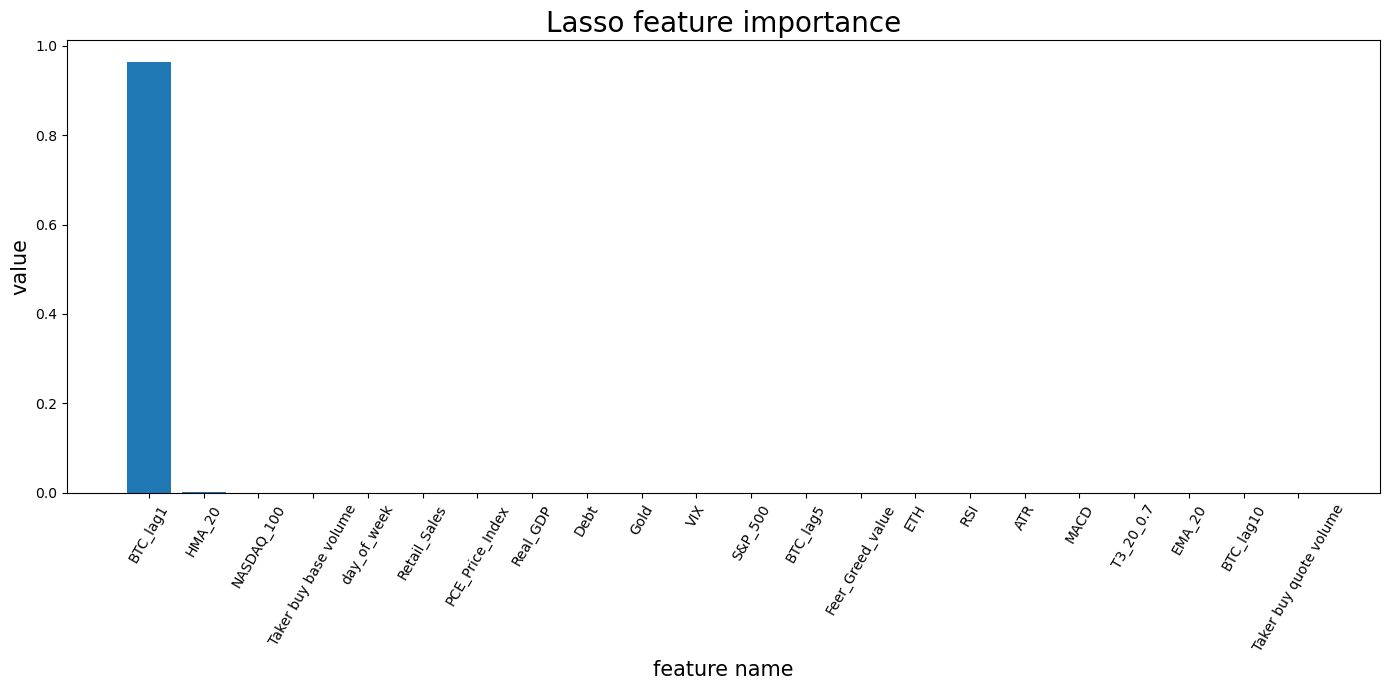

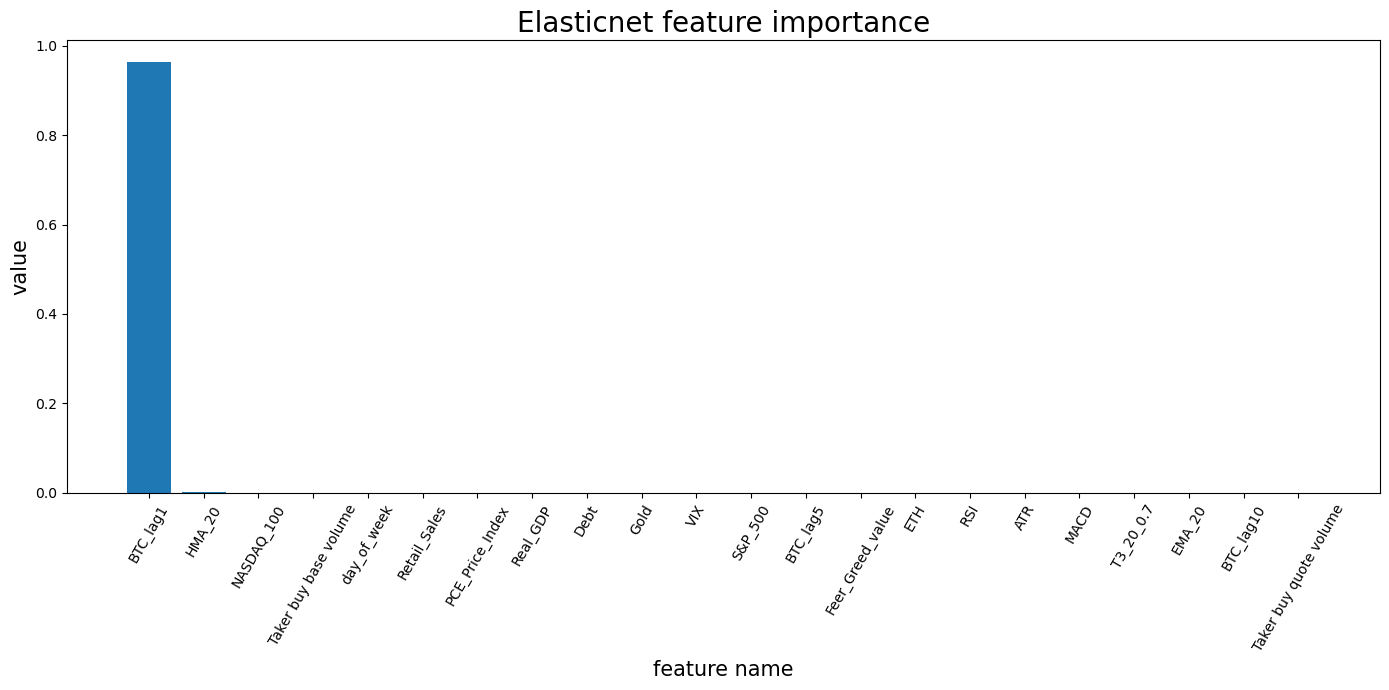

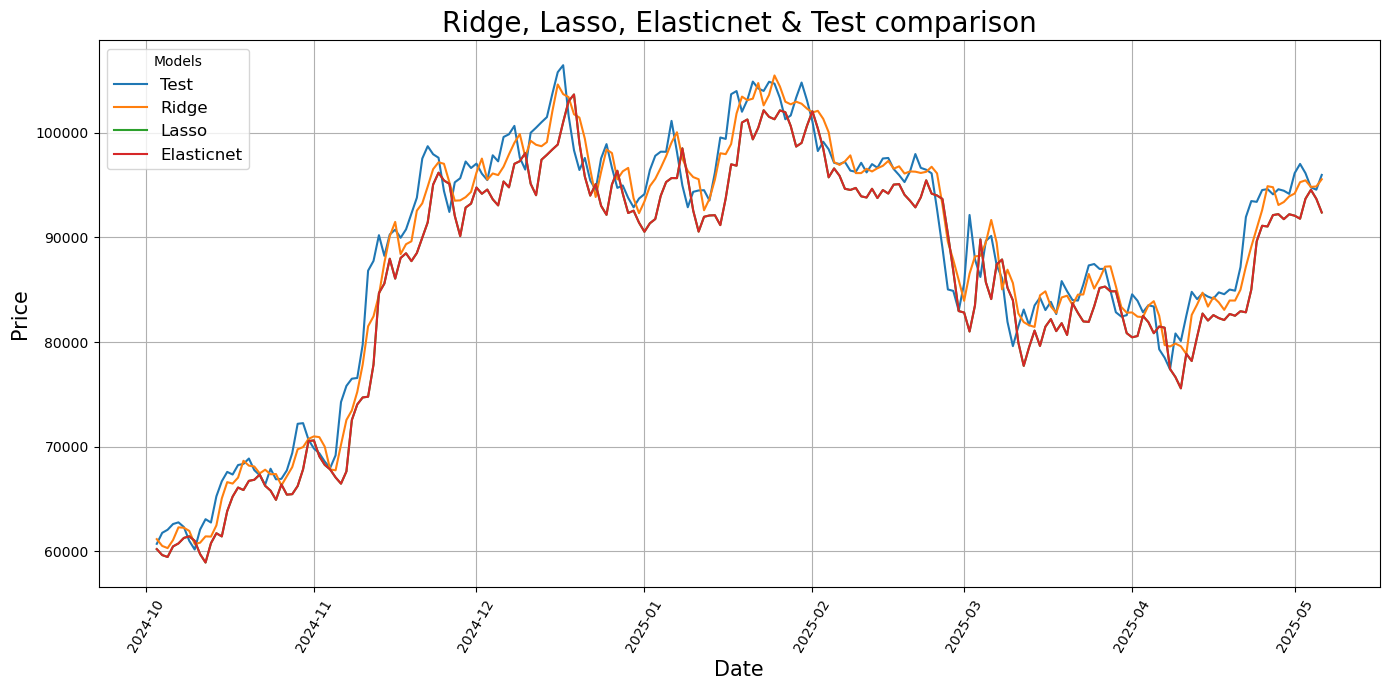

In [64]:
daily_features = [
    "BTC",
    "BTC_lag1", "BTC_lag5", "BTC_lag10",
    'EMA_20', 'HMA_20', 'T3_20_0.7',
    "MACD", "ATR", "RSI",
    "ETH", "Feer_Greed_value",
    'S&P_500', 'NASDAQ_100',
    "VIX", "Gold", 
    'Debt', 'Real_GDP', 'PCE_Price_Index', 'Retail_Sales',
    "day_of_week",
    'Taker buy base volume', 'Taker buy quote volume', 
]
daily = day[daily_features]


X_day, y_day = daily.drop(columns=['BTC']), daily['BTC']

ridge_day = LinearForecaster(
    test_size=216,
    model_type='Ridge'
)
ridge_day.fit(X_day, y_day)


lasso_day = LinearForecaster(
    test_size=216,
    model_type='Lasso'
)
lasso_day.fit(X_day, y_day)


elastic_day = LinearForecaster(
    test_size=216,
    model_type='ElasticNet'
)
elastic_day.fit(X_day, y_day)

def get_feature_importance(model, X: pd.DataFrame, top_n: int=None, make_plot: bool=True):
    """
    
    """
    feature_names = X.columns.tolist()

    lin_feature_importance = pd.DataFrame({
                                    'feature_names': feature_names,
                                    'feature_importance': np.abs(model.model_.best_estimator_.regressor_.named_steps['reg'].coef_)
                                }).sort_values(
                                    by='feature_importance', 
                                    ascending=False, 
                                    ignore_index=True
                                )
    
    if top_n is not None:
        lin_feature_importance = lin_feature_importance.head(top_n)
    
    if make_plot:

        plt.figure(figsize=(14, 7))
        plt.bar(
            x=lin_feature_importance['feature_names'], 
            height=lin_feature_importance['feature_importance']
        )

        plt.title(f'{model.model_type.capitalize()} feature importance', fontsize=20)
        plt.ylabel('value', fontsize=15)
        plt.xlabel('feature name', fontsize=15)

        plt.xticks(rotation=60)
        
        plt.show();

    return lin_feature_importance

ridge_feature_importance = get_feature_importance(model=ridge_day, X=X_day)
lasso_feature_importance = get_feature_importance(model=lasso_day, X=X_day)
elastic_feature_importance = get_feature_importance(model=elastic_day, X=X_day)

def make_plot(y, models, figsize: tuple=(14, 7)):
    """
    
    """
    if not isinstance(models, list): 
        models=[models]

    plt.figure(figsize=figsize)

    plt.plot(y.iloc[-models[0].test_size:], label='Test')

    for model in models:
        plt.plot(model.result_.y_pred, label=f'{model.model_type.capitalize()}')

    plt.title(f"{', '.join([model.model_type.capitalize() for model in models])} & Test comparison", fontsize=20)
    plt.ylabel('Price', fontsize=15)
    plt.xlabel('Date', fontsize=15)

    plt.xticks(rotation=60)

    plt.legend(title='Models', fontsize=12)
    plt.grid(True)

make_plot(y=y_day, models=[ridge_day, lasso_day, elastic_day])

In [65]:
lin_metrics = pd.DataFrame({
    'Ridge (Train)': ridge_day.result_.metrics['train'] ,
    'Ridge (Test)': ridge_day.result_.metrics['test'] ,

    'Lasso (Train)': lasso_day.result_.metrics['train'] ,
    'Lasso (Test)': lasso_day.result_.metrics['test'] ,

    'ElasticNet (Train)': elastic_day.result_.metrics['train'] ,
    'ElasticNet (Test)': elastic_day.result_.metrics['test'] ,
}, index=ridge_day.result_.metrics['train'].keys())

lin_metrics.index = map(lambda x: x.upper(), ridge_day.result_.metrics['train'].keys())
lin_metrics.loc['SMAPE'] = lin_metrics.loc['SMAPE'].apply(lambda smape: str(round(smape * 100, 4)) + '%')

lin_metrics

,Ridge (Train),Ridge (Test),Lasso (Train),Lasso (Test),ElasticNet (Train),ElasticNet (Test)
MAE,619.16,1521.48,1006.65,3076.75,1006.65,3076.75
RMSE,930.50,1972.68,1505.51,3736.63,1505.51,3736.63
SMAPE,3.0609%,1.7394%,5.0638%,3.5437%,5.0638%,3.5437%
MASE,1.23,3.03,2.00,6.13,2.00,6.13


In [115]:
scaler = RobustScaler()
X = sm.add_constant(X_day)
y = scaler.fit_transform(daily.BTC.values.reshape(-1, 1)).flatten()

# Шаг 2: обучаем регуляризованную модель
model = sm.OLS(y, X)
results_reg = model.fit_regularized(method='elastic_net', alpha=1.0, L1_wt=0.0)

# Шаг 3: отбираем переменные с ненулевыми коэффициентами
selected_columns = X.columns[(results_reg.params != 0)]

# Шаг 4: обучаем обычную OLS только на этих переменных
model_final = sm.OLS(scaler.inverse_transform(y.reshape(-1, 1)).flatten(), X[selected_columns])
results_final = model_final.fit(cov_type='HC3')

# Шаг 5: выводим p-values
print("P-values:")
print(results_final.pvalues.sort_values())

P-values:
EMA_20                   0.00
BTC_lag5                 0.00
MACD                     0.00
T3_20_0.7                0.00
BTC_lag10                0.00
BTC_lag1                 0.00
RSI                      0.00
HMA_20                   0.00
Feer_Greed_value         0.00
const                    0.03
Gold                     0.05
VIX                      0.06
PCE_Price_Index          0.18
Debt                     0.38
Taker buy base volume    0.44
ETH                      0.55
S&P_500                  0.57
ATR                      0.57
Taker buy quote volume   0.58
Retail_Sales             0.61
NASDAQ_100               0.74
day_of_week              0.95
Real_GDP                 0.99
dtype: float64


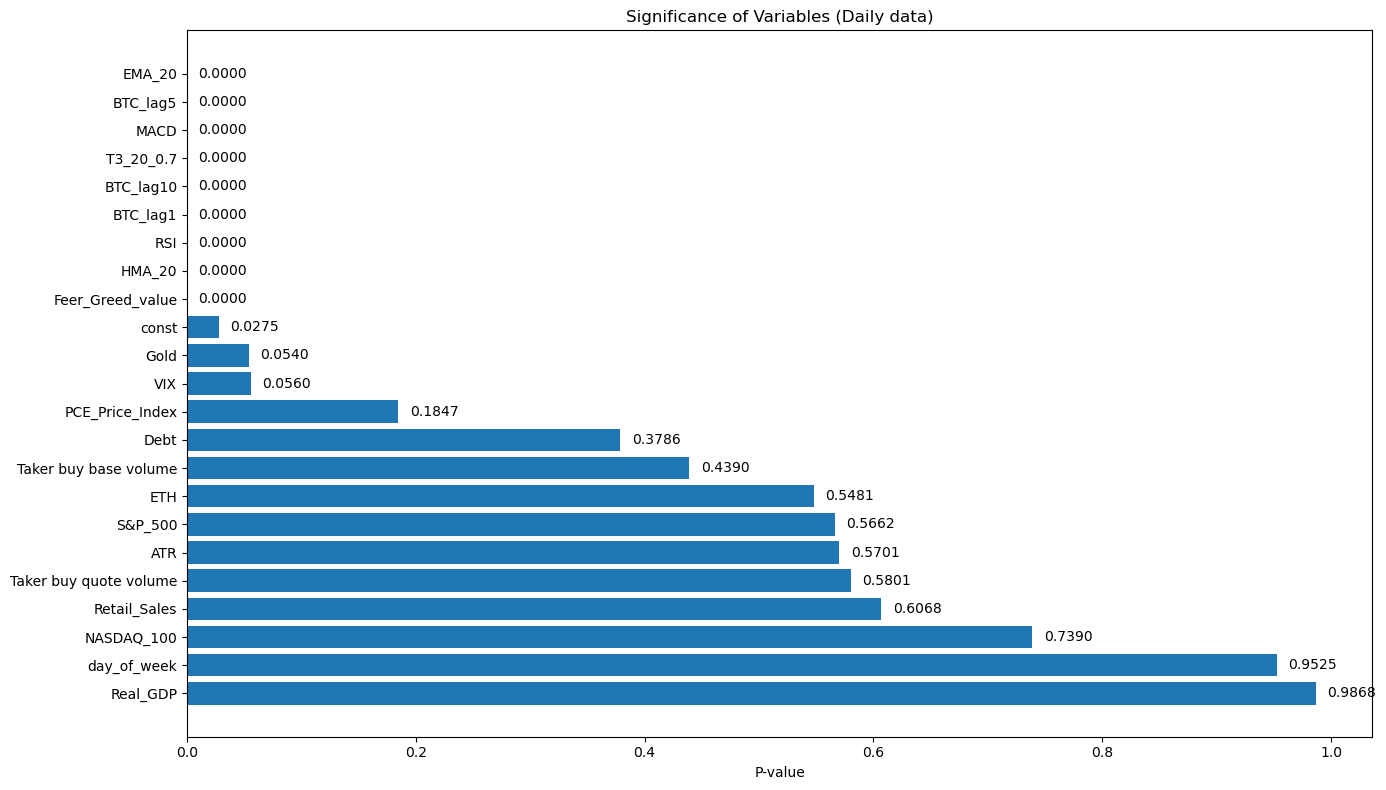

In [116]:
pvals = results_final.pvalues.sort_values()
plt.figure(figsize=(14, 8))
bars = plt.barh(pvals.index, pvals.values)
plt.xlabel('P-value')
plt.title('Significance of Variables (Daily data)')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.4f}', va='center')
plt.gca().invert_yaxis()
plt.tight_layout()

In [113]:
week.corr().BTC.abs().sort_values(ascending=False).iloc[5:55]

KAMA_10_2_30                  0.98
SMA_10                        0.98
ALMA_8_6.0_0.85               0.96
SPDR_Financials               0.93
S&P_500                       0.93
NASDAQ_100                    0.93
Invesco_QQQ                   0.92
TRON                          0.92
SPDR_Consumer_Discretionary   0.92
Dow_Jones                     0.92
Google                        0.92
VanEck_Semiconductor_ETF      0.91
SPDR_Industrials              0.91
SPDR_Tech                     0.90
Meta                          0.90
MicroStrategy                 0.89
iShares_Semiconductor_ETF     0.89
Amazon                        0.88
Microsoft                     0.87
Gold                          0.86
NVIDIA                        0.86
Silver                        0.86
Apple                         0.84
SPDR_Materials                0.84
ETH                           0.84
Copper                        0.81
SPDR_HealthCare               0.81
Debt                          0.80
year                

In [ ]:
hourly_features = [
    # Таргет
    "BTC",
    # Кросс-крипто
    "ETH",
    "XRP",
    # Лаги и скользящие характеристики BTC
    "BTC_lag1",
    "BTC_lag2",
    "BTC_lag5",
    "BTC_mean5",
    "BTC_std10",
    # Технические индикаторы
    "RSI",
    "MACD",
    "ATR",
    "OBV",
    "SMA_50",
    "EMA_100",
    "TEMA_20",
    "KAMA_20",
    "HMA_10",
    "SSF_20_2",
    "ZL_EMA_20",
    "VIDYA_20",
    # Объёмы и флоу
    "Volume",
    "Taker buy base volume",
    "Taker buy quote volume",
    # Временные признаки
    "hour",      # часовой сегмент (0–23)
    "day",       # день недели или месяца
]

hour


[2025-05-29 07:25:29] Ridge начала обучаться

[2025-05-29 07:25:31] Ridge закончила обучаться

[2025-05-29 07:25:31] Lasso начала обучаться

[2025-05-29 07:25:34] Lasso закончила обучаться

[2025-05-29 07:25:34] ElasticNet начала обучаться

[2025-05-29 07:27:06] ElasticNet закончила обучаться


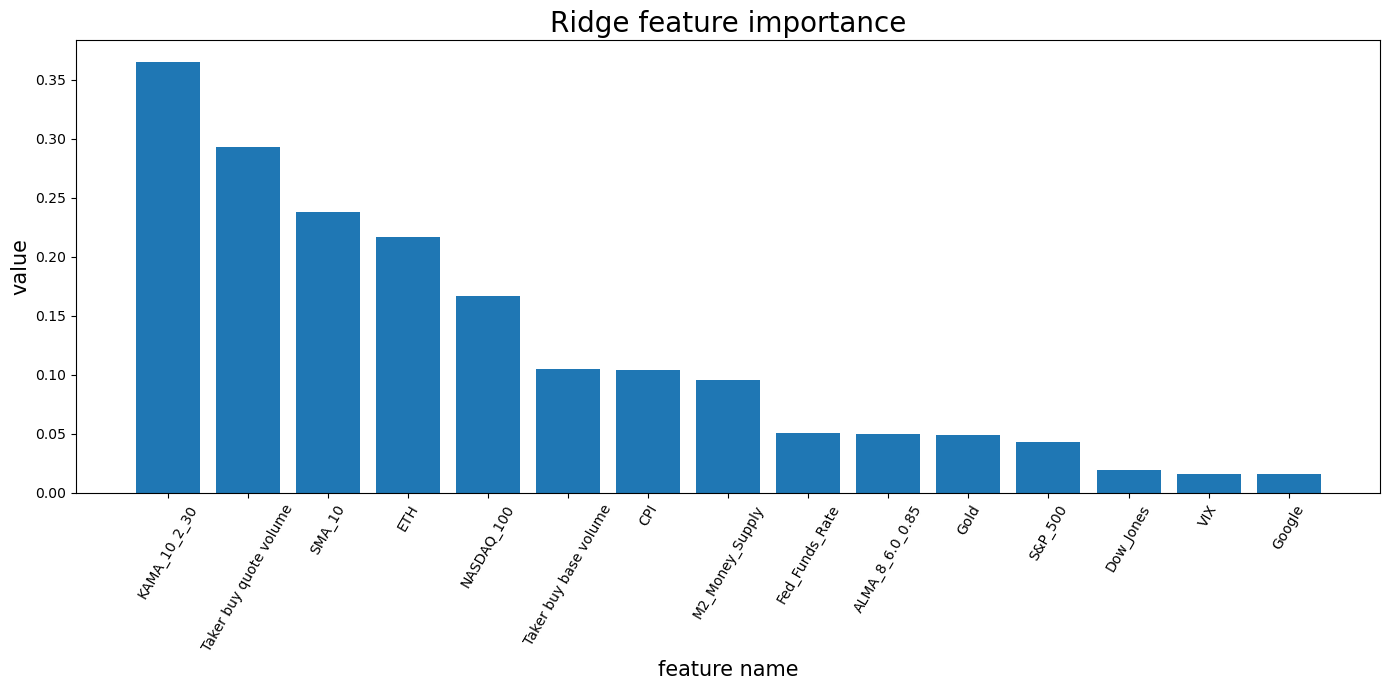

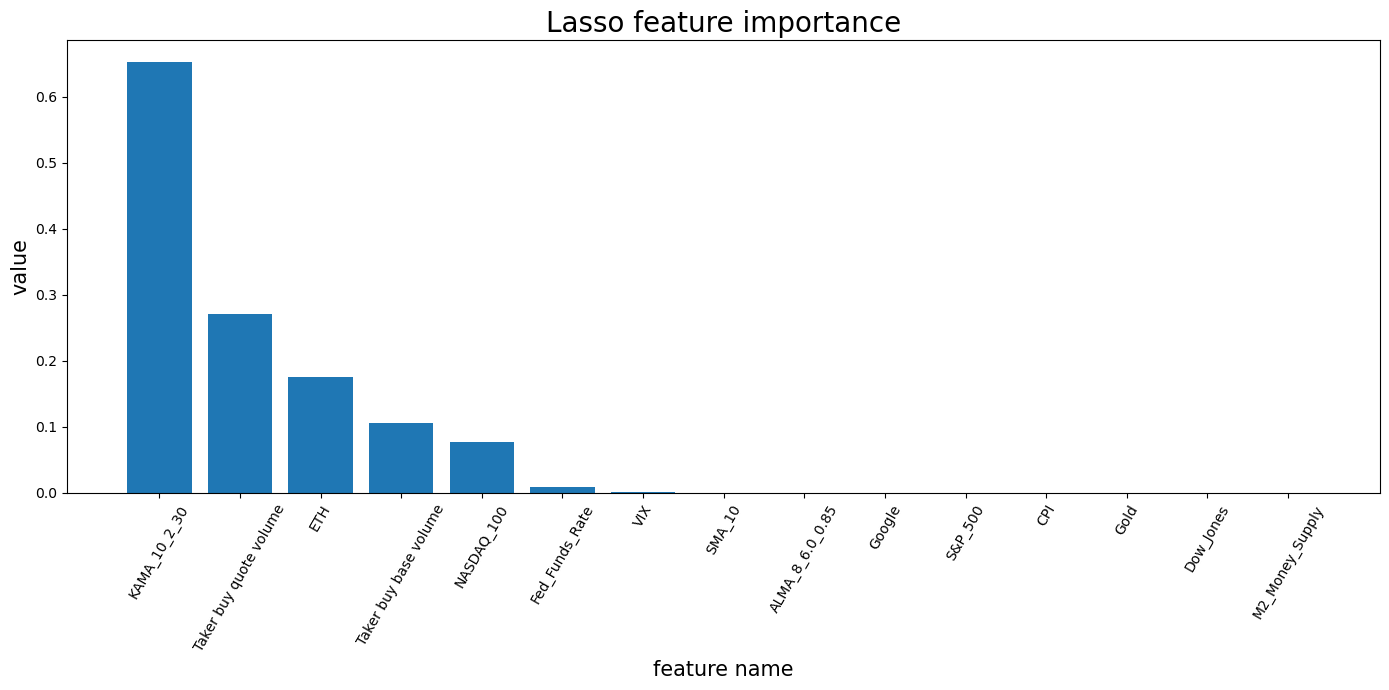

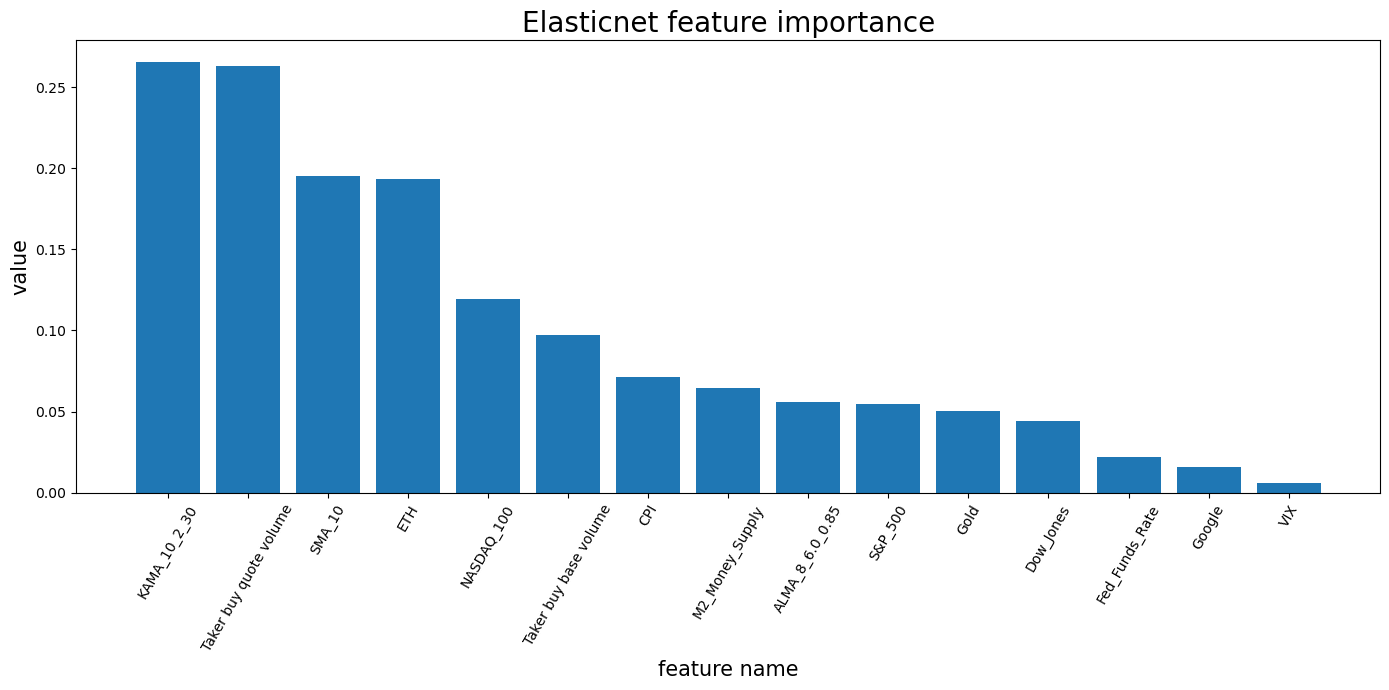

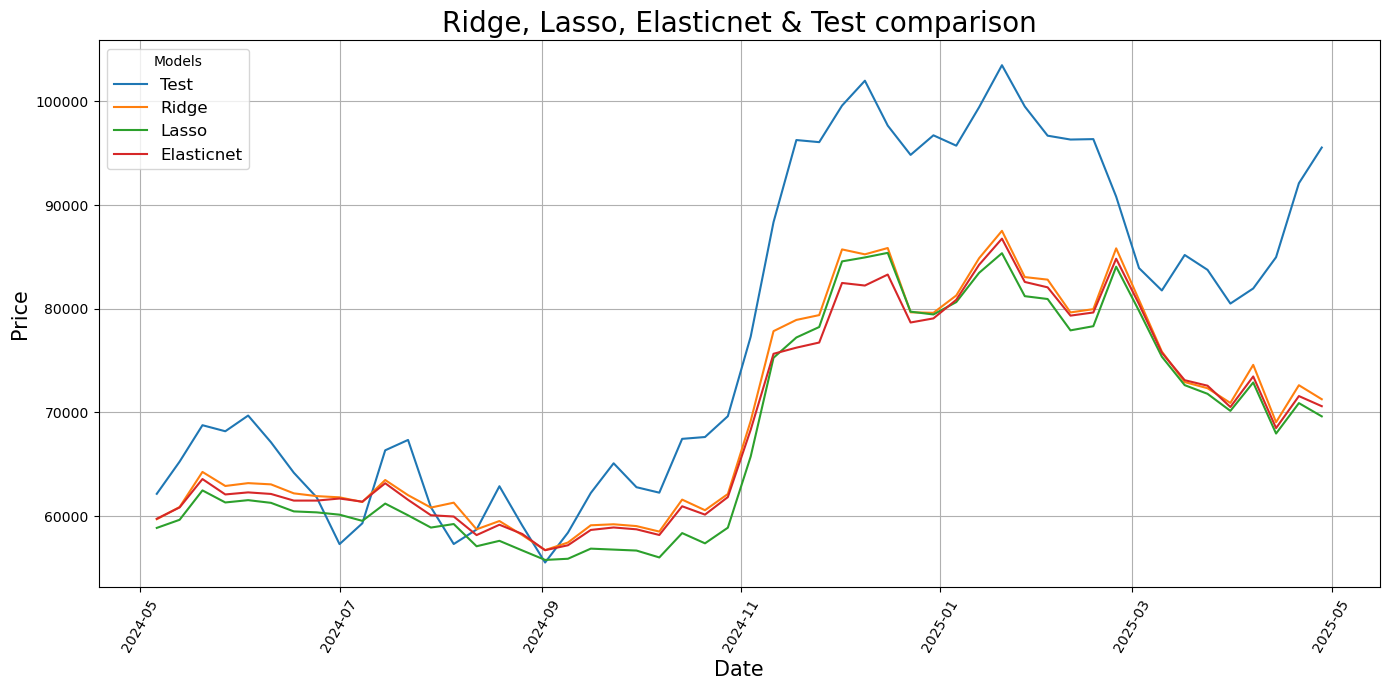

In [114]:
weekly_features = [
    "BTC",
    'SMA_10', 'KAMA_10_2_30',  'ALMA_8_6.0_0.85',
    "ETH", 'Google',
    'S&P_500', 'NASDAQ_100',
    "Fed_Funds_Rate", "CPI", "Gold", 'Dow_Jones', 'M2_Money_Supply', "VIX",
    "Taker buy base volume", "Taker buy quote volume"
]
weekly = week[weekly_features]


X_week, y_week = weekly.drop(columns=['BTC']), weekly['BTC']

ridge_week = LinearForecaster(
    test_size=52,
    model_type='Ridge'
)
ridge_week.fit(X_week, y_week)


lasso_week = LinearForecaster(
    test_size=52,
    model_type='Lasso'
)
lasso_week.fit(X_week, y_week)


elastic_week = LinearForecaster(
    test_size=52,
    model_type='ElasticNet'
)
elastic_week.fit(X_week, y_week)

ridge_week_feature_importance = get_feature_importance(model=ridge_week, X=X_week)
lasso_week_feature_importance = get_feature_importance(model=lasso_week, X=X_week)
elastic_week_feature_importance = get_feature_importance(model=elastic_week, X=X_week)

make_plot(y=y_week, models=[ridge_week, lasso_week, elastic_week])

In [117]:
scaler = RobustScaler()
X = sm.add_constant(X_week)
y = scaler.fit_transform(weekly.BTC.values.reshape(-1, 1)).flatten()

# Шаг 2: обучаем регуляризованную модель
model = sm.OLS(y, X)
results_reg = model.fit_regularized(method='elastic_net', alpha=1.0, L1_wt=0.0)

# Шаг 3: отбираем переменные с ненулевыми коэффициентами
selected_columns = X.columns[(results_reg.params != 0)]

# Шаг 4: обучаем обычную OLS только на этих переменных
model_final = sm.OLS(scaler.inverse_transform(y.reshape(-1, 1)).flatten(), X[selected_columns])
results_final = model_final.fit(cov_type='HC3')

# Шаг 5: выводим p-values
print("P-values:")
print(results_final.pvalues.sort_values())

P-values:
ALMA_8_6.0_0.85          0.00
SMA_10                   0.00
KAMA_10_2_30             0.00
NASDAQ_100               0.00
ETH                      0.00
M2_Money_Supply          0.00
S&P_500                  0.00
Taker buy quote volume   0.01
Gold                     0.03
Taker buy base volume    0.04
CPI                      0.06
VIX                      0.10
Dow_Jones                0.11
Fed_Funds_Rate           0.16
Google                   0.24
const                    0.53
dtype: float64


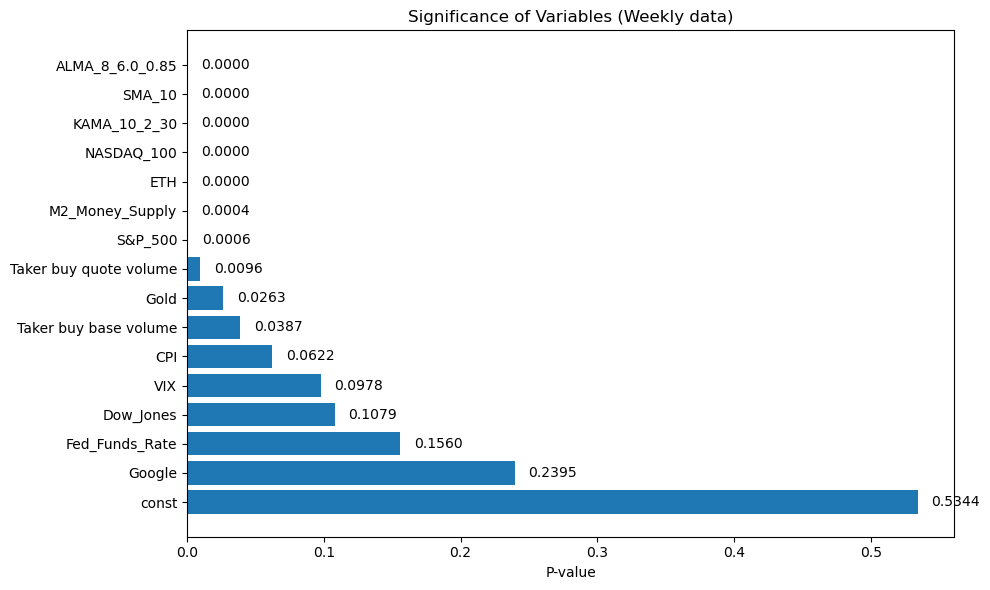

In [118]:
pvals = results_final.pvalues.sort_values()
plt.figure(figsize=(10, 6))
bars = plt.barh(pvals.index, pvals.values)
plt.xlabel('P-value')
plt.title('Significance of Variables (Weekly data)')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.4f}', va='center')
plt.gca().invert_yaxis()
plt.tight_layout()

# Сбор данные и EDA

In [2]:
dm = DataMaker(
    start_date='2018-01-01',
    end_date=date.today(),
    fred_api_key='6a6f2223ac49bf0fbb489f73a509bb18'
)

# # каждая из функций формирует датафреймы соответствующей частоты
# minute = dm.build_minute_dataset()
# hour = dm.build_hourly_dataset()

# day = dm.build_daily_dataset()
# week = dm.build_weekly_dataset()


# # перезапись имеющихся датасетов, в случае необходимости
# minute.to_csv('minute_df.csv')
# hour.to_csv('hour_df.csv')
# day.to_csv('day_df.csv')
# week.to_csv('week_df.csv')

In [ ]:
import os
import time
import requests
import pandas as pd
from datetime import datetime, timedelta

def fetch_historical_btc_dominance(
    start_date: str = "2018-01-01",
    end_date: str   = None,
    interval: str   = "daily",
    sleep: float    = 1.0
) -> pd.DataFrame:
    """
    Собирает исторические данные Bitcoin Dominance (%)
    из CoinMarketCap API.

    Параметры:
    - start_date: начало периода в "YYYY-MM-DD"
    - end_date:   конец периода в "YYYY-MM-DD" (по умолчанию — сегодня)
    - interval:   'hourly', 'daily', 'weekly' или 'monthly'
    - sleep:      пауза между обращениями к API (сек.)
    
    Требуется задать переменную окружения CMC_API_KEY с вашим API-ключом.
    """
    api_key = os.getenv("CMC_API_KEY")
    if not api_key:
        raise ValueError("Не найден CMC_API_KEY в окружении")

    if end_date is None:
        end_date = datetime.utcnow().strftime("%Y-%m-%d")

    url = "https://pro-api.coinmarketcap.com/v1/global-metrics/quotes/historical"
    headers = {
        "Accepts": "application/json",
        "X-CMC_PRO_API_KEY": api_key,
    }
    params = {
        "time_start": start_date,
        "time_end":   end_date,
        "interval":   interval
    }

    # Если данных слишком много, можно разбить на чанки по 1000 точек:
    # здесь для простоты делаем один запрос
    resp = requests.get(url, headers=headers, params=params, timeout=10)
    resp.raise_for_status()
    data = resp.json()

    # Парсим массив точек
    records = []
    for point in data["data"]["quotes"]:
        records.append({
            "timestamp": point["timestamp"],
            "btc_dominance": point.get("btc_dominance")
        })

    # Преобразуем в DataFrame
    df = pd.DataFrame(records)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df.set_index("timestamp", inplace=True)
    df.sort_index(inplace=True)
    return df




In [3]:
# api yahoo finance стало работать с переменным успехом, из-за чего была необходимость в доп. ф-ии

def fetch_all_binance_btc(
        start_date="2018-01-01", 
        end_date=None, 
        interval: str='1d'
):
    """
    собирает данные с официального api биржи Binance
    способна собирать информацию по большинству активов. используем для сбора данных по BTC

    `start_date`: str, начальная дата
    `end_date`: str, последняя дата
    `interval`: str, частота данных ('1h', '1d', '1w') 
    """
    if end_date is None:
        end_date = datetime.now().strftime("%Y-%m-%d")
    
    start_timestamp = int(pd.Timestamp(start_date).timestamp() * 1000)
    end_timestamp = int(pd.Timestamp(end_date).timestamp() * 1000)

    url = "https://api.binance.com/api/v3/klines"
    all_data = []

    while start_timestamp < end_timestamp:
        
        time.sleep(3)

        params = {
            "symbol": "BTCUSDT",
            "interval": interval,
            "startTime": start_timestamp,
            "endTime": end_timestamp,
            "limit": 1000  
        }

        response = requests.get(url, params=params)
        data = response.json()

        if not data:
            break  

        all_data.extend(data)

        last_candle_time = data[-1][0]
        start_timestamp = last_candle_time + 1

        last_date = pd.to_datetime(last_candle_time, unit="ms").strftime("%Y-%m-%d")
        print(f"Fetched data up to {last_date}")

    columns = [
        "Open time", "Open", "High", "Low", "Close", "Volume",
        "Taker buy base volume", "Taker buy quote volume", "Ignore"
    ]
    df = pd.DataFrame(all_data, columns=columns)

    df["Date"] = pd.to_datetime(df["Open time"], unit="ms")
    df = df[["Date", "Open", "High", "Low", "Close", "Volume", 
             "Taker buy base volume", "Taker buy quote volume"]]

    numeric_cols = ["Open", "High", "Low", "Close", "Volume", 
                    "Taker buy base volume", "Taker buy quote volume"]
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

    df = df.drop_duplicates(subset=["Date"]).sort_values("Date")

    return df

In [4]:
hour   = pd.read_csv('new_hour.csv',    index_col=['Datetime'], parse_dates=['Datetime'])
day    = pd.read_csv('day_df.csv',      index_col=['Date'],     parse_dates=['Date'])
week   = pd.read_csv('week_df.csv',     index_col=['Date'],     parse_dates=['Date'])

In [5]:
btc_hour = fetch_all_binance_btc(start_date=hour.index.min().strftime('%Y-%m-%d'),  interval='1h')
btc_day  = fetch_all_binance_btc(start_date=day.index.min().strftime('%Y-%m-%d'),   interval='1d')
btc_week = fetch_all_binance_btc(start_date=week.index.min().strftime('%Y-%m-%d'),  interval='1w')

Fetched data up to 2023-06-22
Fetched data up to 2023-08-03
Fetched data up to 2023-09-13
Fetched data up to 2023-10-25
Fetched data up to 2023-12-06
Fetched data up to 2024-01-16
Fetched data up to 2024-02-27
Fetched data up to 2024-04-09
Fetched data up to 2024-05-20
Fetched data up to 2024-07-01
Fetched data up to 2024-08-12
Fetched data up to 2024-09-22
Fetched data up to 2024-11-03
Fetched data up to 2024-12-15
Fetched data up to 2025-01-25
Fetched data up to 2025-03-08
Fetched data up to 2025-04-19
Fetched data up to 2025-05-11
Fetched data up to 2020-10-27
Fetched data up to 2023-07-24
Fetched data up to 2025-05-11
Fetched data up to 2025-05-05


In [6]:
indicators = {
    "W1": [
        {"indicator": "SMA",  "length": 10},
        {"indicator": "KAMA", "length": 10, "pow1": 2, "pow2": 30},
        {"indicator": "ALMA", "length": 8,  "offset": 0.85, "sigma": 6},
    ],
    "D1": [
        {"indicator": "EMA", "length": 20},
        {"indicator": "HMA", "length": 20},
        {"indicator": "T3",  "length": 20, "vfactor": 0.7},
    ],
    "H1": [
        {"indicator": "SSF",  "length": 20},
        {"indicator": "ZLMA", "length": 20},
        {"indicator": "VIDYA","length": 20, "r": 0.2},
    ],
}

df_map = {
    "W1": btc_week,
    "D1": btc_day,
    "H1": btc_hour,
}

for tf, configs in indicators.items():
    df = df_map[tf]
    
    for cfg in configs:

        name = cfg.pop("indicator")
        func = getattr(ta, name.lower())

        series = func(df["Close"], **cfg)

        df[series.name] = series

In [7]:
btc_week = btc_week[~btc_week.KAMA_10_2_30.isna()].shift(1).iloc[1:]
btc_day  = btc_day[~btc_day.HMA_20.isna()].shift(1).iloc[1:]
btc_hour = btc_hour[~btc_hour.VIDYA_20.isna()].shift(1).iloc[1:]

btc_week.set_index('Date', inplace=True)
btc_day.set_index('Date', inplace=True)
btc_hour.set_index('Date', inplace=True)

btc_week.index.name = 'Date'
btc_day.index.name = 'Date'
btc_hour.index.name = 'Datetime'

In [8]:
hour = pd.read_csv(
            'new_hour.csv',    
            index_col=['Datetime'], 
            parse_dates=['Datetime']).merge(
                        btc_hour, left_index=True, right_index=True
                    )
day = pd.read_csv(
            'day_df.csv',      
            index_col=['Date'],     
            parse_dates=['Date']).merge(
                            btc_day, left_index=True, right_index=True
                        )
week = pd.read_csv(
            'week_df.csv',     
            index_col=['Date'],     
            parse_dates=['Date']).merge(
                            btc_week, left_index=True, right_index=True
                        )

In [9]:
# hour.to_csv('new_hour_df.csv')
# day.to_csv('new_day_df.csv')
# week.to_csv('new_week_df.csv')

In [40]:
hour = pd.read_csv('new_hour_df.csv', parse_dates=['Datetime'], index_col=['Datetime'])
day = pd.read_csv('new_day_df.csv', parse_dates=['Date'], index_col=['Date'])

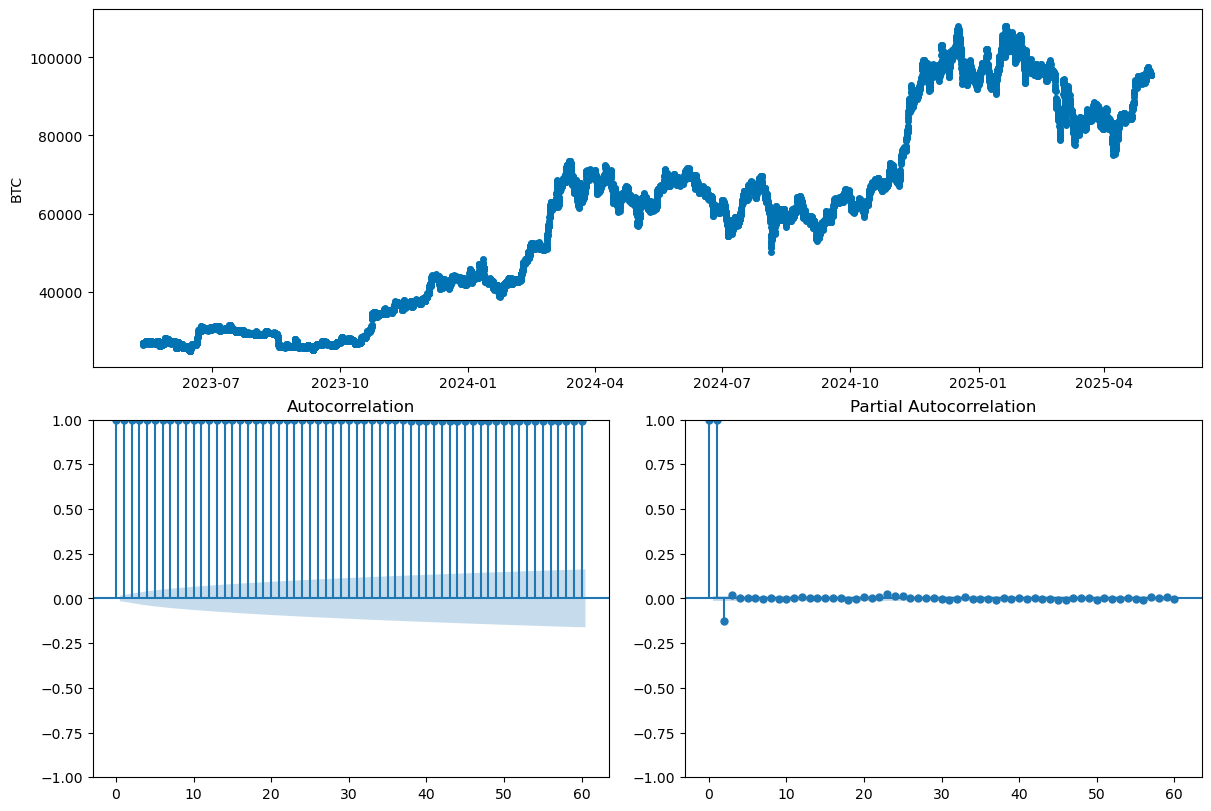

In [44]:
plot_correlations(hour.BTC, lags=60);

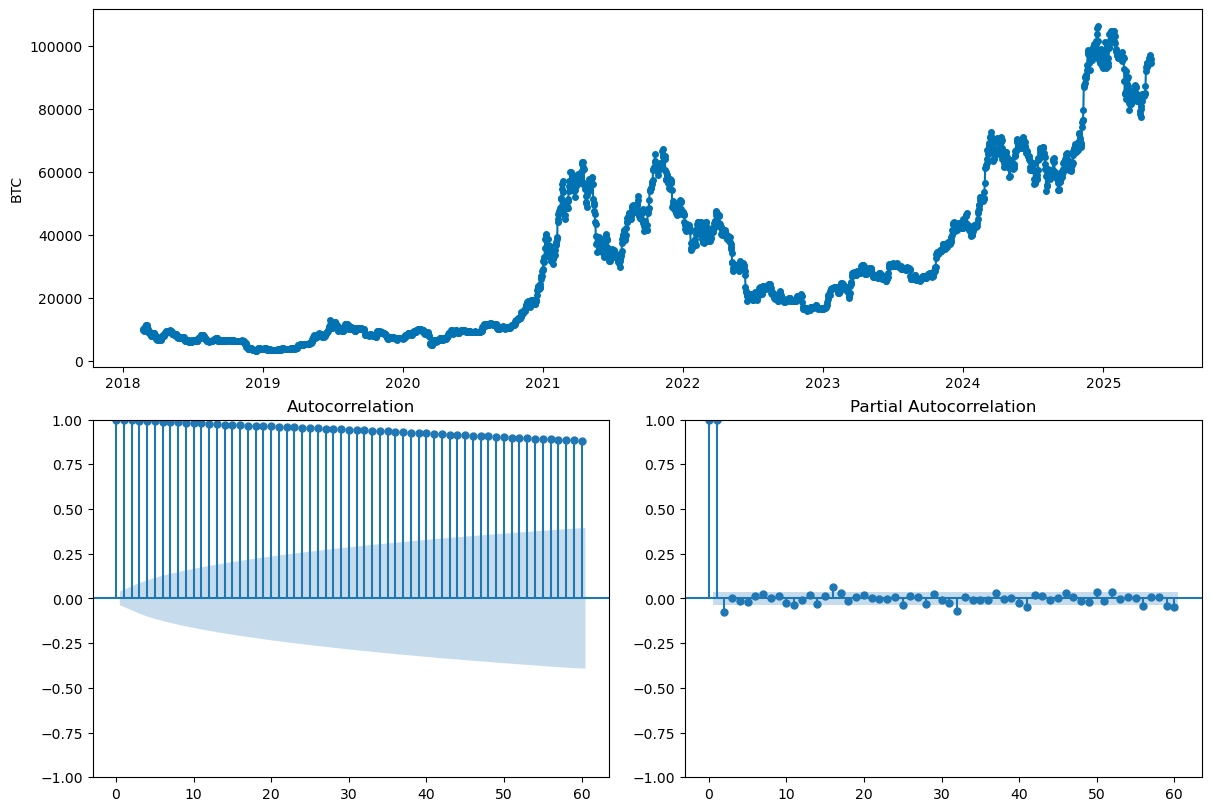

In [43]:
plot_correlations(day.BTC, lags=60);

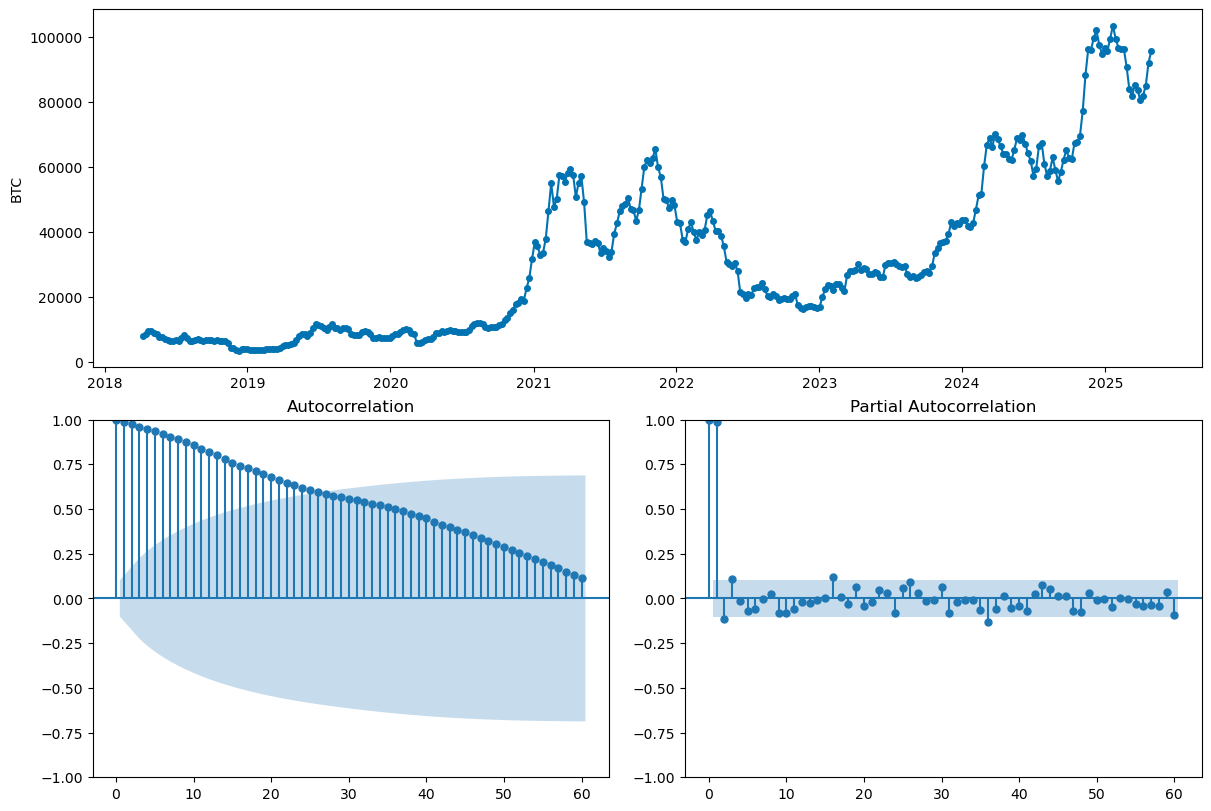

In [102]:
plot_correlations(week.BTC, lags=60);

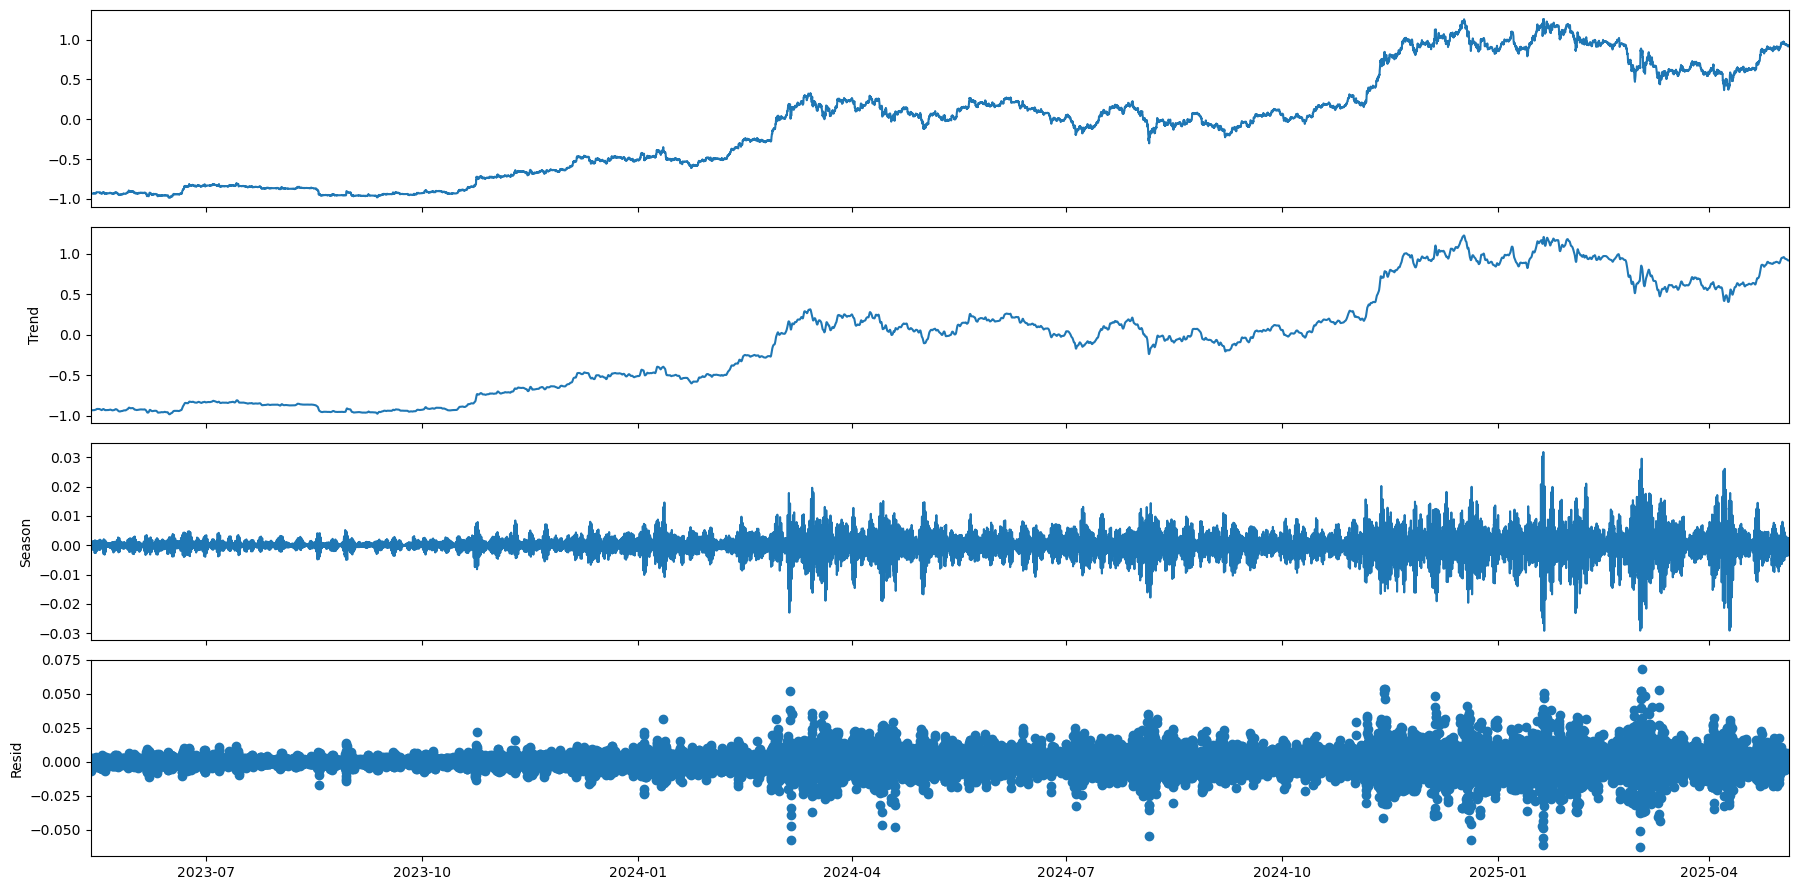

In [58]:
scaler = RobustScaler()

target=pd.Series(index=hour['BTC'].index, data=scaler.fit_transform(hour['BTC'].to_numpy().reshape(-1, 1)).flatten())

stl_hour = STL(target, period=12, )
stl_hour = stl_hour.fit()

stl_hour.plot();


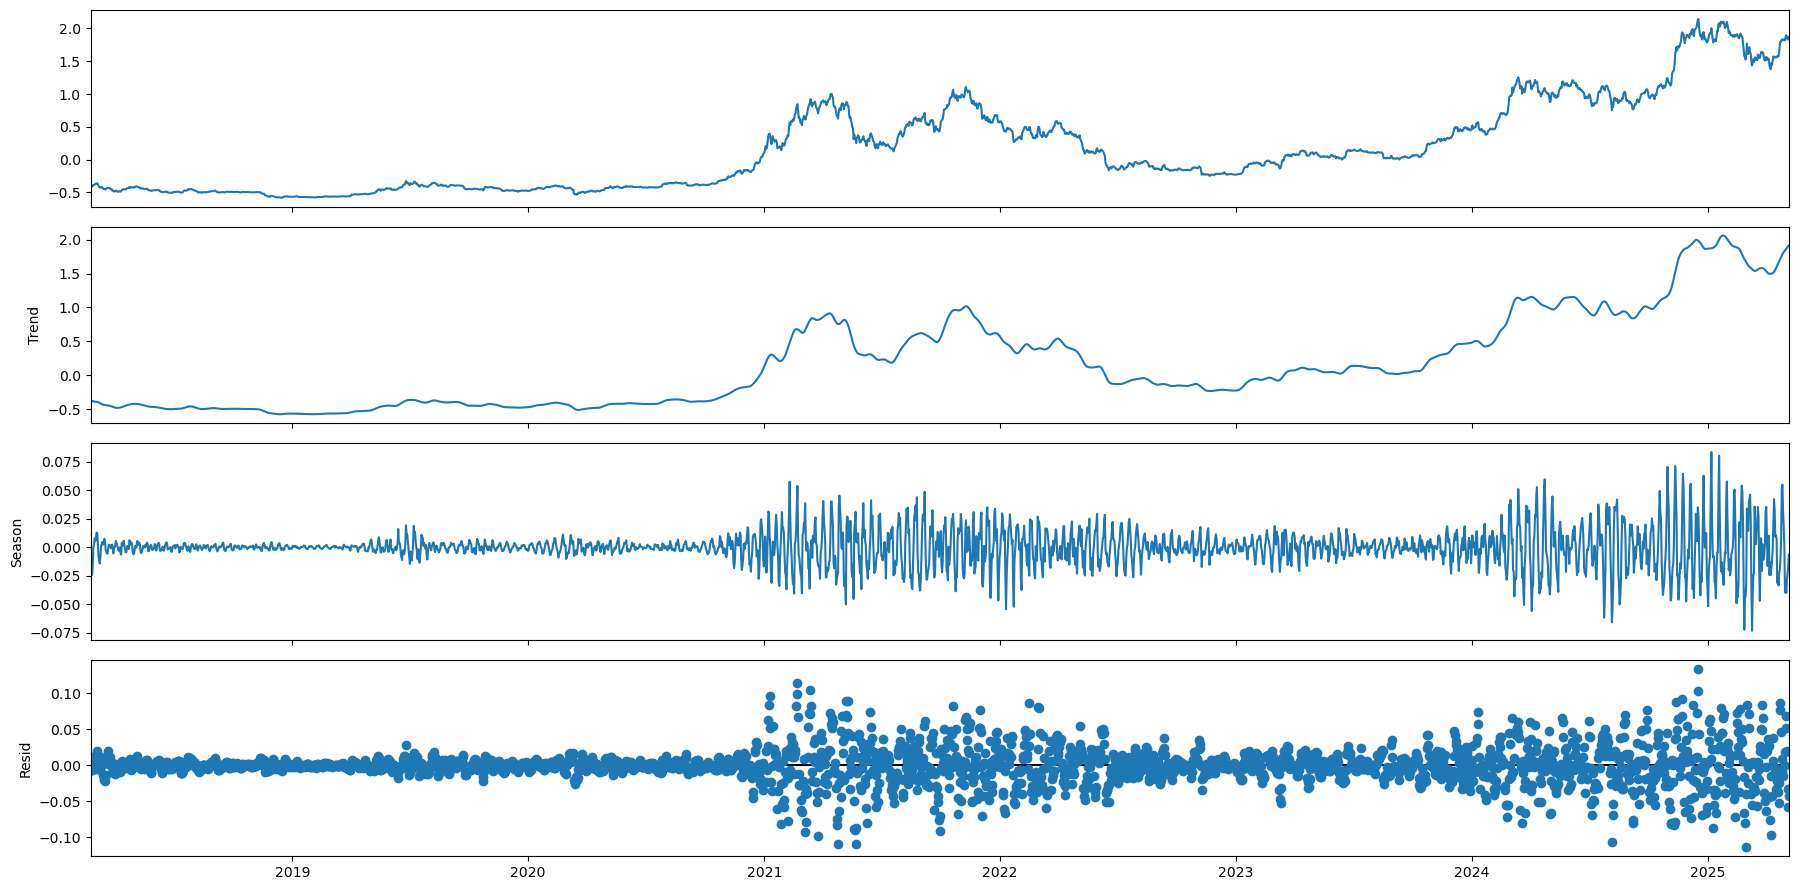

In [99]:
scaler = RobustScaler()

target=pd.Series(index=day['BTC'].index, data=scaler.fit_transform(day['BTC'].to_numpy().reshape(-1, 1)).flatten())

stl_hour = STL(target, period=12, )
stl_hour = stl_hour.fit()

stl_hour.plot();


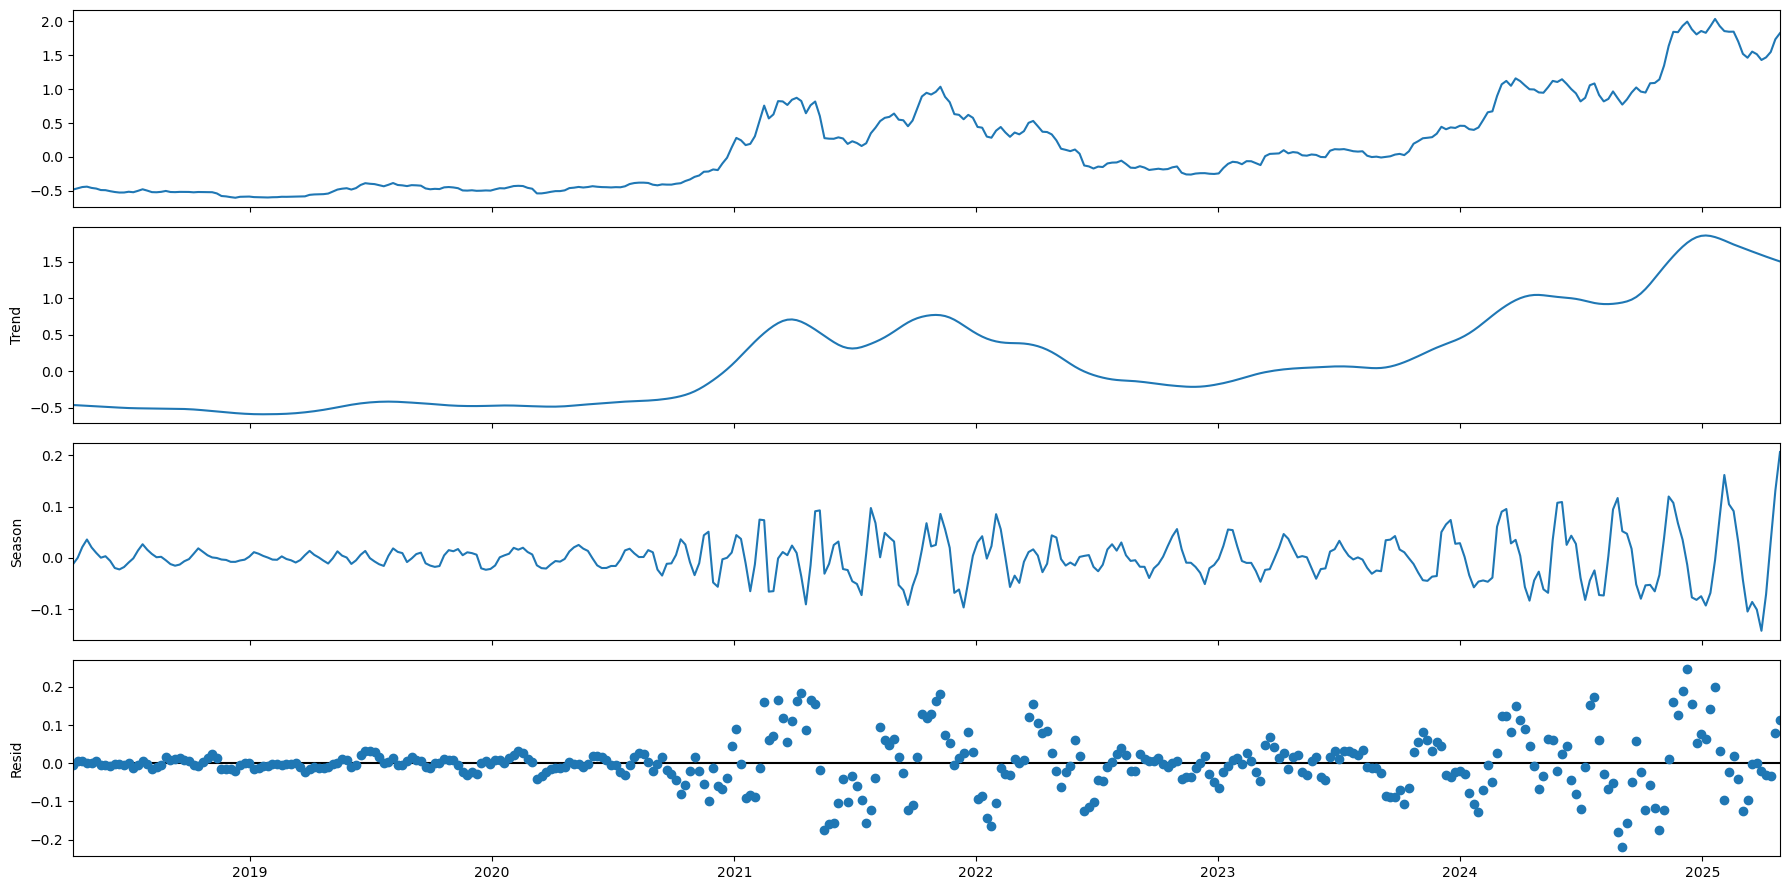

In [100]:
scaler = RobustScaler()

target=pd.Series(index=week['BTC'].index, data=scaler.fit_transform(week['BTC'].to_numpy().reshape(-1, 1)).flatten())

stl_hour = STL(target, period=12, )
stl_hour = stl_hour.fit()

stl_hour.plot();


In [10]:
# plt.figure(figsize=(25, 25))
# sns.heatmap(day.corr().abs());     # плохочитаемо, хоть и выводим сводку по первым двадцати признакам

In [11]:
corr_list = pd.DataFrame({      # попытка объединить большое кол-во признаков и объединить их по принципу скоррелированности
    name: day.corr().abs()[name].sort_values(ascending=False)[1:16].index.to_numpy()
        for name in day.columns
})

corr_list
# corr_list.to_csv('coor_list.csv')

,BTC,Apple,Cardano,Adobe,AMD,Amazon,ARKK_ETF,ARK_NextGen_Internet_ETF,AUD/USD,Bitcoin_Cash,Brent_Oil,USD/CHF,WTI,Dogecoin,Ethereum_Classic,ETH,EUR/USD,GBP/USD,Gold,Google,Copper,Intel,USD/JPY,Chainlink,Litecoin,Marathon_Digital,Meta,Microsoft,MicroStrategy,Natural_Gas,NVIDIA,Platinum,Invesco_QQQ,Riot_Blockchain,Silver,VanEck_Semiconductor_ETF,iShares_Semiconductor_ETF,TRON,Tesla,USD/CAD,Tether,SPDR_Materials,SPDR_Energy,SPDR_Financials,SPDR_Industrials,SPDR_Tech,Stellar,SPDR_RealEstate,SPDR_HealthCare,SPDR_Consumer_Discretionary,XRP,Dow_Jones,S&P_500,NASDAQ_100,VIX,RSI,MACD,ATR,OBV,Unemployment_Rate,Non_Farm_Payrolls,Initial_Jobless_Claims,CPI,PCE_Price_Index,Consumer_Confidence_Index,Retail_Sales,Housing_Starts,Building_Permits,M2_Money_Supply,Real_Interest_Rate,Fed_Funds_Rate,Reverse_Repo_Volume,Brent,Debt,Real_GDP,BTC_Supply,Feer_Greed_value,day,month,day_of_week,is_holiday,BTC_lag1,BTC_lag2,BTC_lag5,BTC_lag10,BTC_mean5,BTC_std10,Open,High,Low,Close,Volume,Taker buy base volume,Taker buy quote volume,EMA_20,HMA_20,T3_20_0.7
0,Close,SPDR_Tech,Marathon_Digital,AMD,iShares_Semiconductor_ETF,SPDR_Consumer_Discretionary,ARK_NextGen_Internet_ETF,ARKK_ETF,USD/CAD,Stellar,Brent,Silver,Brent_Oil,ETH,Cardano,Google,GBP/USD,EUR/USD,Silver,S&P_500,SPDR_Materials,SPDR_Energy,CPI,ARK_NextGen_Internet_ETF,Stellar,Riot_Blockchain,NVIDIA,SPDR_Tech,TRON,Brent_Oil,VanEck_Semiconductor_ETF,Riot_Blockchain,NASDAQ_100,Marathon_Digital,Gold,SPDR_Tech,SPDR_Tech,EMA_20,SPDR_Consumer_Discretionary,AUD/USD,Apple,SPDR_HealthCare,USD/JPY,Dow_Jones,Dow_Jones,Invesco_QQQ,Litecoin,SPDR_Consumer_Discretionary,SPDR_Materials,NASDAQ_100,TRON,S&P_500,Dow_Jones,Invesco_QQQ,Initial_Jobless_Claims,Feer_Greed_value,Feer_Greed_value,T3_20_0.7,Tesla,Initial_Jobless_Claims,SPDR_Energy,Unemployment_Rate,PCE_Price_Index,CPI,M2_Money_Supply,CPI,Building_Permits,Housing_Starts,SPDR_HealthCare,Fed_Funds_Rate,Real_Interest_Rate,Consumer_Confidence_Index,Brent_Oil,BTC_Supply,CPI,Debt,RSI,Litecoin,Natural_Gas,Taker buy quote volume,day_of_week,BTC_mean5,BTC_mean5,EMA_20,T3_20_0.7,BTC_lag2,ATR,High,BTC,BTC,BTC,Taker buy base volume,Volume,Volume,T3_20_0.7,BTC_mean5,EMA_20
1,High,Debt,Ethereum_Classic,SPDR_Consumer_Discretionary,Microsoft,NASDAQ_100,Riot_Blockchain,Chainlink,EUR/USD,Litecoin,WTI,NASDAQ_100,Brent,Ethereum_Classic,Dogecoin,SPDR_Materials,AUD/USD,AUD/USD,Invesco_QQQ,NASDAQ_100,ETH,USD/JPY,SPDR_Energy,Marathon_Digital,Riot_Blockchain,Cardano,VanEck_Semiconductor_ETF,iShares_Semiconductor_ETF,Low,WTI,Meta,Chainlink,SPDR_Tech,Chainlink,NASDAQ_100,iShares_Semiconductor_ETF,Microsoft,Low,M2_Money_Supply,Real_Interest_Rate,SPDR_Materials,Dow_Jones,CPI,SPDR_Industrials,S&P_500,NASDAQ_100,Bitcoin_Cash,SPDR_Materials,Apple,Invesco_QQQ,MicroStrategy,SPDR_Industrials,Invesco_QQQ,SPDR_Tech,Unemployment_Rate,MACD,RSI,BTC_lag10,Chainlink,Non_Farm_Payrolls,Fed_Funds_Rate,Non_Farm_Payrolls,Retail_Sales,Debt,BTC_Supply,PCE_Price_Index,OBV,OBV,BTC_Supply,SPDR_Energy,SPDR_Energy,WTI,WTI,Apple,PCE_Price_Index,SPDR_HealthCare,MACD,Tether,Litecoin,is_holiday,Housing_Starts,HMA_20,BTC_lag1,BTC_mean5,EMA_20,HMA_20,High,BTC,Close,Close,High,Taker buy quote volume,Taker buy quote volume,Taker buy base volume,BTC_lag5,BTC_lag1,BTC_lag10
2,Low,Microsoft,Chainlink,Amazon,SPDR_Tech,Invesco_QQQ,Chainlink,Riot_Blockchain,GBP/USD,GBP/USD,SPDR_Energy,Invesco_QQQ,SPDR_Energy,EMA_20,ETH,Copper,USD/JPY,Bitcoin_Cash,NASDAQ_100,Invesco_QQQ,Google,Real_Interest_Rate,PCE_Price_Index,OBV,Cardano,Chainlink,Low,Invesco_QQQ,BTC,Brent,SPDR_Industrials,OBV,S&P_500,Litecoin,Invesco_QQQ,Invesco_QQQ,VanEck_Semiconductor_ETF,BTC_mean5,Apple,Fed_Funds_Rate,WTI,S&P_500,PCE_Price_Index,S&P_500,SPDR_Financials,Microsoft,Riot_Blockchain,Dow_Jones,Debt,S&P_500,EMA_20,SPDR_Financials,NASDAQ_100,S&P_500,Non_Farm_Payrolls,Natural_Gas,MicroStrategy,EMA_20,M2_Money_Supply,Brent,Real_GDP,Brent,Real_GDP,Real_GDP,Debt,Real_GDP,Tesla,Tesla,Debt,USD/JPY,USD/JPY,Brent_Oil,SPDR_Energy,SPDR_HealthCare,Retail_Sales,Apple,USD/CHF,Bi

### нейронные сети, дневные данные

In [59]:
daily_features = [
    "BTC",
    "BTC_lag1", "BTC_lag5", "BTC_lag10",
    'EMA_20', 'HMA_20', 'T3_20_0.7',
    "MACD", "ATR", "RSI",
    "ETH", "Feer_Greed_value",
    "S&P_500", "VIX",
    "day_of_week",
    'Taker buy base volume', 'Taker buy quote volume', 
]

df = day[daily_features]

X_day, y_day = df.drop(columns=['BTC']), df['BTC']

In [62]:
arima_day = ARIMAForecaster(seasonal_order=(0, 6, 0, 12), test_size=216)
arima_day.fit(
    df=day, target_col='BTC'
)
arima_day_preds = arima_day.predict()

In [85]:
df

,BTC,BTC_lag1,BTC_lag5,BTC_lag10,EMA_20,HMA_20,T3_20_0.7,MACD,ATR,RSI,ETH,Feer_Greed_value,S&P_500,VIX,day_of_week,Taker buy base volume,Taker buy quote volume
2018-02-23,10206.01,10819.60,10878.58,8745.12,9347.79,11159.13,9112.70,-74.83,984.82,48.67,826.07,39.00,2709.24,19.03,4,28031.01,280171693.07
2018-02-24,9942.58,10247.05,10694.85,8652.62,9380.81,10977.10,9136.89,-61.21,967.91,50.67,852.37,31.00,2739.03,17.06,5,18646.87,185164883.45
2018-02-25,9664.94,10206.01,11059.40,9276.93,9400.73,10718.59,9165.56,-88.76,973.90,47.40,844.78,33.00,2739.03,17.06,6,13956.66,133525539.45
2018-02-26,10177.53,9942.58,11499.43,9990.80,9488.66,10512.58,9200.16,-121.17,940.64,46.42,841.29,37.00,2739.03,17.06,0,17045.77,169936003.39
2018-02-27,10643.95,9664.94,10819.60,10154.18,9591.56,10379.94,9242.14,-89.19,943.01,51.53,865.34,44.00,2773.41,16.09,1,15187.08,160450471.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-02,97025.50,94160.90,94618.12,87160.44,91317.08,97308.88,87272.15,3064.15,2862.58,69.43,1836.13,67.00,5616.14,24.42,4,7440.34,722022817.22
2025-05-03,96137.19,96144.07,94119.07,91946.42,91749.39,97391.90,88006.91,3166.54,2767.39,70.13,1842.42,65.00,5679.08,23.01,5,3929.40,378271292.44
2025-05-04,94781.08,97025.50,94604.20,93474.23,91990.18,97197.94,88739.77,3129.45,2649.91,66.14,1832.19,64.00,5679.08,23.01,6,4385.33,418573470.86
2025-05-05,94563.89,96137.19,94462.91,93400.12,92251.46,96848.54,89459.84,2939.02,2613.88,60.42,1817.92,52.00,5679.08,23.01,0,8399.65,792299650.34


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-11777.679, Time=0.45 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-11673.083, Time=0.10 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-11778.113, Time=0.17 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-11782.799, Time=0.31 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-11672.249, Time=0.10 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-11780.783, Time=0.18 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-11780.821, Time=0.28 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-11779.256, Time=0.30 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-11782.761, Time=0.10 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 2.000 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2630
Model:               SARIMAX(0, 1, 1)   Log Likelihood                5894.400
Date:                Mon, 12 Ma

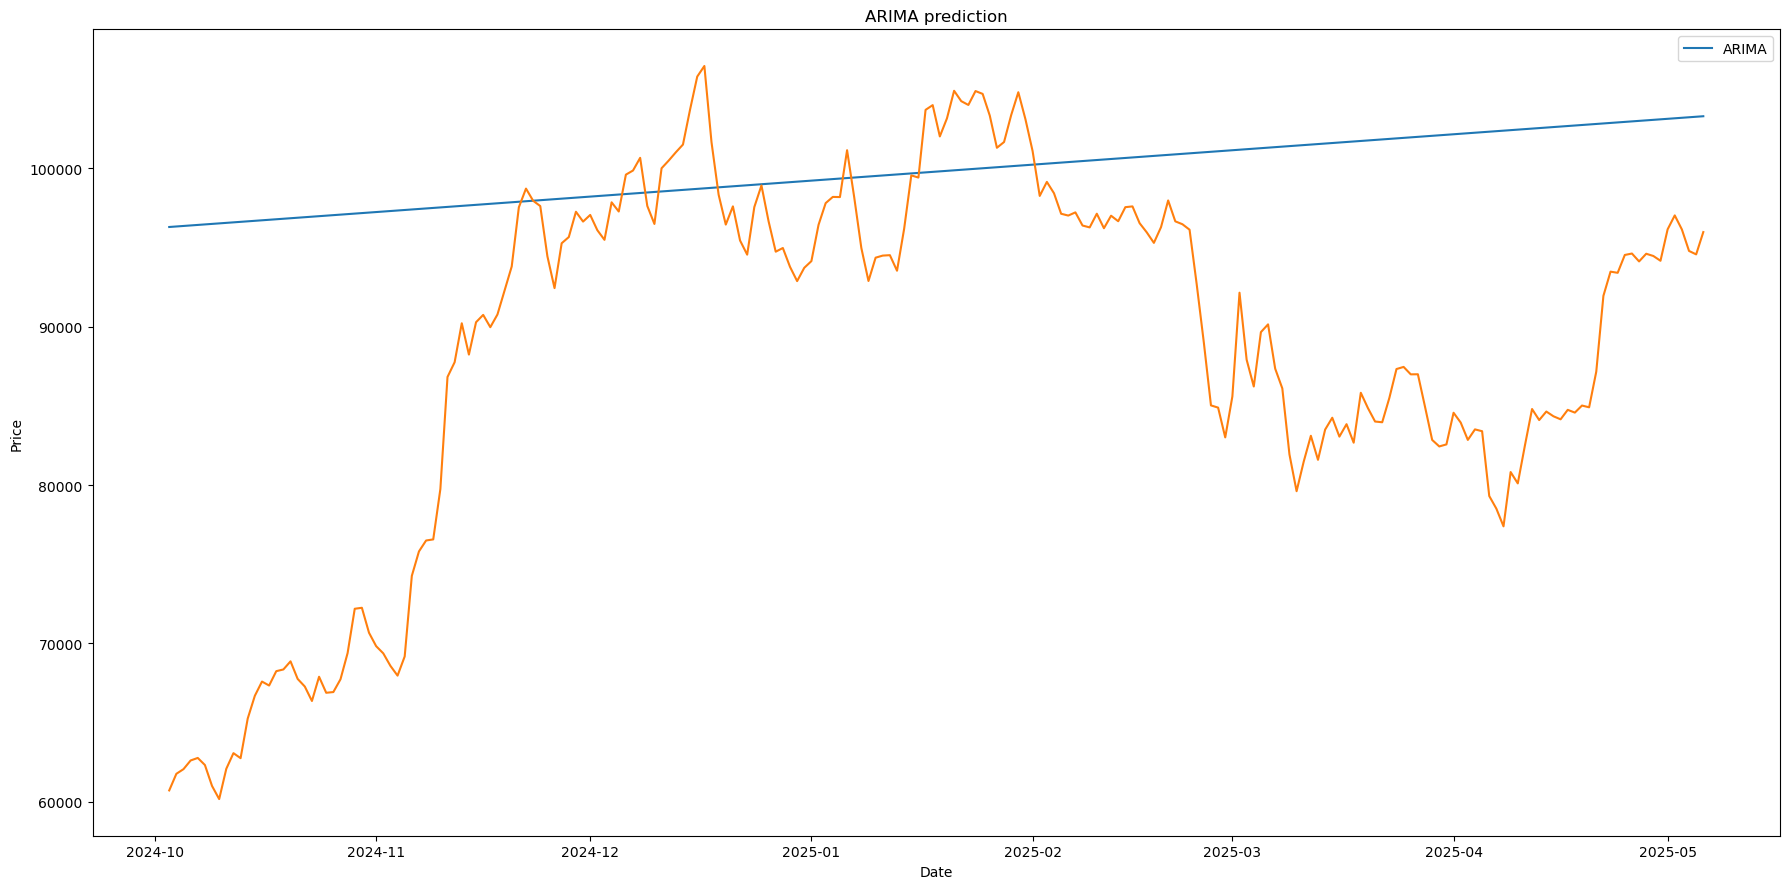

In [92]:
# auro_arima = pm.auto_arima(y=df.BTC, X=df.drop(columns=['BTC'])).fit()

scaler = RobustScaler()
y_arima = scaler.fit_transform(df.BTC.to_numpy().reshape(-1, 1)).flatten()

model = auto_arima(
    y_arima,
    seasonal=False,           # True, если данные сезонные
    stepwise=True,            # Быстрый жадный перебор
    trace=True,               # Показывает процесс подбора параметров
    error_action='ignore',    # Игнорировать ошибки
    suppress_warnings=True,   # Убираем предупреждения
    max_order=20              # Максимальная сумма p + q + P + Q
)

# Печать итоговой модели
print(model.summary())

# Прогноз (например, на 30 шагов вперёд)
n_periods = 216
forecast = model.predict(n_periods=n_periods)

forecast = pd.Series(data=scaler.inverse_transform(forecast.reshape(-1, 1)).flatten(), index=df.iloc[-216:].index)
# Визуализация
plt.plot(forecast, label='ARIMA')
plt.plot(df.BTC.iloc[-n_periods:])
plt.legend()
plt.title('ARIMA prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show();

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-995.274, Time=0.21 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-932.967, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-977.245, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-993.706, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-931.843, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-989.911, Time=0.20 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-992.237, Time=0.12 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-1001.477, Time=0.23 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-997.868, Time=0.22 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=-999.360, Time=0.30 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=-999.466, Time=0.28 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=-997.062, Time=0.25 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=-1000.139, Time=0.23 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=-998.209, Time=0.33 sec
 ARIMA(3,1,2)(0,0,0)[0]        

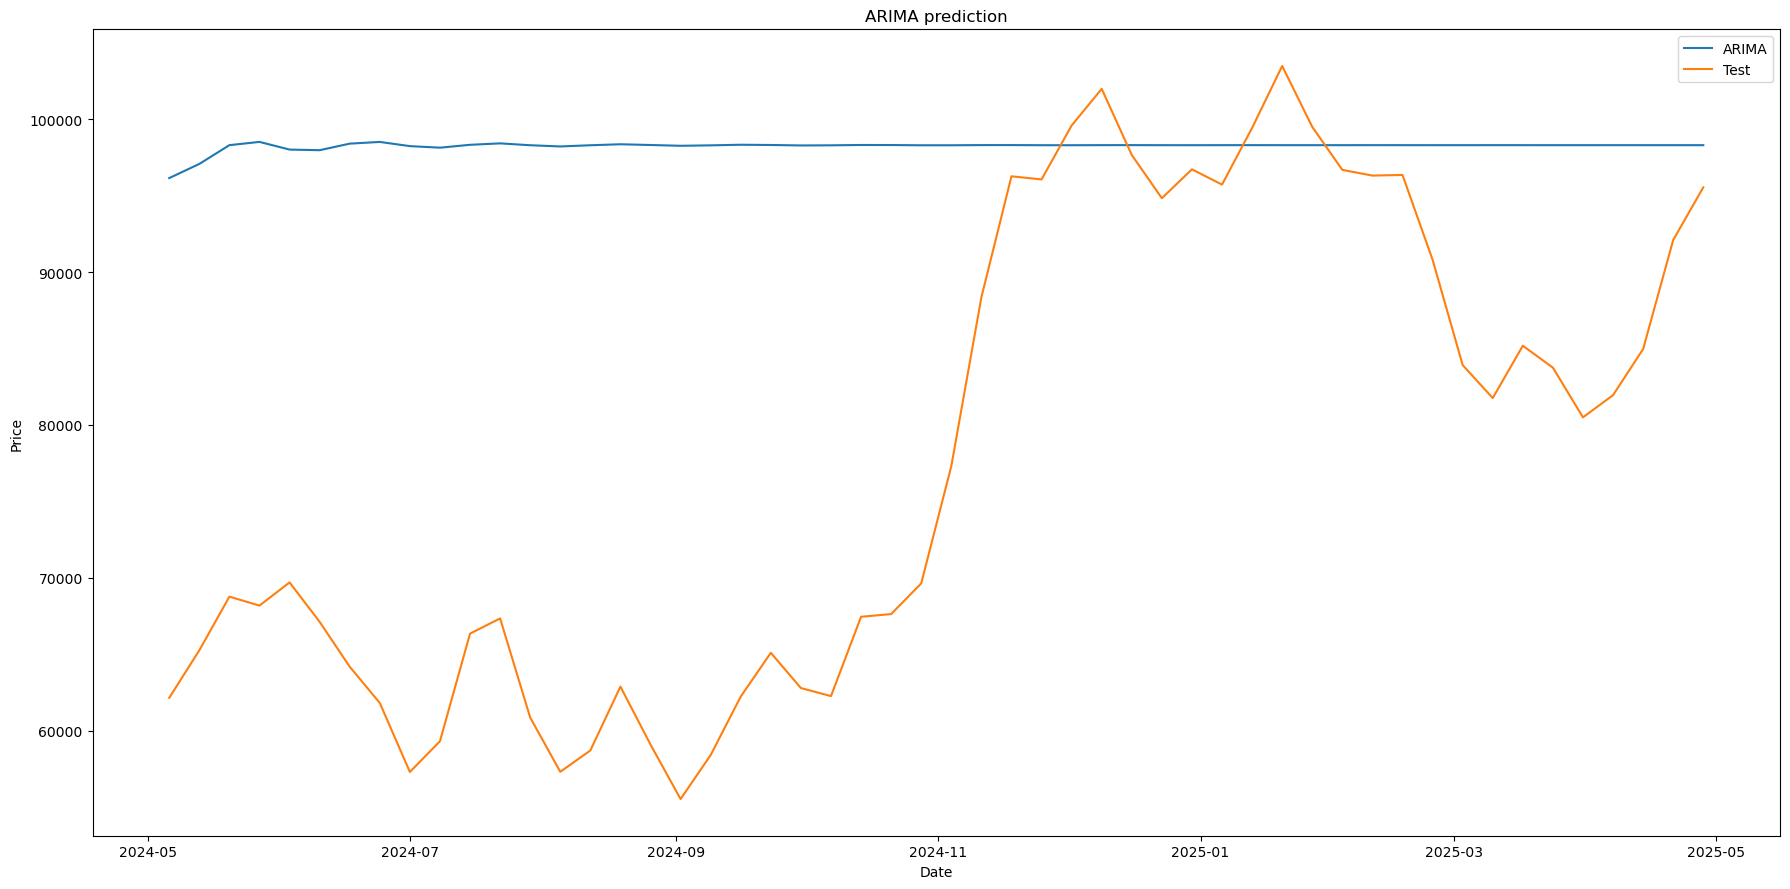

In [98]:
# auro_arima = pm.auto_arima(y=df.BTC, X=df.drop(columns=['BTC'])).fit()

scaler = RobustScaler()
y_arima = scaler.fit_transform(week.BTC.to_numpy().reshape(-1, 1)).flatten()

model = auto_arima(
    y_arima,
    seasonal=False,           # True, если данные сезонные
    stepwise=True,            # Быстрый жадный перебор
    trace=True,               # Показывает процесс подбора параметров
    error_action='ignore',    # Игнорировать ошибки
    suppress_warnings=True,   # Убираем предупреждения
    max_order=20              # Максимальная сумма p + q + P + Q
)

# Печать итоговой модели
print(model.summary())

# Прогноз (например, на 30 шагов вперёд)
n_periods = 52
forecast = model.predict(n_periods=n_periods)

forecast = pd.Series(data=scaler.inverse_transform(forecast.reshape(-1, 1)).flatten(), index=week.iloc[-n_periods:].index)
# Визуализация
plt.plot(forecast, label='ARIMA')
plt.plot(week.BTC.iloc[-n_periods:], label='Test')
plt.legend()
plt.title('ARIMA prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show();

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-120414.833, Time=1.31 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-119294.158, Time=0.90 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-120339.389, Time=1.32 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-120419.045, Time=0.63 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-119292.843, Time=0.51 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-120416.948, Time=4.04 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-120417.066, Time=2.71 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-120415.505, Time=2.02 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-120418.830, Time=0.87 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 14.312 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                17354
Model:               SARIMAX(0, 1, 1)   Log Likelihood               60212.523
Date:                

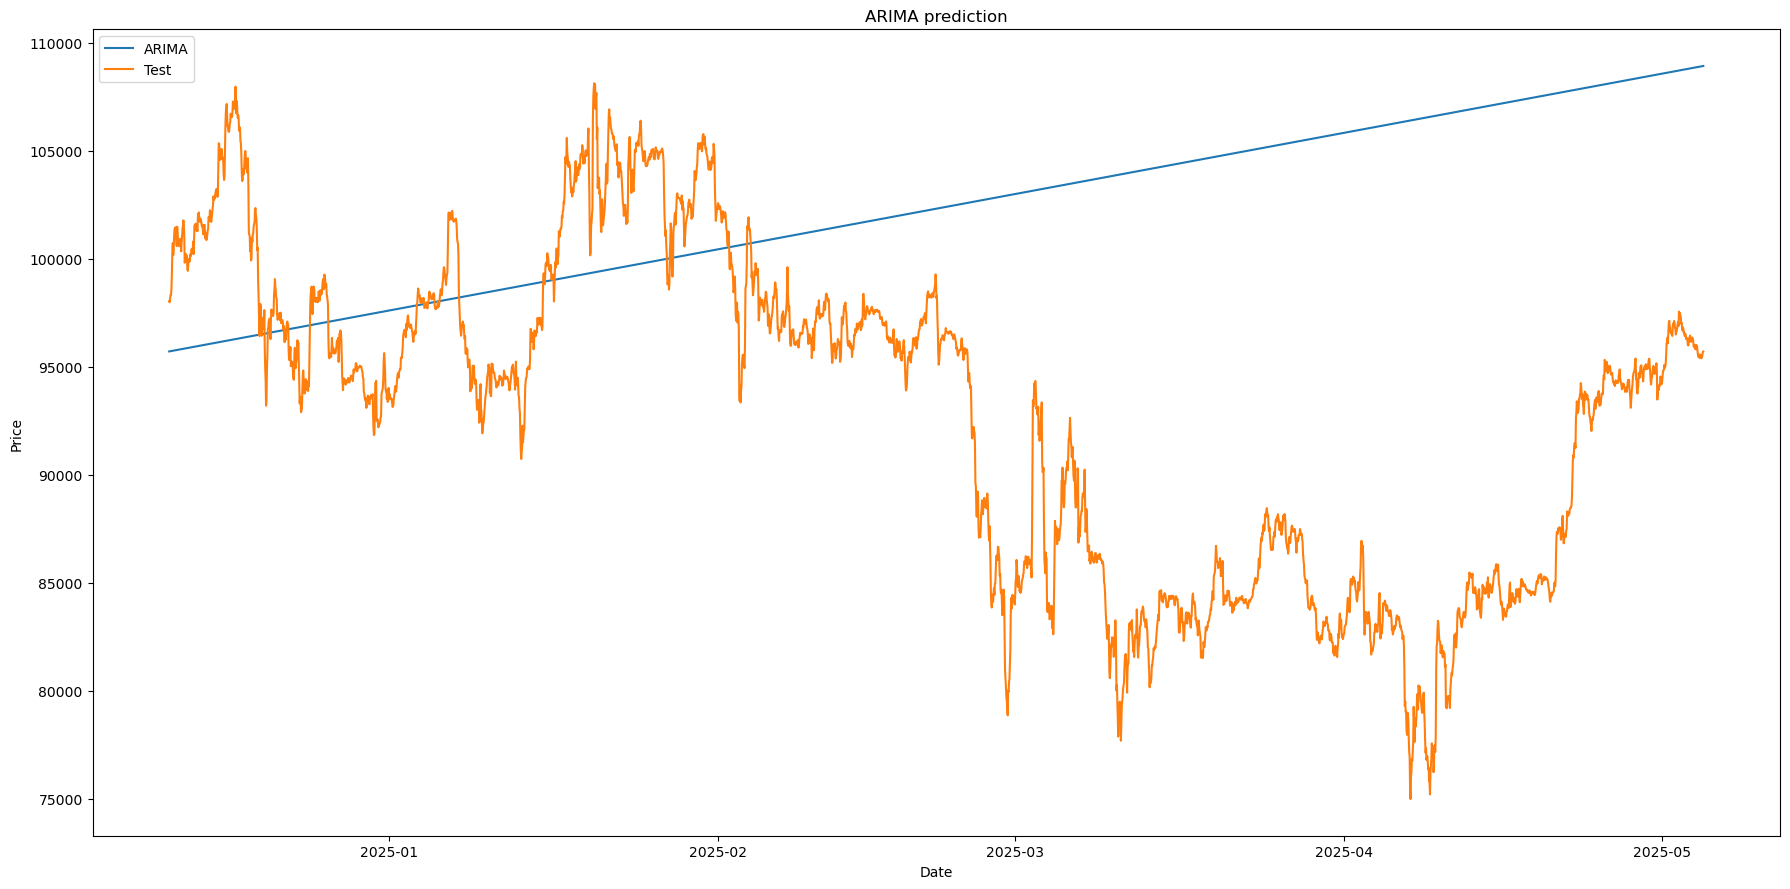

In [97]:
# auro_arima = pm.auto_arima(y=df.BTC, X=df.drop(columns=['BTC'])).fit()

scaler = RobustScaler()
y_arima = scaler.fit_transform(hour.BTC.to_numpy().reshape(-1, 1)).flatten()

model = auto_arima(
    y_arima,
    seasonal=False,           # True, если данные сезонные
    stepwise=True,            # Быстрый жадный перебор
    trace=True,               # Показывает процесс подбора параметров
    error_action='ignore',    # Игнорировать ошибки
    suppress_warnings=True,   # Убираем предупреждения
    max_order=20              # Максимальная сумма p + q + P + Q
)

# Печать итоговой модели
print(model.summary())

# Прогноз (например, на 30 шагов вперёд)
n_periods = int(hour.shape[0]*0.2)
forecast = model.predict(n_periods=n_periods)

forecast = pd.Series(data=scaler.inverse_transform(forecast.reshape(-1, 1)).flatten(), index=hour.iloc[-n_periods:].index)
# Визуализация
plt.plot(forecast, label='ARIMA')
plt.plot(hour.BTC.iloc[-n_periods:], label='Test')
plt.legend()
plt.title('ARIMA prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show();

In [14]:
neuro_day = NeuralForecaster()
neuro_day.fit(target_col='BTC', df=df)

Trial 90 Complete [00h 00m 28s]
val_loss: 0.03229976445436478

Best val_loss So Far: 0.020673571154475212
Total elapsed time: 00h 30m 33s
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [16]:
neuro_day_res = neuro_day.predict()

lstm_day_metrics, lstm_day = neuro_day_res['LSTM'].metrics, neuro_day_res['LSTM'].y_pred
mlp_day_metrics, mlp_day = neuro_day_res['MLP'].metrics, neuro_day_res['MLP'].y_pred
stacked_lstm_day_metrics, stacked_lstm_day = neuro_day_res['StackedLSTM'].metrics, neuro_day_res['StackedLSTM'].y_pred
cnn_lstm_day_metrics, cnn_lstm_day = neuro_day_res['CNN_LSTM'].metrics, neuro_day_res['CNN_LSTM'].y_pred
gru_day_metrics, gru_day = neuro_day_res['GRU'].metrics, neuro_day_res['GRU'].y_pred

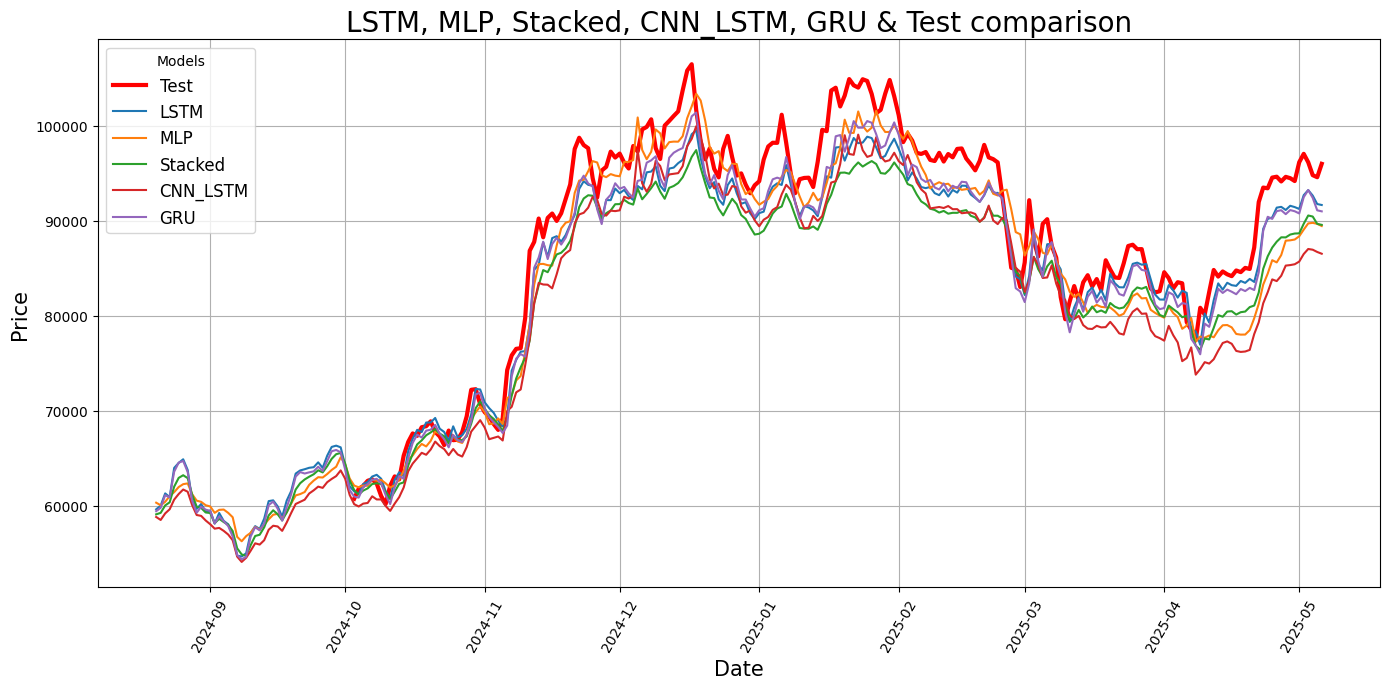

In [39]:
def make_plot(results: dict = neuro_day_res, figsize: tuple=(14, 7), y: pd.Series=y_day, test_size: int=216):
    """
    
    """
    plt.figure(figsize=figsize)

    plt.plot(y.iloc[-test_size:], label='Test', c='red', linewidth=3)

    for model in results:
        plt.plot(results[model], label=model)

    plt.title(f"{', '.join([model for model in results])} & Test comparison", fontsize=20)
    plt.ylabel('Price', fontsize=15)
    plt.xlabel('Date',  fontsize=15)

    plt.xticks(rotation=60)

    plt.legend(title='Models', fontsize=12)
    plt.grid(True)

make_plot(results={
    'LSTM':    neuro_day_res['LSTM'].y_pred,
    'MLP':     neuro_day_res['MLP'].y_pred,
    'Stacked': neuro_day_res['StackedLSTM'].y_pred,
    'CNN_LSTM':neuro_day_res['CNN_LSTM'].y_pred,
    'GRU':     neuro_day_res['GRU'].y_pred
}, y=y_day)

In [48]:
neuro_day_metrics = pd.DataFrame({
    
    'LSTM': lstm_day_metrics['test'] ,

    'MLP': mlp_day_metrics['test'] ,

    'Stacked LSTM': stacked_lstm_day_metrics['test'] ,

    'CNN-LSTM': cnn_lstm_day_metrics['test'] ,

    'GRU': gru_day_metrics['test'] ,

})

neuro_day_metrics.index = map(lambda x: x.upper(), lstm_day_metrics['test'].keys())
neuro_day_metrics.loc['SMAPE'] = neuro_day_metrics.loc['SMAPE'].apply(lambda smape: str(round(smape * 100, 4)) + '%')

neuro_day_metrics

,LSTM,MLP,Stacked LSTM,CNN-LSTM,GRU
MAE,2586.39,2926.66,3918.04,4455.90,2448.98
RMSE,3284.31,3643.65,4749.46,5275.46,3069.19
SMAPE,2.928%,3.4489%,4.4611%,5.262%,2.8072%
MASE,0.00,0.00,0.00,0.00,0.00


### нейронные сети, часовые данные

In [23]:
features_hourly = [
    # Таргет
    "BTC",
    # Кросс-крипто
    "ETH",
    "XRP",
    # Лаги и скользящие характеристики BTC
    "BTC_lag1",
    "BTC_lag2",
    "BTC_lag5",
    "BTC_mean5",
    "BTC_std10",
    # Технические индикаторы
    "RSI",
    "MACD",
    "ATR",
    "OBV",
    "SMA_50",
    "EMA_100",
    "TEMA_20",
    "KAMA_20",
    "HMA_10",
    "SSF_20_2",
    "ZL_EMA_20",
    "VIDYA_20",
    # Объёмы и флоу
    "Volume",
    "Taker buy base volume",
    "Taker buy quote volume",
    # Временные признаки
    "hour",      # часовой сегмент (0–23)
    "day",       # день недели или месяца
]
df_hour = hour[features_hourly]

In [58]:
neuro_hour = NeuralForecaster(test_size=int(df_hour.shape[0]*0.2))
neuro_hour.fit(target_col='BTC', df=df_hour)

Trial 90 Complete [00h 01m 01s]
val_loss: 0.055238597095012665

Best val_loss So Far: 0.008374816738069057
Total elapsed time: 01h 35m 31s
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [61]:
# df_hour.BTC.plot()

X_hour, y_hour = df_hour.drop(columns=['BTC']), df_hour['BTC']

neuro_hour_res = neuro_hour.predict()

lstm_hour_metrics, lstm_hour = neuro_hour_res['LSTM'].metrics, neuro_hour_res['LSTM'].y_pred
mlp_hour_metrics, mlp_hour = neuro_hour_res['MLP'].metrics, neuro_hour_res['MLP'].y_pred
stacked_lstm_hour_metrics, stacked_lstm_hour = neuro_hour_res['StackedLSTM'].metrics, neuro_hour_res['StackedLSTM'].y_pred
cnn_lstm_hour_metrics, cnn_lstm_hour = neuro_hour_res['CNN_LSTM'].metrics, neuro_hour_res['CNN_LSTM'].y_pred
gru_hour_metrics, gru_hour = neuro_hour_res['GRU'].metrics, neuro_hour_res['GRU'].y_pred

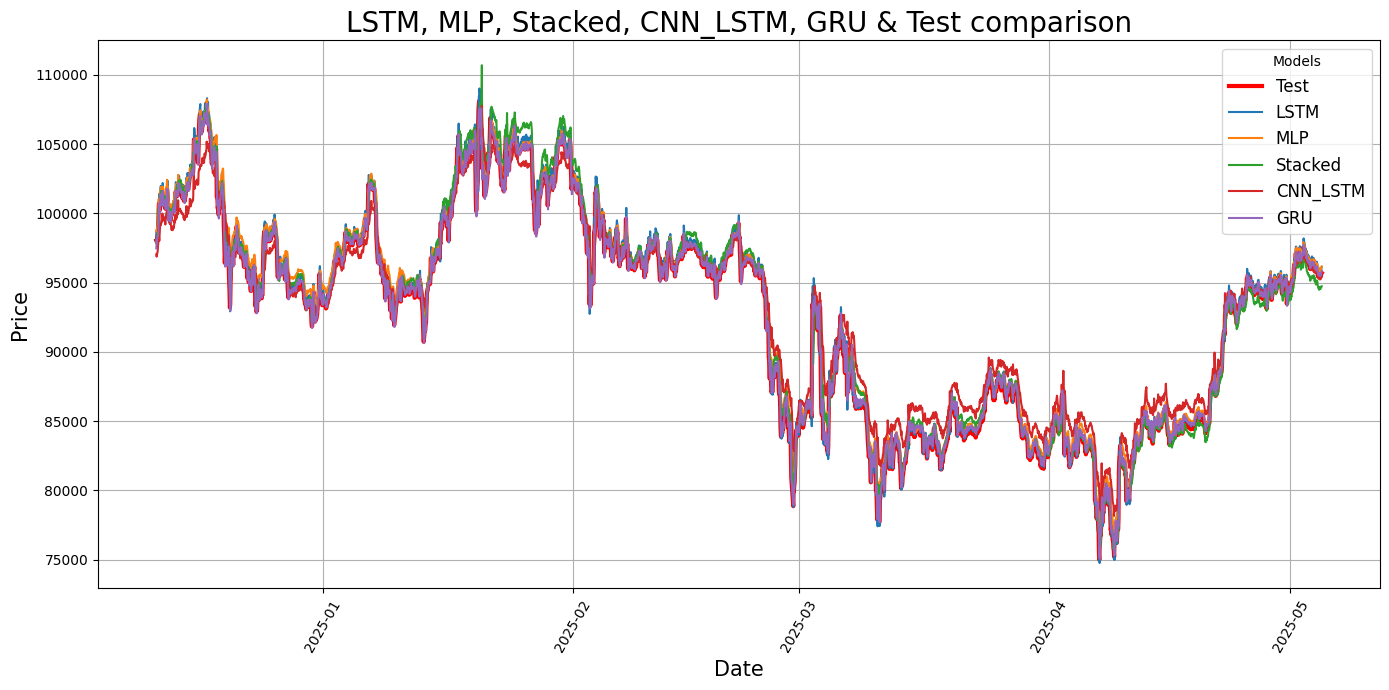

In [65]:
make_plot(results={
    'LSTM':    neuro_hour_res['LSTM'].y_pred,
    'MLP':     neuro_hour_res['MLP'].y_pred,
    'Stacked': neuro_hour_res['StackedLSTM'].y_pred,
    'CNN_LSTM':neuro_hour_res['CNN_LSTM'].y_pred,
    'GRU':     neuro_hour_res['GRU'].y_pred
},
    y=y_hour, test_size=int(df_hour.shape[0]*0.2)
)

In [66]:
neuro_hour_metrics = pd.DataFrame({
    
    'LSTM': lstm_hour_metrics['test'] ,

    'MLP': mlp_hour_metrics['test'] ,

    'Stacked LSTM': stacked_lstm_hour_metrics['test'] ,

    'CNN-LSTM': cnn_lstm_hour_metrics['test'] ,

    'GRU': gru_hour_metrics['test'] ,

})

neuro_hour_metrics.index = map(lambda x: x.upper(), lstm_day_metrics['test'].keys())
neuro_hour_metrics.loc['SMAPE'] = neuro_hour_metrics.loc['SMAPE'].apply(lambda smape: str(round(smape * 100, 4)) + '%')

neuro_hour_metrics

,LSTM,MLP,Stacked LSTM,CNN-LSTM,GRU
MAE,438.06,668.79,622.91,1148.05,302.27
RMSE,561.09,862.00,804.62,1487.41,436.70
SMAPE,0.4688%,0.7296%,0.6644%,1.2749%,0.3306%
MASE,0.00,0.00,0.00,0.00,0.00


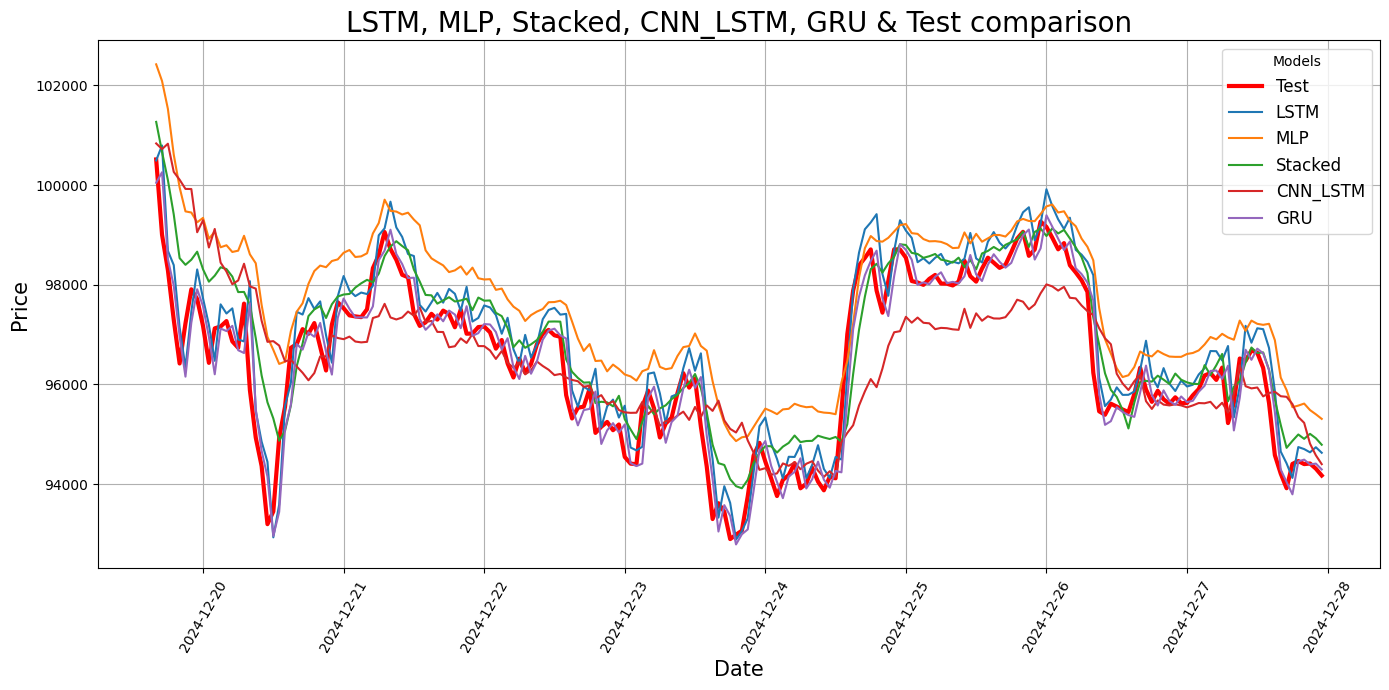

In [78]:
def make_plot_partial(
        results: dict = neuro_day_res, 
        figsize: tuple=(14, 7), 
        y: pd.Series=y_day, 
        start_idx: int=0, 
        end_idx: int=200
    ):
    """
    
    """
    if start_idx > end_idx:
        start_idx_old, end_idx_old = start_idx, end_idx
        start_idx, end_idx = end_idx_old, start_idx_old

    plt.figure(figsize=figsize)

    y_test = y.iloc[-int(df_hour.shape[0]*0.2):]

    plt.plot(y_test.iloc[start_idx:end_idx], label='Test', c='red', linewidth=3)

    for model in results:
        plt.plot(results[model].iloc[start_idx:end_idx], label=model)

    plt.title(f"{', '.join([model for model in results])} & Test comparison", fontsize=20)
    plt.ylabel('Price', fontsize=15)
    plt.xlabel('Date',  fontsize=15)

    plt.xticks(rotation=60)

    plt.legend(title='Models', fontsize=12)
    plt.grid(True)

make_plot_partial(
    results={
        'LSTM':    neuro_hour_res['LSTM'].y_pred,
        'MLP':     neuro_hour_res['MLP'].y_pred,
        'Stacked': neuro_hour_res['StackedLSTM'].y_pred,
        'CNN_LSTM':neuro_hour_res['CNN_LSTM'].y_pred,
        'GRU':     neuro_hour_res['GRU'].y_pred
    }, 
    y=y_hour, 
    start_idx=200, 
    end_idx=400
)

### нейронные сети, недельные данные

In [46]:
week = pd.read_csv('new_week_df.csv', parse_dates=['Date'], index_col=['Date'])
week.shape

(369, 86)

In [58]:
weekly_features = [
    "BTC",
    'SMA_10',
    'KAMA_10_2_30', 
    'ALMA_8_6.0_0.85',
    'MicroStrategy',
    "ETH",
    "Fed_Funds_Rate",
    "CPI", "Gold",
    'NASDAQ_100',
    'S&P_500',
    'M2_Money_Supply',
    "VIX",
    "Taker buy base volume", 
    "Taker buy quote volume"
]
df_week = week[weekly_features]

# X_week, y_week = df_week.drop(columns=['BTC']), df_week['BTC']

neuro_week = NeuralForecaster(test_size=52)
neuro_week.fit(target_col='BTC', df=df_week)

Trial 90 Complete [00h 00m 22s]
val_loss: 0.11783451586961746

Best val_loss So Far: 0.06157808005809784
Total elapsed time: 00h 26m 13s
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


In [60]:
X_week, y_week = df_week.drop(columns=['BTC']), df_week['BTC']

neuro_week_res = neuro_hour.predict()

lstm_week_metrics, lstm_week = neuro_week_res['LSTM'].metrics, neuro_week_res['LSTM'].y_pred
mlp_week_metrics, mlp_week = neuro_week_res['MLP'].metrics, neuro_week_res['MLP'].y_pred
stacked_lstm_week_metrics, stacked_lstm_week = neuro_week_res['StackedLSTM'].metrics, neuro_week_res['StackedLSTM'].y_pred
cnn_lstm_week_metrics, cnn_lstm_week = neuro_week_res['CNN_LSTM'].metrics, neuro_week_res['CNN_LSTM'].y_pred
gru_week_metrics, gru_week = neuro_week_res['GRU'].metrics, neuro_week_res['GRU'].y_pred

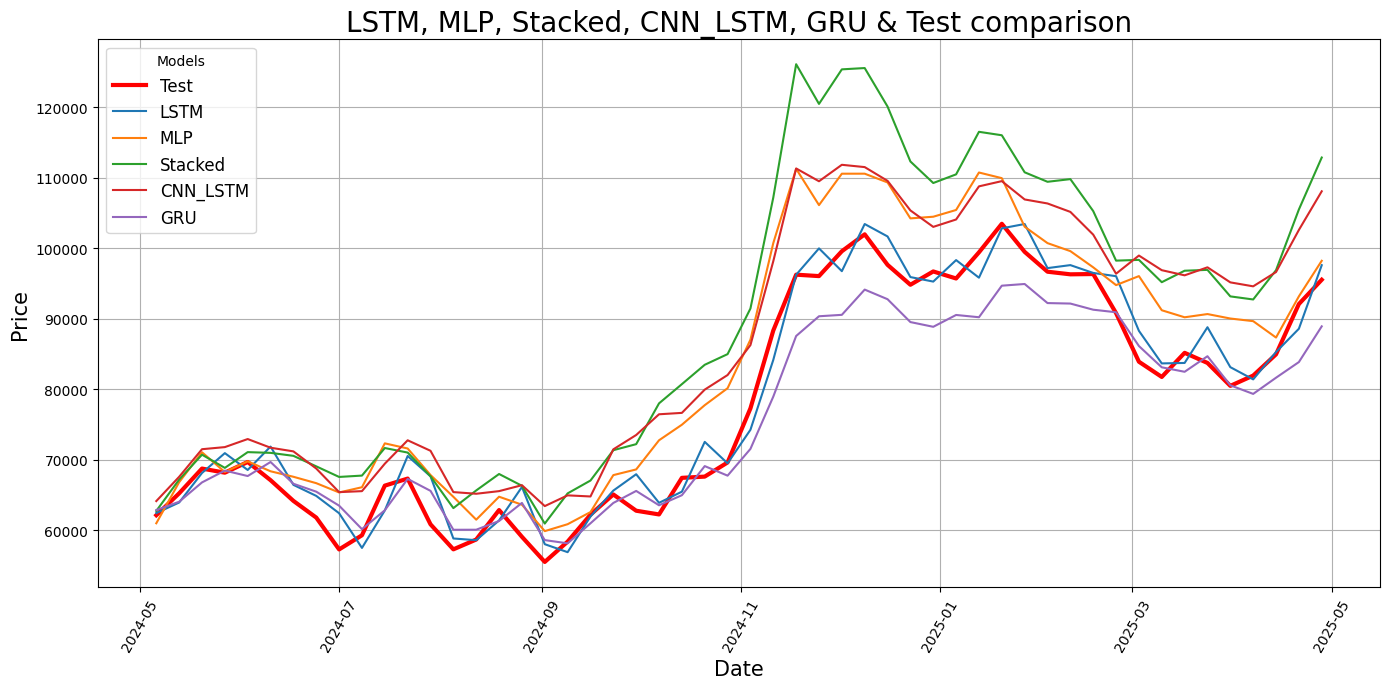

In [72]:
def make_plot(results: dict, figsize: tuple=(14, 7), y: pd.Series=y_day, test_size: int=216):
    """
    
    """
    plt.figure(figsize=figsize)

    plt.plot(y.iloc[-test_size:], label='Test', c='red', linewidth=3)

    for model in results:
        plt.plot(results[model], label=model)

    plt.title(f"{', '.join([model for model in results])} & Test comparison", fontsize=20)
    plt.ylabel('Price', fontsize=15)
    plt.xlabel('Date',  fontsize=15)

    plt.xticks(rotation=60)

    plt.legend(title='Models', fontsize=12)
    plt.grid(True)

make_plot(results={
    'LSTM':    neuro_week_res['LSTM'].y_pred,
    'MLP':     neuro_week_res['MLP'].y_pred,
    'Stacked': neuro_week_res['StackedLSTM'].y_pred,
    'CNN_LSTM':neuro_week_res['CNN_LSTM'].y_pred,
    'GRU':     neuro_week_res['GRU'].y_pred
}, y=y_week, test_size=52)

In [75]:
neuro_week_metrics = pd.DataFrame({
    
    'LSTM': lstm_week_metrics['test'] ,

    'MLP': mlp_week_metrics['test'] ,

    'Stacked LSTM': stacked_lstm_week_metrics['test'] ,

    'CNN-LSTM': cnn_lstm_week_metrics['test'] ,

    'GRU': gru_week_metrics['test'] ,

})

neuro_week_metrics.index = map(lambda x: x.upper(), lstm_week_metrics['test'].keys())
neuro_week_metrics.loc['SMAPE'] = neuro_week_metrics.loc['SMAPE'].apply(lambda smape: str(round(smape * 100, 4)) + '%')

neuro_week_metrics

,LSTM,MLP,Stacked LSTM,CNN-LSTM,GRU
MAE,2450.96,6042.86,11219.14,8625.53,3661.87
RMSE,3036.88,7138.24,13005.16,9392.26,4558.54
SMAPE,3.2632%,7.3685%,12.7706%,10.4645%,4.5493%
MASE,0.00,0.00,0.00,0.00,0.00


### линейные модели, дневные данные

In [36]:
ridge_day = LinearForecaster(
    test_size=216,
    model_type='Ridge'
)
ridge_day.fit(X_day, y_day)


lasso_day = LinearForecaster(
    test_size=216,
    model_type='Lasso'
)
lasso_day.fit(X_day, y_day)


elastic_day = LinearForecaster(
    test_size=216,
    model_type='ElasticNet'
)
elastic_day.fit(X_day, y_day)


[2025-05-11 06:02:39] Ridge начала обучаться


2025-05-11 06:02:41.245003: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746932561.262347 1685373 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746932561.267543 1685373 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-11 06:02:41.297099: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-11 06:02:44.680048: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: 


[2025-05-11 06:02:51] Ridge закончила обучаться

[2025-05-11 06:02:51] Lasso начала обучаться

[2025-05-11 06:02:53] Lasso закончила обучаться

[2025-05-11 06:02:53] ElasticNet начала обучаться

[2025-05-11 06:03:53] ElasticNet закончила обучаться


LinearForecaster(model_type='ElasticNet', test_size=216)

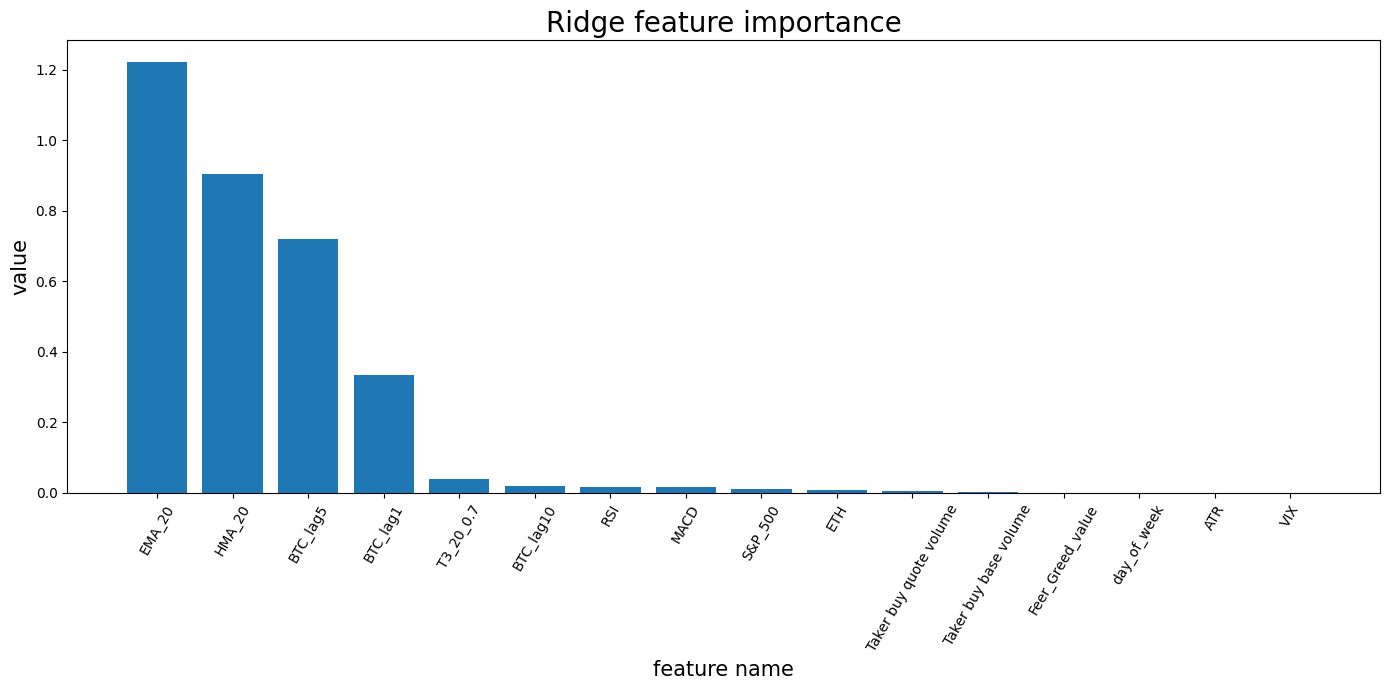

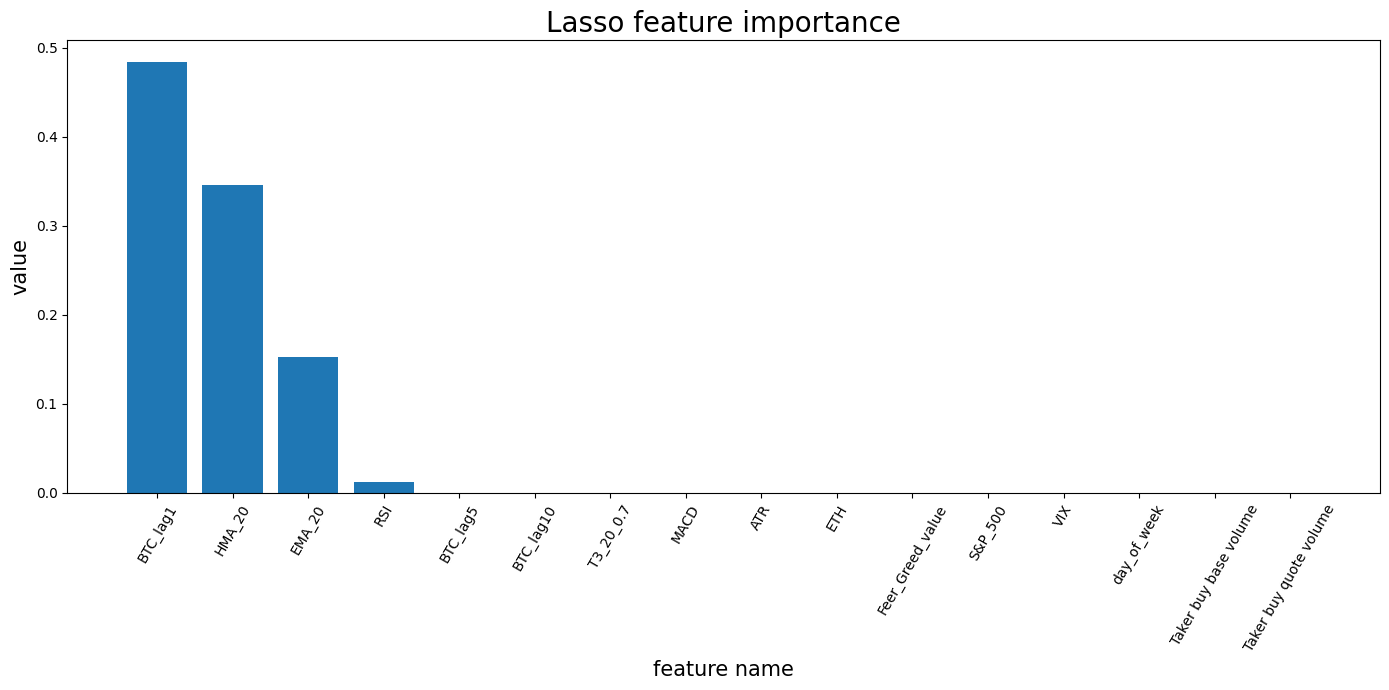

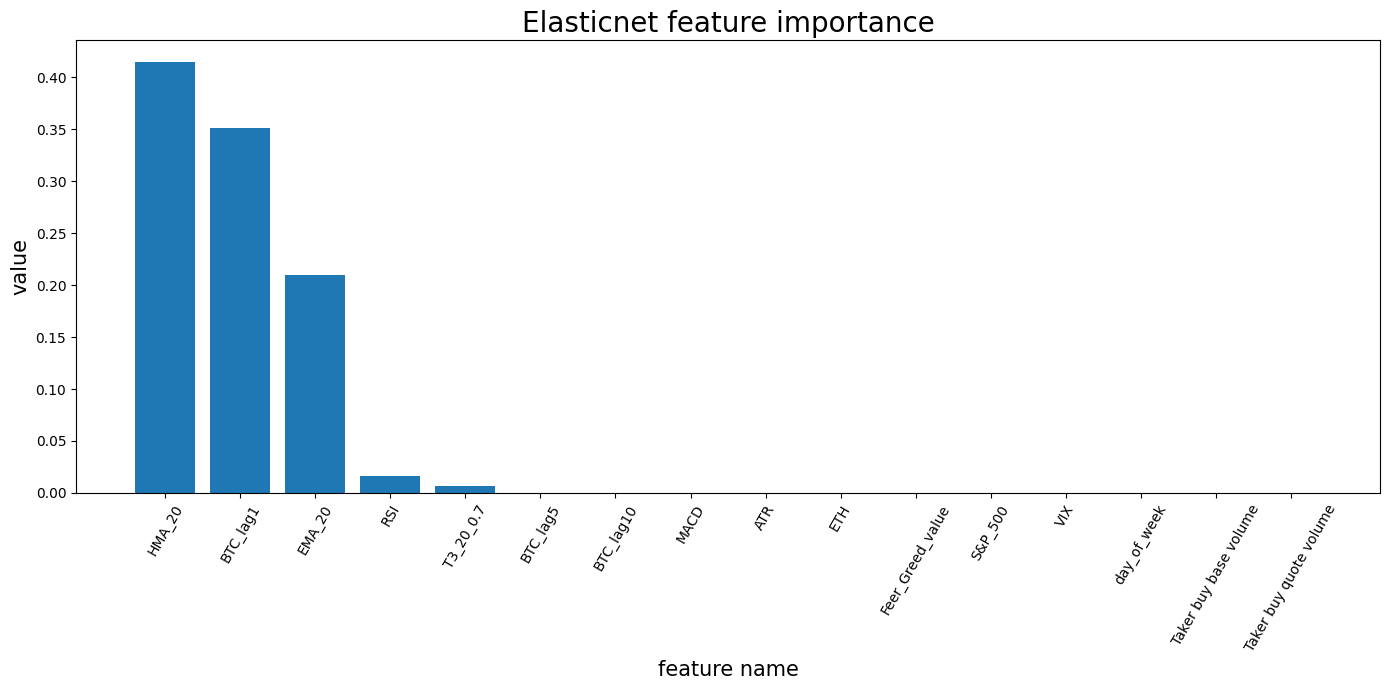

In [37]:
def get_feature_importance(model, X: pd.DataFrame, top_n: int=None, make_plot: bool=True):
    """
    
    """
    feature_names = X.columns.tolist()

    lin_feature_importance = pd.DataFrame({
                                    'feature_names': feature_names,
                                    'feature_importance': np.abs(model.model_.best_estimator_.regressor_.named_steps['reg'].coef_)
                                }).sort_values(
                                    by='feature_importance', 
                                    ascending=False, 
                                    ignore_index=True
                                )
    
    if top_n is not None:
        lin_feature_importance = lin_feature_importance.head(top_n)
    
    if make_plot:

        plt.figure(figsize=(14, 7))
        plt.bar(
            x=lin_feature_importance['feature_names'], 
            height=lin_feature_importance['feature_importance']
        )

        plt.title(f'{model.model_type.capitalize()} feature importance', fontsize=20)
        plt.ylabel('value', fontsize=15)
        plt.xlabel('feature name', fontsize=15)

        plt.xticks(rotation=60)
        
        plt.show();

    return lin_feature_importance

ridge_feature_importance = get_feature_importance(model=ridge_day, X=X_day)
lasso_feature_importance = get_feature_importance(model=lasso_day, X=X_day)
elastic_feature_importance = get_feature_importance(model=elastic_day, X=X_day)

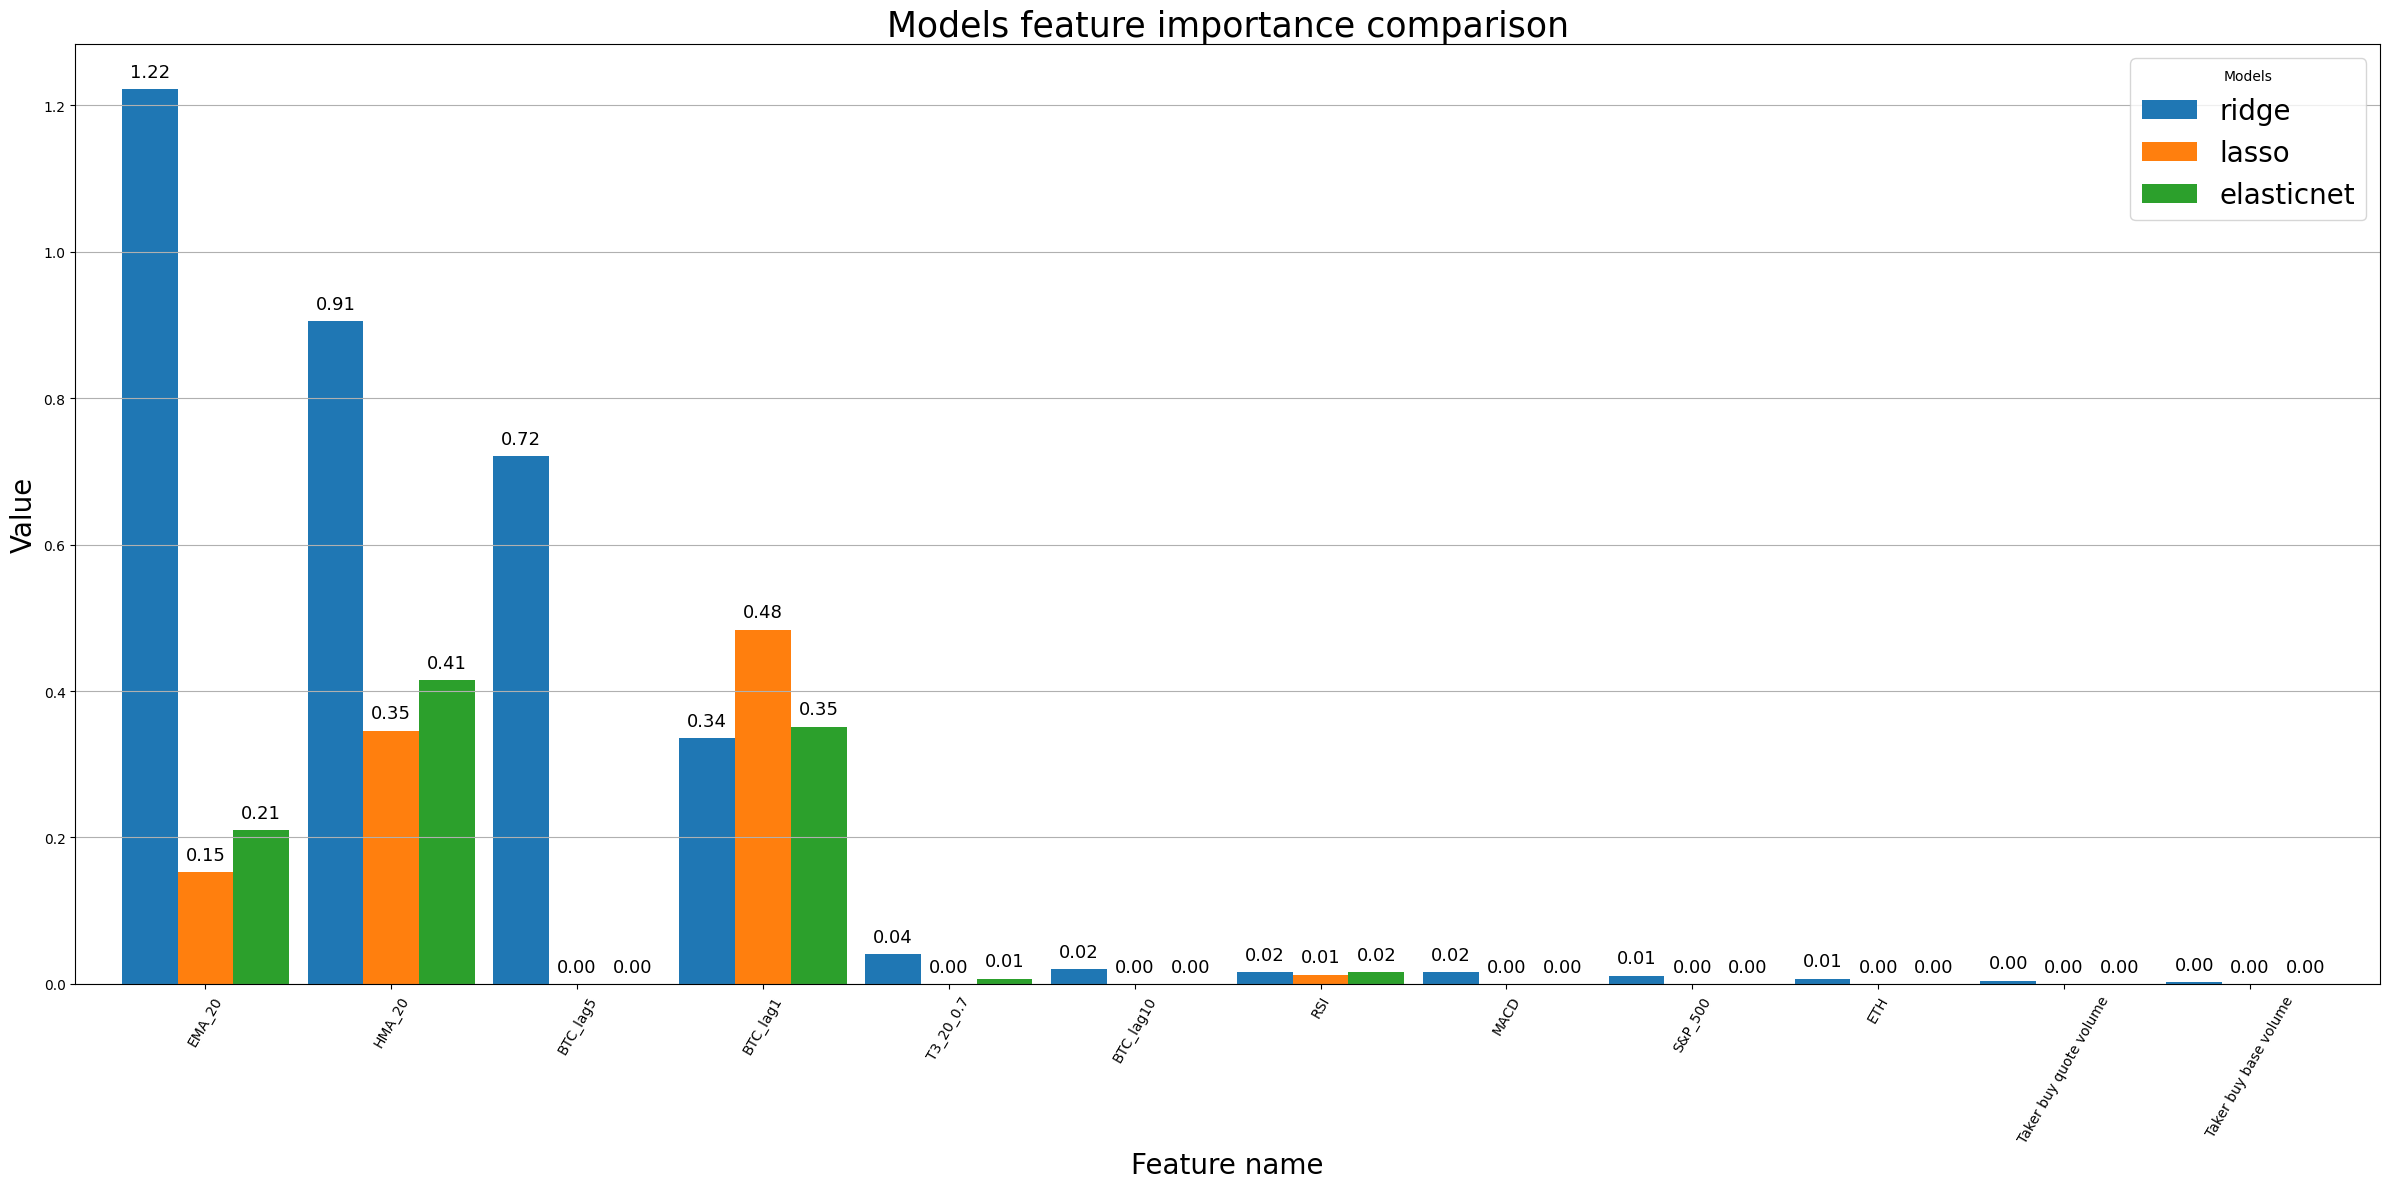

In [38]:
ridge_feature_importance_copy = ridge_feature_importance\
                                    .merge(lasso_feature_importance, on='feature_names')\
                                    .merge(elastic_feature_importance, on='feature_names')\
                                    .rename(columns={
                                                'feature_importance_x': 'ridge', 
                                                'feature_importance_y': 'lasso',
                                                'feature_importance': 'elasticnet'
                                            })

fig, ax = plt.subplots(figsize=(24, 12))   # увеличили фигуру
# ridge_feature_importance_copy[:, :10].plot(
ridge_feature_importance_copy.sort_values(by='ridge', ascending=False).head(12).plot(
    kind='bar',
    x='feature_names',
    ax=ax,
    width=.9    # уменьшили ширину столбцов → появилось больше пространства
)

# 3. Оформление
ax.set_title('Models feature importance comparison', fontsize=25)
ax.set_ylabel('Value', fontsize=20)
ax.set_xlabel('Feature name', fontsize=20)
plt.xticks(rotation=60)
plt.legend(title='Models', fontsize=20)

# 4. Аннотируем каждую полосу
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{height:.2f}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 6),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=13
    )

plt.grid(True, which='major', axis='y')
plt.tight_layout()
plt.show()

как можно видеть на изображении, линейные модели придают таргетным фичам (тем, что были созданы на его основе) и практически абстрогируется от всех остальных показателей. при чуть больше регуляризации, как это в случае `Lasso` и `ElasticNet`, незануленными остались лишь три показателя, все из которых таргетные

In [50]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

def make_adf_test(data: pd.Series):
    
    result = adfuller(data)

    # Вывод результатов
    print("ADF Statistic: {:.4f}".format(result[0]))
    print("p-value: {:.4f}".format(result[1]))
    print("Used lags: {}".format(result[2]))
    print("Number of observations: {}".format(result[3]))
    print("Critical values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
    
        # Интерпретация
    if result[1] < 0.05:
        print("\nСтационарность подтверждена (отвергаем нулевую гипотезу).")
    else:
        print("\nНулевая гипотеза не отвергнута — ряд нестационарен.")

make_adf_test(day.BTC)

ADF Statistic: -0.1529
p-value: 0.9439
Used lags: 24
Number of observations: 2605
Critical values:
   1%: -3.4329
   5%: -2.8627
   10%: -2.5674

Нулевая гипотеза не отвергнута — ряд нестационарен.


In [51]:
make_adf_test(week.BTC)

ADF Statistic: -0.4939
p-value: 0.8932
Used lags: 4
Number of observations: 364
Critical values:
   1%: -3.4484
   5%: -2.8695
   10%: -2.5710

Нулевая гипотеза не отвергнута — ряд нестационарен.


In [52]:
make_adf_test(hour.BTC)

ADF Statistic: -0.6705
p-value: 0.8543
Used lags: 24
Number of observations: 17329
Critical values:
   1%: -3.4307
   5%: -2.8617
   10%: -2.5669

Нулевая гипотеза не отвергнута — ряд нестационарен.


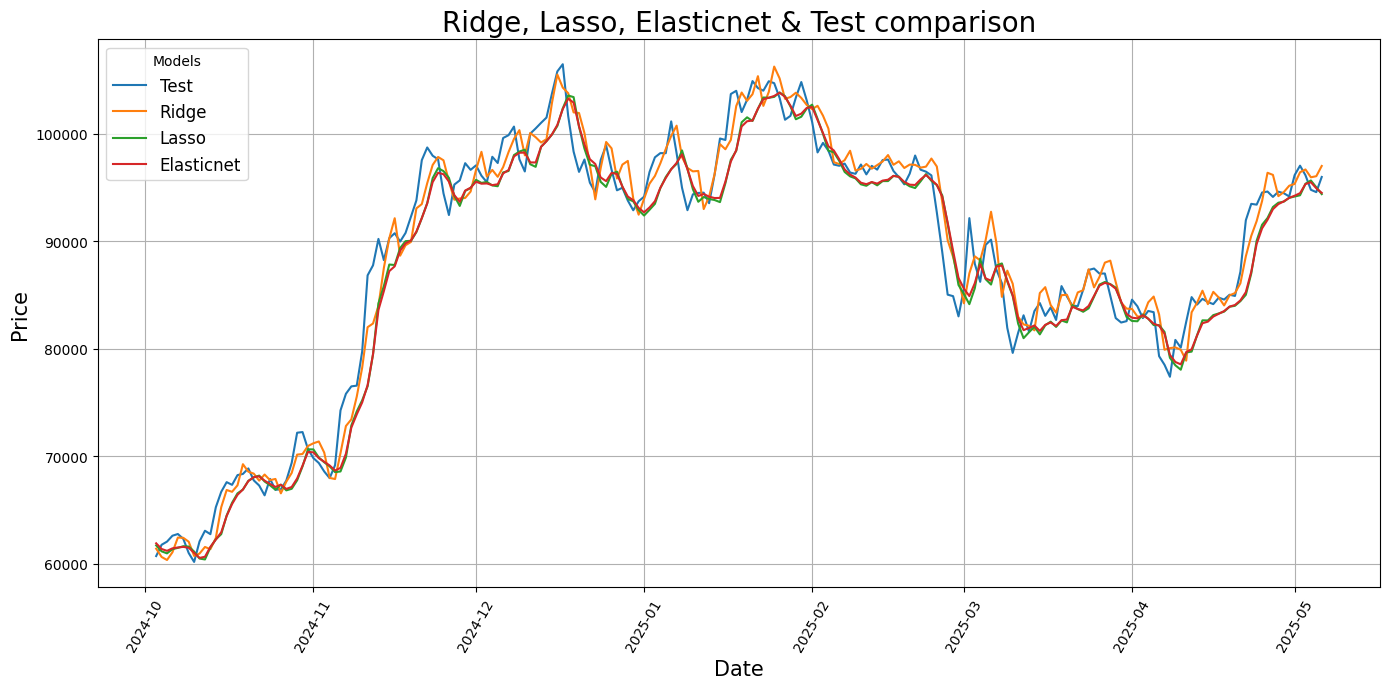

In [39]:
def make_plot(y, models, figsize: tuple=(14, 7)):
    """
    
    """
    if not isinstance(models, list): 
        models=[models]

    plt.figure(figsize=figsize)

    plt.plot(y.iloc[-models[0].test_size:], label='Test')

    for model in models:
        plt.plot(model.result_.y_pred, label=f'{model.model_type.capitalize()}')

    plt.title(f"{', '.join([model.model_type.capitalize() for model in models])} & Test comparison", fontsize=20)
    plt.ylabel('Price', fontsize=15)
    plt.xlabel('Date', fontsize=15)

    plt.xticks(rotation=60)

    plt.legend(title='Models', fontsize=12)
    plt.grid(True)

make_plot(y=y_day, models=[ridge_day, lasso_day, elastic_day])

недооцениваются просадки, преувеличивается рост - свойственно линейным моделям. `Lasso` и `ElasticNet` идентичны по причине выбора параметра `l1-ratio = 1` у второй. хоть на метриках результаты могут показаться довольно хорошими, но обратив внимание на график, можно понять, что предсказания будто всегда западнывают и будто повторяют одну из скользящих средних или лаговых метрик

In [40]:
lin_metrics = pd.DataFrame({
    'Ridge (Train)': ridge_day.result_.metrics['train'] ,
    'Ridge (Test)': ridge_day.result_.metrics['test'] ,

    'Lasso (Train)': lasso_day.result_.metrics['train'] ,
    'Lasso (Test)': lasso_day.result_.metrics['test'] ,

    'ElasticNet (Train)': elastic_day.result_.metrics['train'] ,
    'ElasticNet (Test)': elastic_day.result_.metrics['test'] ,
}, index=ridge_day.result_.metrics['train'].keys())

lin_metrics.index = map(lambda x: x.upper(), ridge_day.result_.metrics['train'].keys())
lin_metrics.loc['SMAPE'] = lin_metrics.loc['SMAPE'].apply(lambda smape: str(round(smape * 100, 4)) + '%')

lin_metrics

,Ridge (Train),Ridge (Test),Lasso (Train),Lasso (Test),ElasticNet (Train),ElasticNet (Test)
MAE,635.90,1526.51,798.68,2150.05,795.24,2112.81
RMSE,955.59,2004.07,1255.76,2758.38,1241.28,2710.46
SMAPE,3.1065%,1.7398%,3.5861%,2.4662%,3.6151%,2.4219%
MASE,1.27,3.04,1.59,4.28,1.58,4.21


## древовидные модели

In [13]:
log_transformer = FunctionTransformer(np.log1p, inverse_func=np.expm1)

def get_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    """
    Препроцессор для древовидных моделей

    * Заполнение пустых значений средним
    * Скалирование - `RobustScaler`
    """
    numeric_cols = X.select_dtypes(include='number').columns.tolist()
    prep = ColumnTransformer(
        [('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', RobustScaler())
        ]), numeric_cols)],
        remainder='drop'
    )

    return prep

def random_forest_cv(
        X: pd.DataFrame,
        y: pd.Series,
        cv_splits: int = 5,
        n_iter: int = 20,
        seed: int = 42,
        n_jobs: int = 1
) -> RandomizedSearchCV:
    """
    RandomForestRegressor с RandomizedSearchCV, TimeSeriesSplit и лог-преобразованием таргета"""
    preprocessor = get_preprocessor(X)
    base_pipe = Pipeline([
        ('prep', preprocessor),
        ('rf', RandomForestRegressor(random_state=seed))
    ])
    model = TransformedTargetRegressor(
        regressor=base_pipe,
        transformer=log_transformer
    )
    param_dist = {
        'regressor__rf__n_estimators': randint(100, 500),
        'regressor__rf__max_depth': randint(5, 50),
        'regressor__rf__min_samples_leaf': randint(1, 20),
        'regressor__rf__min_impurity_decrease': loguniform(1e-5, 1e-2),
        'regressor__rf__bootstrap': [True],
        'regressor__rf__max_samples': uniform(0.5, 0.5),
    }
    tscv = TimeSeriesSplit(n_splits=cv_splits)
    scorer = make_scorer(smape, greater_is_better=False)
    rs = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=tscv,
        scoring=scorer,
        random_state=seed,
        n_jobs=n_jobs
    )
    rs.fit(X, y)
    return rs


def lightgbm_cv(
    X: pd.DataFrame,
    y: pd.Series,
    cv_splits: int = 5,
    n_iter: int = 20,
    seed: int = 42,
    n_jobs: int = 1
) -> RandomizedSearchCV:
    """LGBMRegressor с RandomizedSearchCV, TimeSeriesSplit и лог-преобразованием таргета"""
    preprocessor = get_preprocessor(X)
    base_pipe = Pipeline([
        ('prep', preprocessor),
        ('lgbm', LGBMRegressor(random_state=seed, n_jobs=n_jobs))
    ])
    model = TransformedTargetRegressor(
        regressor=base_pipe,
        transformer=log_transformer
    )
    param_dist = {
        'regressor__lgbm__learning_rate': uniform(0.01, 0.29),
        'regressor__lgbm__num_leaves': randint(20, 150),
        'regressor__lgbm__min_child_samples': randint(5, 100),
        'regressor__lgbm__subsample': uniform(0.5, 0.5),
        'regressor__lgbm__colsample_bytree': uniform(0.5, 0.5),
        'regressor__lgbm__reg_alpha': loguniform(1e-3, 10),
        'regressor__lgbm__reg_lambda': loguniform(1e-3, 10),
        'regressor__lgbm__n_estimators': randint(100, 1000),
    }
    tscv = TimeSeriesSplit(n_splits=cv_splits)
    scorer = make_scorer(smape, greater_is_better=False)
    rs = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=tscv,
        scoring=scorer,
        random_state=seed,
        n_jobs=n_jobs
    )
    rs.fit(X, y)
    return rs


def knn_cv(
    X: pd.DataFrame,
    y: pd.Series,
    cv_splits: int = 5,
    n_iter: int = 20,
    seed: int = 42,
    n_jobs: int = 1
) -> RandomizedSearchCV:
    """KNeighborsRegressor с RandomizedSearchCV, TimeSeriesSplit и лог-преобразованием таргета"""
    preprocessor = get_preprocessor(X)
    base_pipe = Pipeline([
        ('prep', preprocessor),
        ('knn', KNeighborsRegressor())
    ])
    model = TransformedTargetRegressor(
        regressor=base_pipe,
        transformer=log_transformer
    )
    param_dist = {
        'regressor__knn__n_neighbors': randint(3, 31),
        'regressor__knn__weights': ['uniform', 'distance'],
        'regressor__knn__p': [1, 2],
    }
    tscv = TimeSeriesSplit(n_splits=cv_splits)
    scorer = make_scorer(smape, greater_is_better=False)
    rs = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=tscv,
        scoring=scorer,
        random_state=seed,
        n_jobs=n_jobs
    )
    rs.fit(X, y)
    return rs


In [76]:
# week.to_csv('new_week_df.csv')
# hour.to_csv('new_hour_df.csv')
# day.to_csv('new_day_df.csv')

In [24]:
# дневные
X_day_train, X_day_test, y_day_train, y_day_test = train_test_split(
    X_day, y_day, shuffle=False, test_size=216
)

# часовые
X_hour, y_hour = df_hour.drop(columns=['BTC']), df_hour['BTC']

X_hour_train, X_hour_test, y_hour_train, y_hour_test = train_test_split(
    X_hour, y_hour, shuffle=False, test_size=int(X_hour.shape[0]*0.2)
)

In [15]:
rf_day = random_forest_cv(
    X_day_train, y_day_train, n_iter=100, n_jobs=-1
)

2025-05-11 05:41:00.105501: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746931260.144616 1684367 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746931260.156342 1684367 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-11 05:41:00.170622: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-11 05:41:00.194114: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AV

In [16]:
lgbm_day = lightgbm_cv(
    X_day_train, y_day_train, n_iter=100, n_jobs=-1
)

In [17]:
knn_day = knn_cv(
    X_day_train, y_day_train, n_iter=100, n_jobs=-1
)

In [20]:
rf_pred_day     = pd.Series(index=y_day.iloc[-216:].index, data=rf_day.predict(X_day_test))
lgbm_pred_day   = pd.Series(index=y_day.iloc[-216:].index, data=lgbm_day.predict(X_day_test))
knn_pred_day    = pd.Series(index=y_day.iloc[-216:].index, data=knn_day.predict(X_day_test))

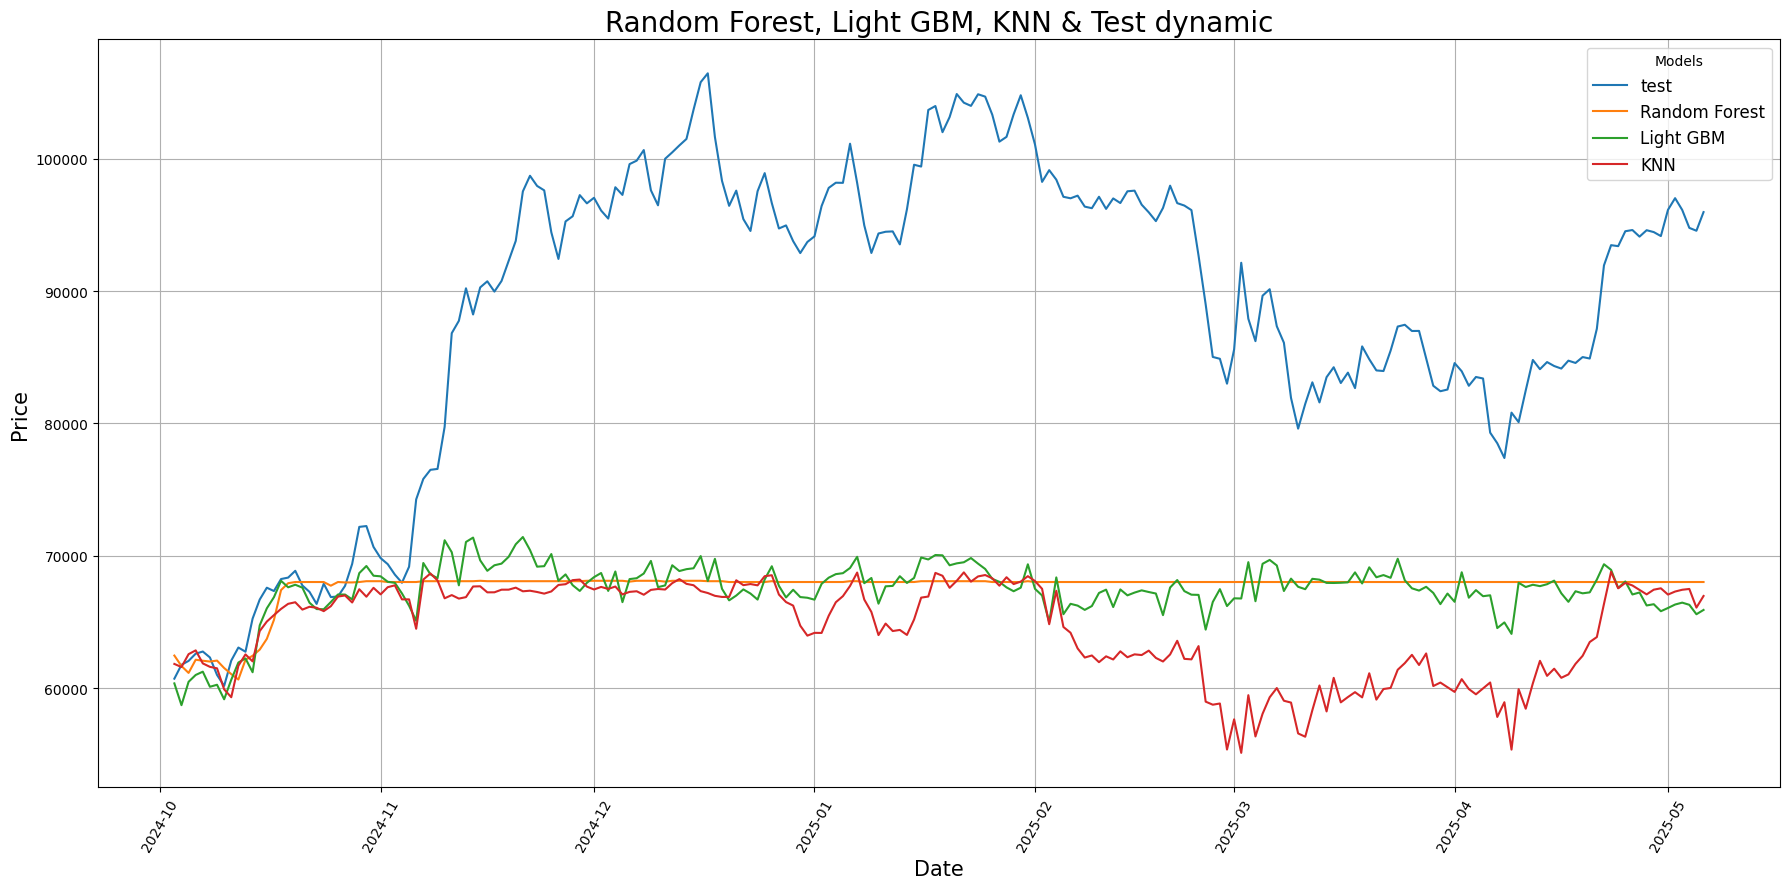

In [41]:
plt.plot(y_day.iloc[-216:], label='test')
plt.plot(rf_pred_day, label='Random Forest')
plt.plot(lgbm_pred_day, label='Light GBM')
plt.plot(knn_pred_day, label='KNN')

plt.title(f'Random Forest, Light GBM, KNN & Test dynamic', fontsize=20)
plt.ylabel('Price', fontsize=15)
plt.xlabel('Date', fontsize=15)

plt.xticks(rotation=60)

plt.legend(title='Models', fontsize=12)
plt.grid(True)

In [25]:
rf_hour = random_forest_cv(
    X_hour_train, y_hour_train, n_iter=30, n_jobs=-1
)
lgbm_hour = lightgbm_cv(
    X_hour_train, y_hour_train, n_iter=30, n_jobs=-1
)
knn_hour = knn_cv(
    X_hour_train, y_hour_train, n_iter=30, n_jobs=-1
)

2025-05-11 05:48:51.912876: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746931731.939939 1684906 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746931731.948046 1684906 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-11 05:48:51.977847: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-11 05:48:54.722194: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: 

In [31]:
rf_pred_hour    = pd.Series(index=y_hour_test.index, data=rf_hour.predict(X_hour_test))
lgbm_pred_hour  = pd.Series(index=y_hour_test.index, data=lgbm_hour.predict(X_hour_test))
knn_pred_hour   = pd.Series(index=y_hour_test.index, data=knn_hour.predict(X_hour_test))

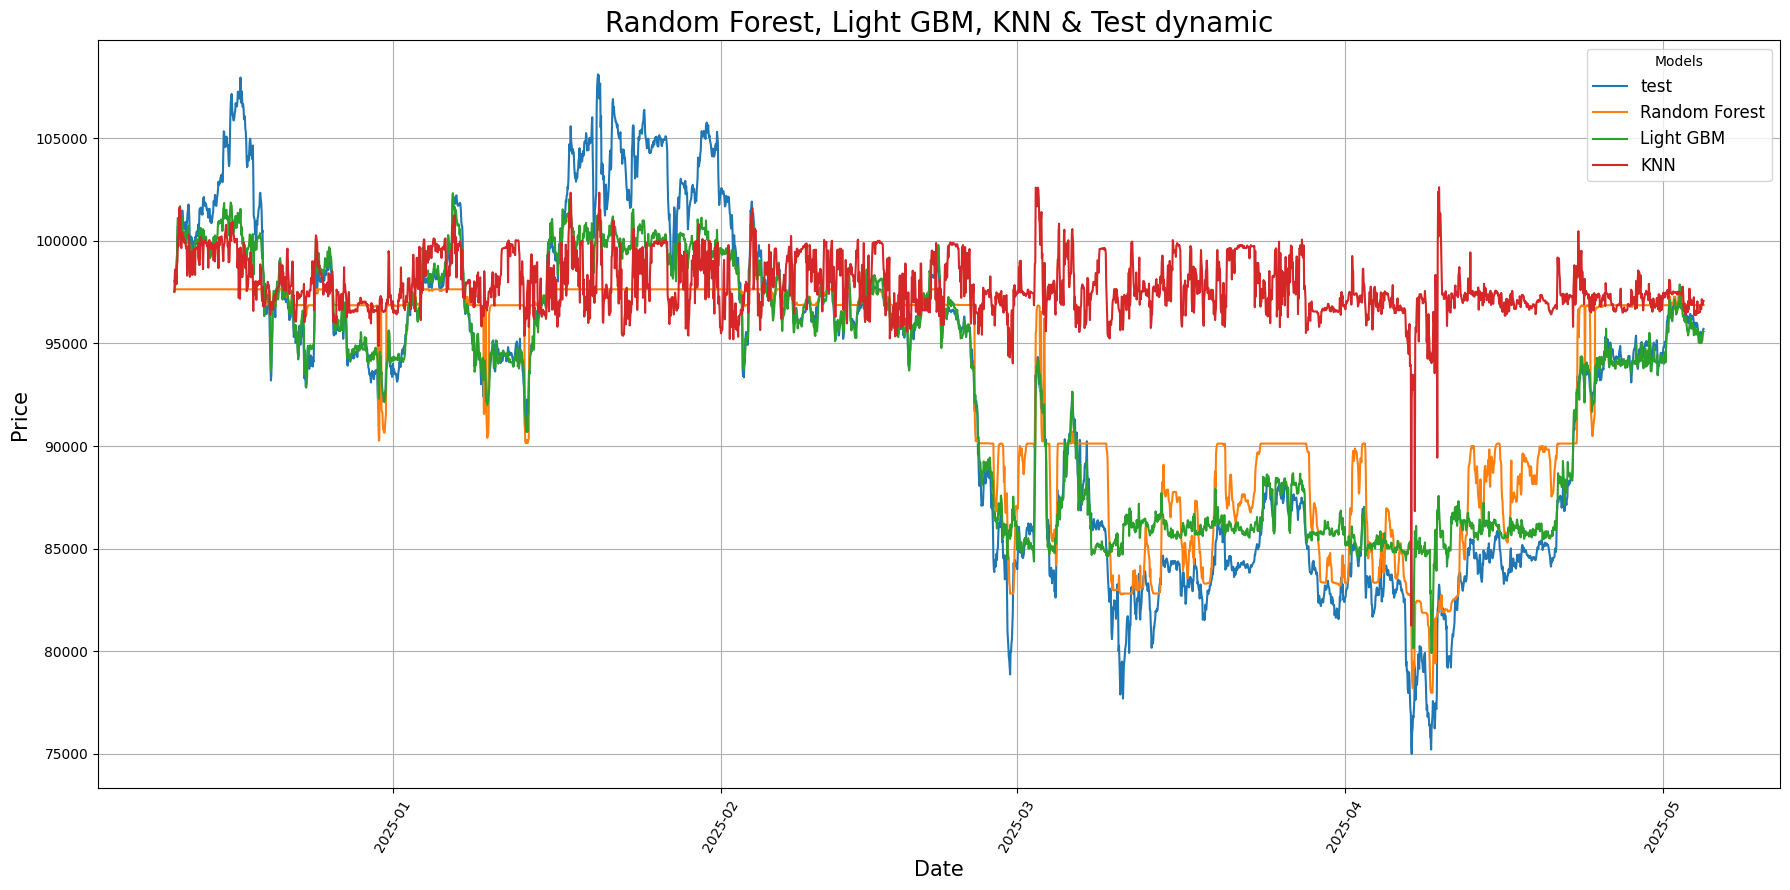

In [35]:
plt.plot(y_hour_test, label='test')
plt.plot(rf_pred_hour, label='Random Forest')
plt.plot(lgbm_pred_hour, label='Light GBM')
plt.plot(knn_pred_hour, label='KNN')

plt.title(f'Random Forest, Light GBM, KNN & Test dynamic', fontsize=20)
plt.ylabel('Price', fontsize=15)
plt.xlabel('Date', fontsize=15)

plt.xticks(rotation=60)

plt.legend(title='Models', fontsize=12)
plt.grid(True);

### 

In [42]:
xgb_day = StackingForecaster(
    test_size=216,
    model_type='XGBoost',
)
xgb_day.fit(X_day, y_day)


[2025-05-11 06:20:01] XGBoost начала обучаться


2025-05-11 06:20:03.797931: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746933603.814593 1685707 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746933603.819717 1685707 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-11 06:20:03.837066: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-11 06:20:03.913799: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: 


[2025-05-11 06:21:21] XGBoost закончила обучаться


StackingForecaster(model_type='XGBoost', test_size=216)

In [43]:
lgbm_day = StackingForecaster(
    test_size=216,
    model_type='LightGBM'
)
lgbm_day.fit(X_day, y_day)


[2025-05-11 06:21:21] LightGBM начала обучаться


2025-05-11 06:21:24.379452: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746933684.397183 1723534 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746933684.402665 1723534 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-11 06:21:24.402681: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746933684.420780 1723535 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-11 06:21:24.420877: I tensorflow/core/platfo


[2025-05-11 06:22:25] LightGBM закончила обучаться


StackingForecaster(model_type='LightGBM', test_size=216)

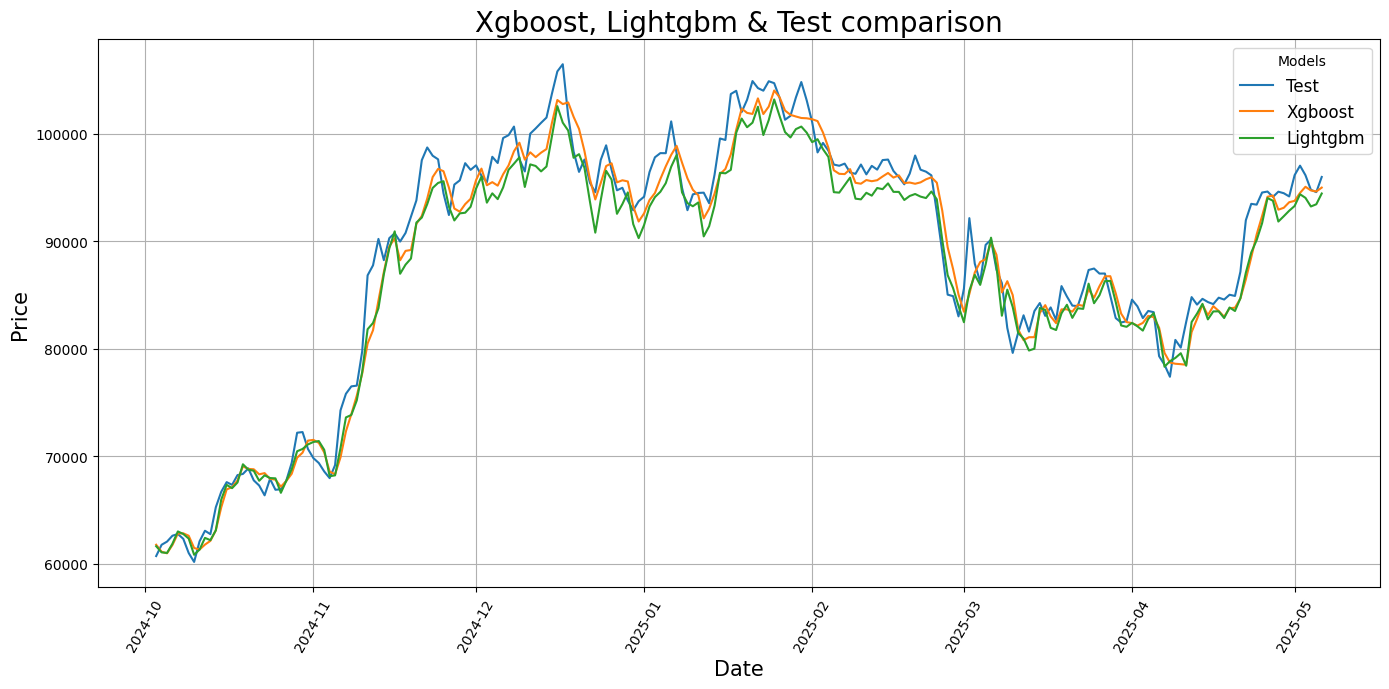

In [44]:
make_plot(y=y_day, models=[xgb_day, lgbm_day])

In [45]:
def stack_feature_importance(models):
    """
    Combine feature importance from multiple StackingForecaster models,
    showing ALL coefficients from the final Ridge estimator.
    
    Args:
        models: List of StackingForecaster instances
        
    Returns:
        Dictionary containing:
        - 'final_model': DataFrame with ALL Ridge coefficients
        - 'base_models': List of DataFrames with base model importances
    """
    final_dfs, base_dfs = [], []
    
    for model in models:

        feature_names = model.X_train.columns.tolist()
        stack = model.model_.best_estimator_.regressor_.named_steps['stack']

        final_coefs = stack.final_estimator_.coef_
        
        coef_names = [f"{model.model_type}_pred", "KNN_pred"] + feature_names
        
        fin_df = pd.DataFrame({
            'feature': coef_names,
            'coefficient': final_coefs,
            'model_type': model.model_type
        })
        final_dfs.append(fin_df)
        
        base_imp = stack.estimators_[0].feature_importances_
        base_df = pd.DataFrame({
            'feature': feature_names,
            model.model_type: base_imp
        })
        base_dfs.append(base_df)
    

    final_result = pd.concat(final_dfs).reset_index(drop=True)
    
    base_result = base_dfs[0]
    for df in base_dfs[1:]:
        base_result = base_result.merge(df, on='feature', how='outer')
    
    return {
        'final_model': final_result,
        'base_models': base_result
    }

In [46]:
final_model_fi = stack_feature_importance([xgb_day, lgbm_day])['final_model']\
                    .groupby(['model_type', 'feature'])\
                    .coefficient.last().reset_index()

lgbm_fi, xgb_fi = (
    final_model_fi[final_model_fi.model_type == 'LightGBM'].iloc[:, 1:],
    final_model_fi[final_model_fi.model_type == 'XGBoost'].iloc[:, 1:],
)

In [47]:
base_models_fi = stack_feature_importance([xgb_day, lgbm_day])['base_models']

In [48]:
stack_res = pd.DataFrame(
    data={
        'XGBoost (Train)':          xgb_day.result_.metrics['train'],
        'XGBoost (Test)':           xgb_day.result_.metrics['test'],
 
        'LightGBM (Train)':         lgbm_day.result_.metrics['train'],
        'LightGBM (Test)':          lgbm_day.result_.metrics['test'],
    },
)

stack_res.index = map(lambda x: x.upper(), ridge_day.result_.metrics['train'].keys())
stack_res.loc['SMAPE'] = stack_res.loc['SMAPE'].apply(lambda smape: str(round(smape * 100, 4)) + '%')

stack_res

,XGBoost (Train),XGBoost (Test),LightGBM (Train),LightGBM (Test)
MAE,636.25,1709.84,553.59,2007.51
RMSE,956.43,2177.24,832.11,2458.50
SMAPE,3.2444%,1.9389%,2.7238%,2.2345%
MASE,1.27,3.40,1.10,4.00


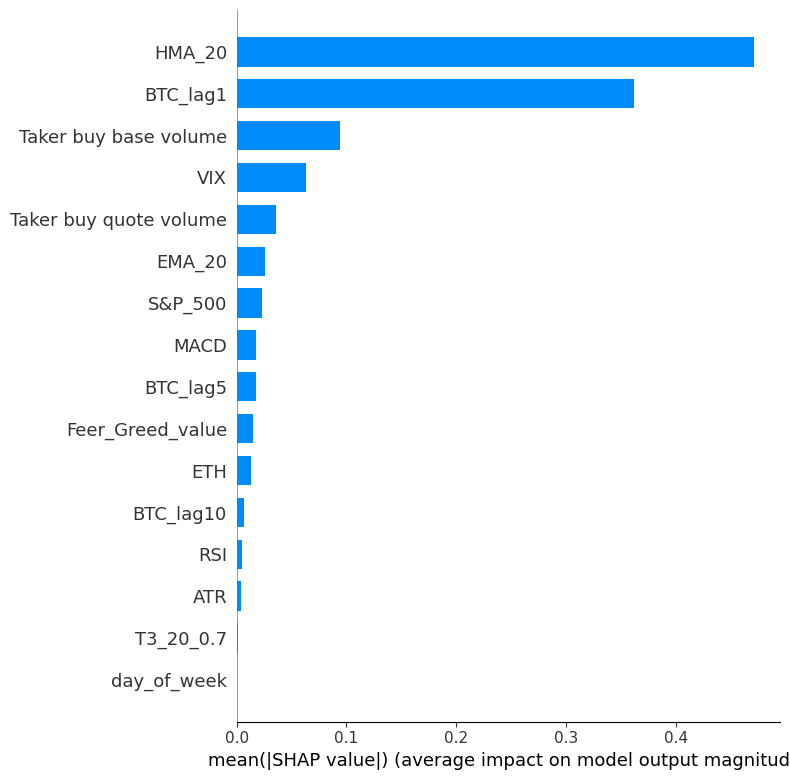

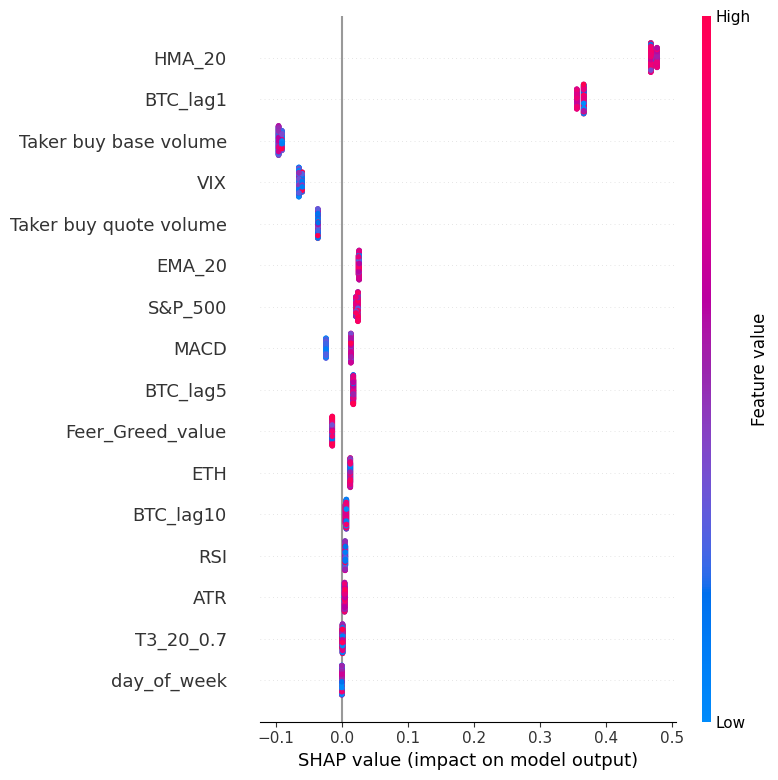

In [49]:
model = xgb_day.model_.best_estimator_.regressor_.named_steps['stack'].estimators_[0]
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(xgb_day.X_test)

shap.summary_plot(shap_values, xgb_day.X_test, plot_type='bar');
shap.summary_plot(shap_values, xgb_day.X_test);

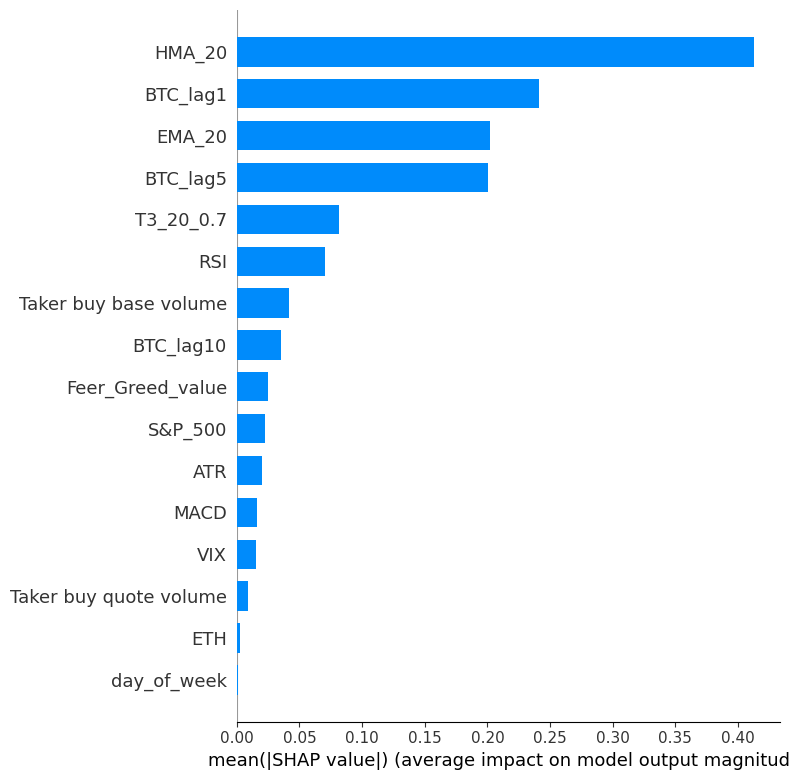

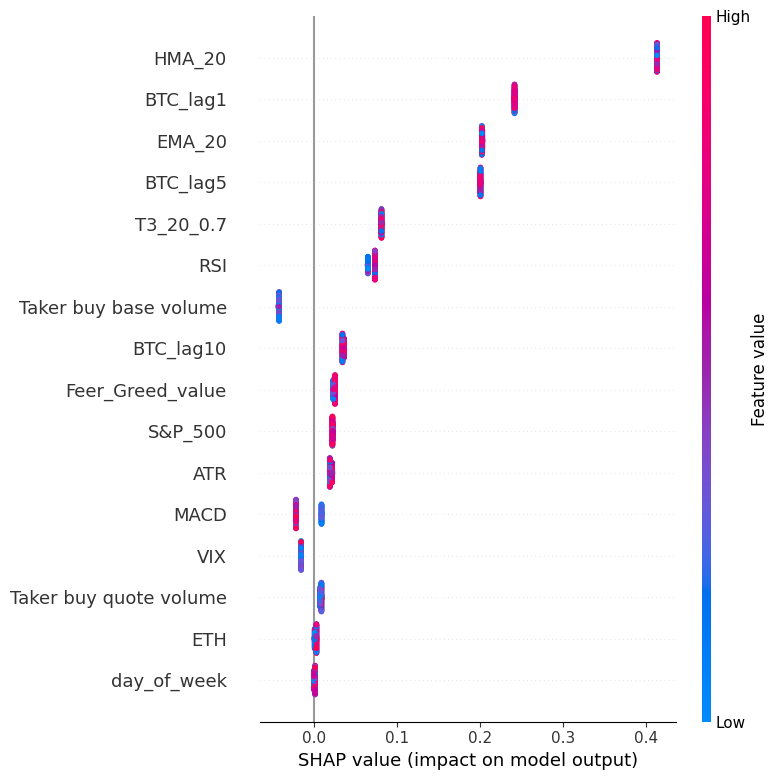

In [50]:
model = lgbm_day.model_.best_estimator_.regressor_.named_steps['stack'].estimators_[0]
# 6. Инициализация SHAP и вычисление SHAP-значений
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(lgbm_day.X_test)

# 7. Визуализация важности признаков (бар-плот)
shap.summary_plot(shap_values, lgbm_day.X_test, plot_type='bar');
# 8. Точечный summary-плот (dot plot)
shap.summary_plot(shap_values, lgbm_day.X_test);

# недельные

из всех метрик решил оставить только топ-30 по корреляции с таргетом, т.к. слишком мало наблюдений для такого большого количества объясняющих переменных

In [52]:
# cols_week = [
#     name for name in cols if name in week.columns
# ]
# cols_week = list(
#     set(cols_week) | set(week.corr().abs().BTC.sort_values(ascending=False)[1:16].index)
# )

weekly_features = [
    "BTC",
    'SMA_10',
    'KAMA_10_2_30', 
    'ALMA_8_6.0_0.85',
    'MicroStrategy',
    "ETH",
    "Fed_Funds_Rate",
    "CPI", "Gold",
    'NASDAQ_100',
    'S&P_500',
    'M2_Money_Supply',
    "VIX",
    "Taker buy base volume", 
    "Taker buy quote volume"
]
df_week = week[weekly_features]

X_week, y_week = df_week.drop(columns=['BTC']), df_week['BTC']

ridge_week = LinearForecaster(
    test_size=52,
)
ridge_week.fit(X_week, y_week)


lasso_week = LinearForecaster(
    test_size=52,
    model_type='Lasso'
)
lasso_week.fit(X_week, y_week)


elastic_week = LinearForecaster(
    test_size=52,
    model_type='ElasticNet'
)
elastic_week.fit(X_week, y_week)



[2025-05-11 06:27:45] Ridge начала обучаться


2025-05-11 06:27:48.322548: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746934068.341997 1761912 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746934068.347881 1761912 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-11 06:27:48.378639: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-11 06:27:51.640122: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: 


[2025-05-11 06:27:57] Ridge закончила обучаться

[2025-05-11 06:27:57] Lasso начала обучаться

[2025-05-11 06:27:59] Lasso закончила обучаться

[2025-05-11 06:27:59] ElasticNet начала обучаться

[2025-05-11 06:28:56] ElasticNet закончила обучаться


LinearForecaster(model_type='ElasticNet')

In [47]:
week.index.min(), week.index.max()

(Timestamp('2018-04-09 00:00:00'), Timestamp('2025-04-28 00:00:00'))

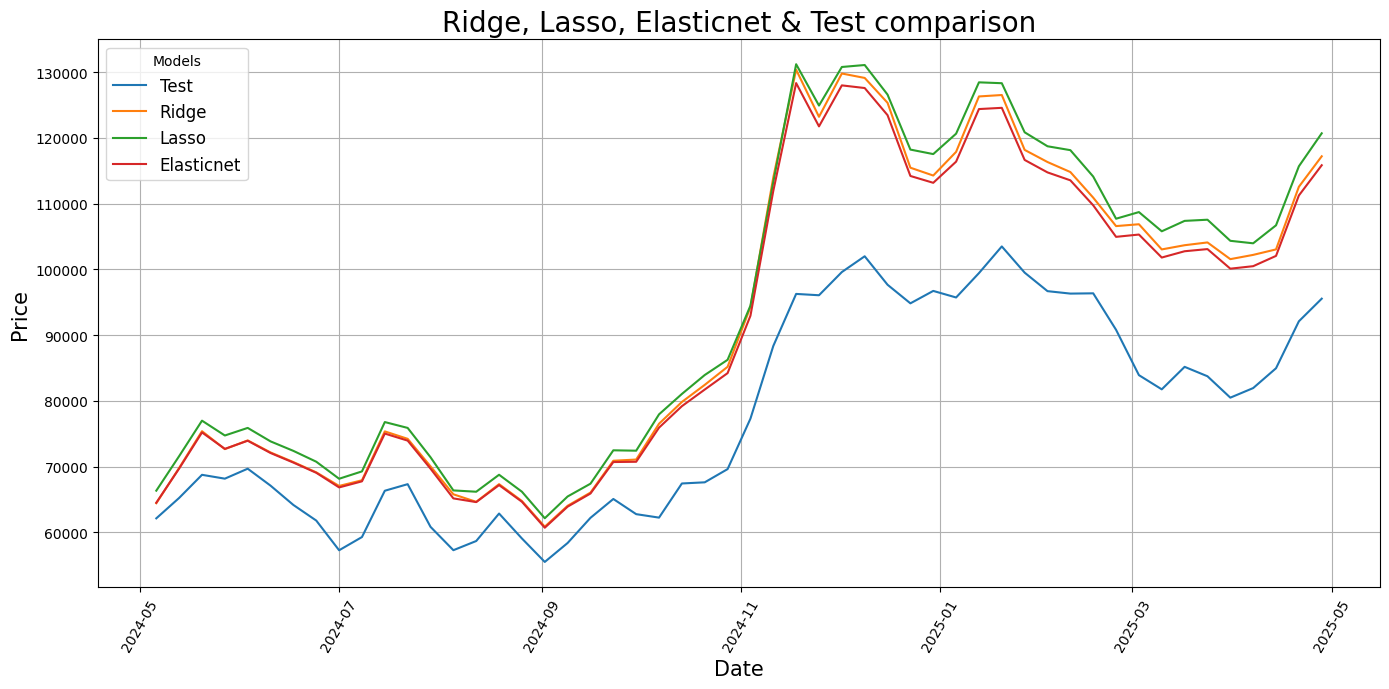

In [53]:
make_plot(models=[ridge_week, lasso_week, elastic_week], y=y_week)

In [54]:
lin_res_week = pd.DataFrame({
    'Ridge (Train)': ridge_week.result_.metrics['train'] ,
    'Ridge (Test)': ridge_week.result_.metrics['test'] ,

    'Lasso (Train)': lasso_week.result_.metrics['train'] ,
    'Lasso (Test)': lasso_week.result_.metrics['test'] ,

    'ElasticNet (Train)': elastic_week.result_.metrics['train'] ,
    'ElasticNet (Test)': elastic_week.result_.metrics['test'] ,
}, index=ridge_week.result_.metrics['train'].keys())

lin_res_week.index = map(lambda x: x.upper(), ridge_week.result_.metrics['train'].keys())
lin_res_week.loc['SMAPE'] = lin_res_week.loc['SMAPE'].apply(lambda smape: str(round(smape * 100, 4)) + '%')

lin_res_week

,Ridge (Train),Ridge (Test),Lasso (Train),Lasso (Test),ElasticNet (Train),ElasticNet (Test)
MAE,1861.39,14727.83,1862.43,16585.76,1832.88,13860.44
RMSE,2769.48,16890.09,2829.50,18622.82,2754.51,15821.36
SMAPE,9.8928%,16.1419%,9.8283%,18.1454%,10.0518%,15.3272%
MASE,1.36,10.73,1.36,12.08,1.34,10.10


### stack, weekly data

In [55]:
rf_week = StackingForecaster(
    test_size=52
)
rf_week.fit(X_week, y_week)

xgb_week = StackingForecaster(
    test_size=52,
    model_type='XGBoost',
)
xgb_week.fit(X_week, y_week)

lgbm_week = StackingForecaster(
    test_size=52,
    model_type='LightGBM'
)
lgbm_week.fit(X_week, y_week)


[2025-05-11 06:30:06] RandomForest начала обучаться


2025-05-11 06:30:12.387611: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-11 06:30:12.387611: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-11 06:30:12.402070: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746934212.404615 1762204 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746934212.404615 1762203 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:17469342


[2025-05-11 06:31:44] RandomForest закончила обучаться

[2025-05-11 06:31:44] XGBoost начала обучаться


2025-05-11 06:31:47.530311: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-11 06:31:47.542196: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746934307.550822 1777732 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746934307.557130 1777732 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
E0000 00:00:1746934307.562925 1777730 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746934307.569344 1777730 cuda_blas.cc:1


[2025-05-11 06:32:27] XGBoost закончила обучаться

[2025-05-11 06:32:27] LightGBM начала обучаться


2025-05-11 06:32:29.654891: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746934349.672639 1796945 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746934349.678071 1796945 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-11 06:32:29.696516: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-11 06:32:29.846727: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: 


[2025-05-11 06:32:49] LightGBM закончила обучаться


/home/user/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/user/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/user/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/user/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/user/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warni

StackingForecaster(model_type='LightGBM', test_size=52)

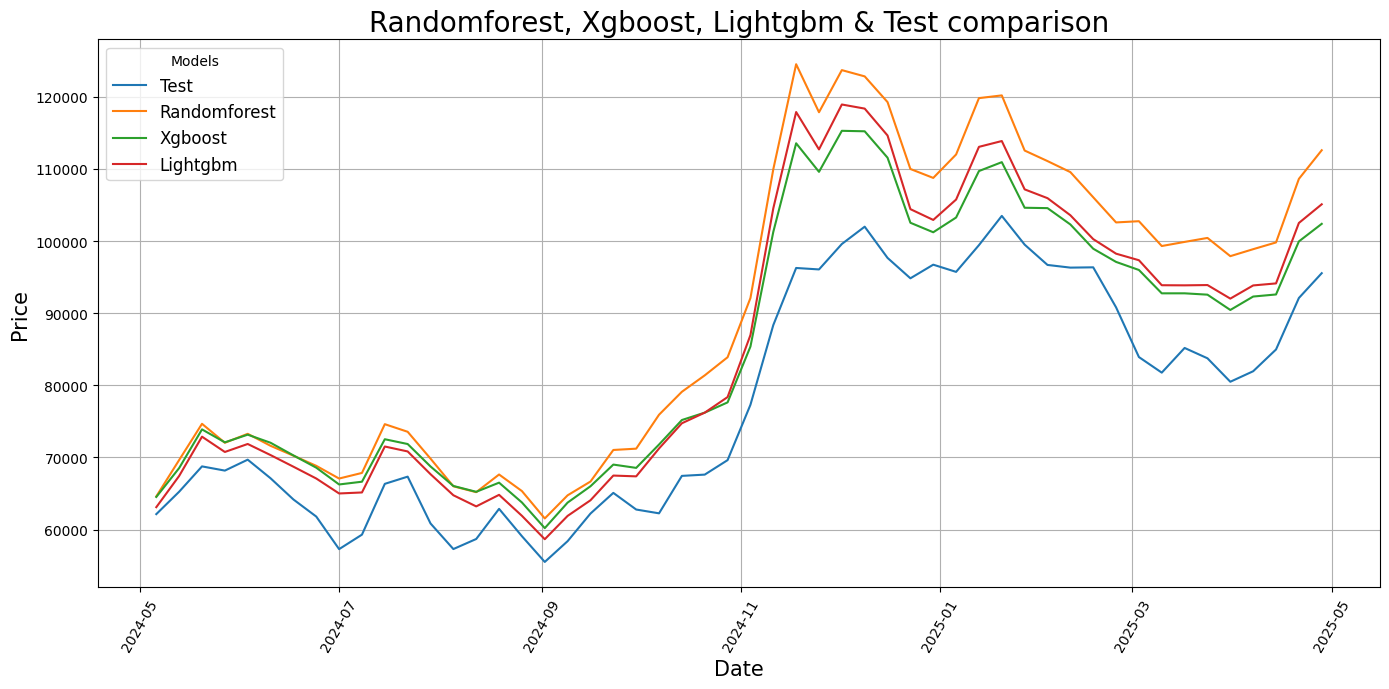

In [56]:
make_plot(models=[rf_week, xgb_week, lgbm_week], y=y_week)

In [57]:
stack_res_week = pd.DataFrame(
    data={
        'Random Forest (Train)':    rf_week.result_.metrics['train'],
        'Random Forest (Test)':     rf_week.result_.metrics['test'],

        'XGBoost (Train)':          xgb_week.result_.metrics['train'],
        'XGBoost (Test)':           xgb_week.result_.metrics['test'],
 
        'LightGBM (Train)':         lgbm_week.result_.metrics['train'],
        'LightGBM (Test)':          lgbm_week.result_.metrics['test'],
    },
)

stack_res_week.index = map(lambda x: x.upper(), rf_week.result_.metrics['train'].keys())
stack_res_week.loc['SMAPE'] = stack_res_week.loc['SMAPE'].apply(lambda smape: str(round(smape * 100, 4)) + '%')

stack_res_week

,Random Forest (Train),Random Forest (Test),XGBoost (Train),XGBoost (Test),LightGBM (Train),LightGBM (Test)
MAE,1651.69,12239.88,1400.01,7573.00,1603.99,8056.66
RMSE,2446.14,13683.01,2059.48,8272.17,2377.79,9384.60
SMAPE,9.3218%,13.9382%,8.4869%,9.2239%,9.169%,9.349%
MASE,1.20,8.92,1.02,5.52,1.17,5.87


In [ ]:
final_model_fi_week = stack_feature_importance([rf_week, xgb_week, lgbm_week])['final_model']\
                        .groupby(['model_type', 'feature'])\
                        .coefficient.last().reset_index()

lgbm_fi_week, rf_fi_week, xgb_fi_week = (
    final_model_fi[final_model_fi.model_type == 'LightGBM'].iloc[:, 1:],
    final_model_fi[final_model_fi.model_type == 'RandomForest'].iloc[:, 1:],
    final_model_fi[final_model_fi.model_type == 'XGBoost'].iloc[:, 1:],
)

In [ ]:
# cols_week = [
#     name for name in cols if name in day.columns
# ]
# cols_week = list(
#     set(cols_week) | set(week.corr().abs().BTC.sort_values(ascending=False)[1:16].index)
# )

# df_week = week[cols_week]

# X_week, y_week = df_week.drop(columns=['BTC']), df_week['BTC']

# ridge_week = LinearForecaster(
#     test_size=52,
# )
# ridge_week.fit(X_week, y_week)


# lasso_week = LinearForecaster(
#     test_size=52,
#     model_type='Lasso'
# )
# lasso_week.fit(X_week, y_week)


# elastic_week = LinearForecaster(
#     test_size=52,
#     model_type='ElasticNet'
# )
# elastic_week.fit(X_week, y_week)


## часовые

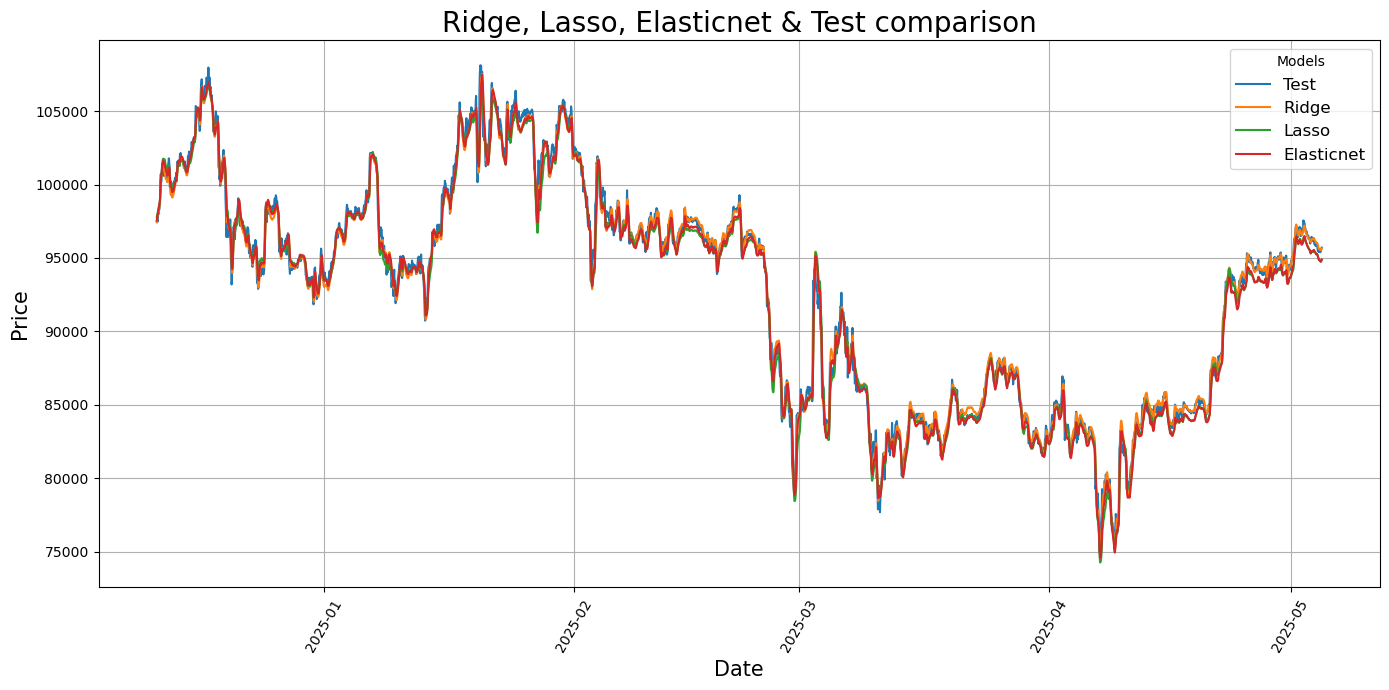

In [ ]:
# make_plot(models=[ridge_hour, lasso_hour, elastic_hour], y=y_hour)

In [ ]:
# lin_res_hour = pd.DataFrame({
#     'Ridge (Train)': ridge_hour.result_.metrics['train'] ,
#     'Ridge (Test)': ridge_hour.result_.metrics['test'] ,

#     'Lasso (Train)': lasso_hour.result_.metrics['train'] ,
#     'Lasso (Test)': lasso_hour.result_.metrics['test'] ,

#     'ElasticNet (Train)': elastic_hour.result_.metrics['train'] ,
#     'ElasticNet (Test)': elastic_hour.result_.metrics['test'] ,
# }, index=ridge.result_.metrics['train'].keys())

# lin_res_hour.index = map(lambda x: x.upper(), ridge.result_.metrics['train'].keys())
# lin_res_hour.loc['SMAPE'] = lin_res_hour.loc['SMAPE'].apply(lambda smape: str(round(smape * 100, 4)) + '%')

# lin_res_hour

,Ridge (Train),Ridge (Test),Lasso (Train),Lasso (Test),ElasticNet (Train),ElasticNet (Test)
MAE,193.36,411.41,244.20,565.24,214.23,499.79
RMSE,294.31,568.20,363.47,744.41,314.50,648.79
SMAPE,0.3696%,0.4452%,0.4821%,0.6145%,0.4273%,0.5447%
MASE,1.40,2.98,1.77,4.09,1.55,3.62


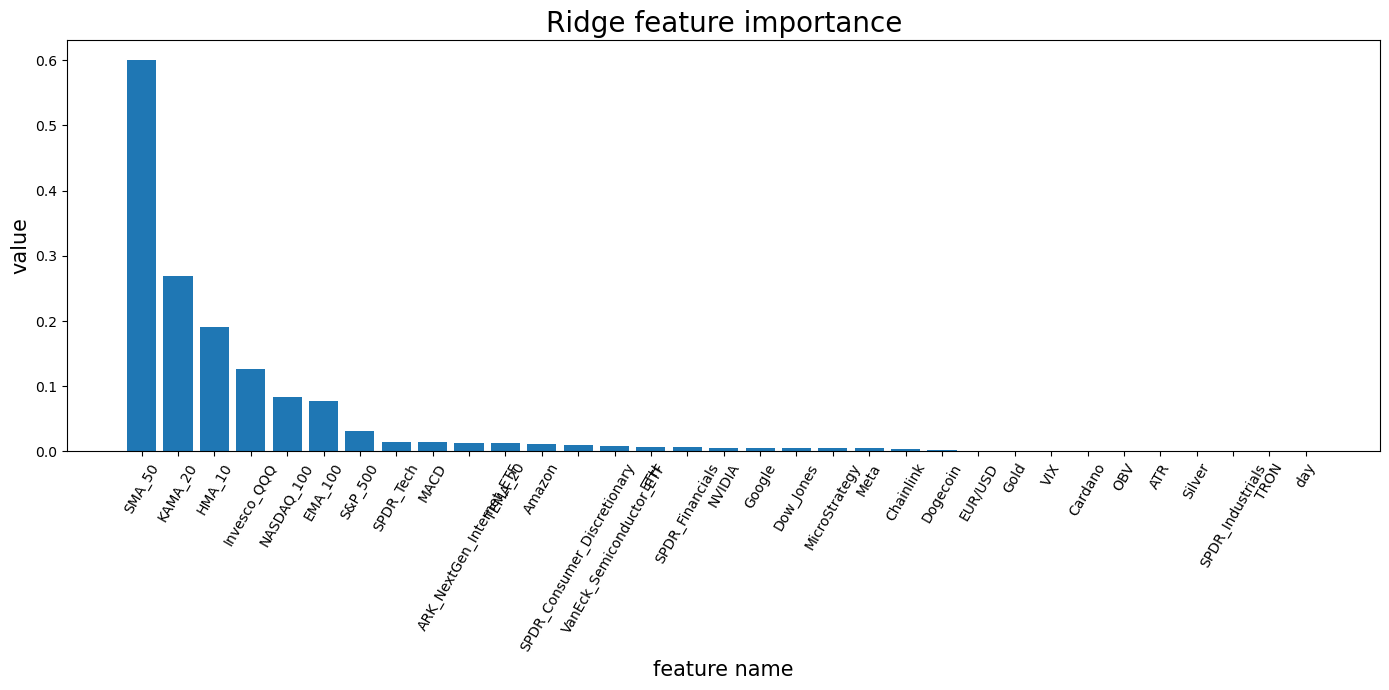

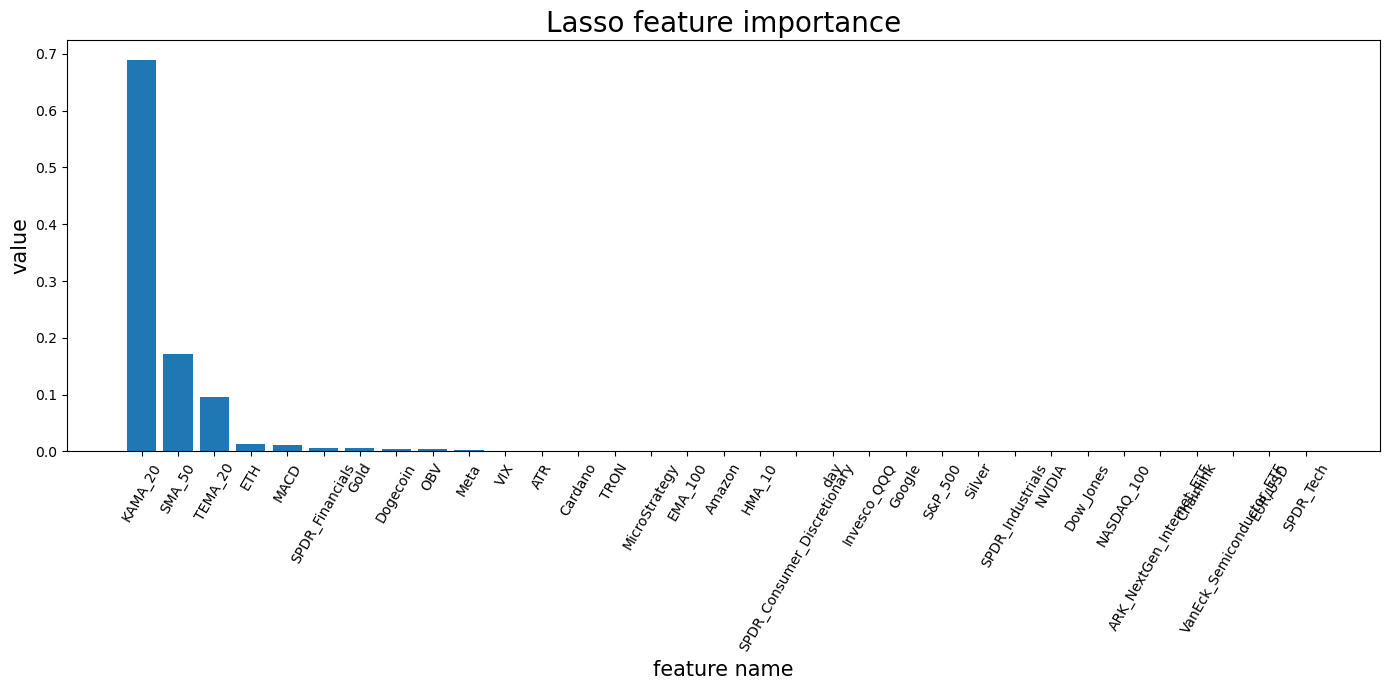

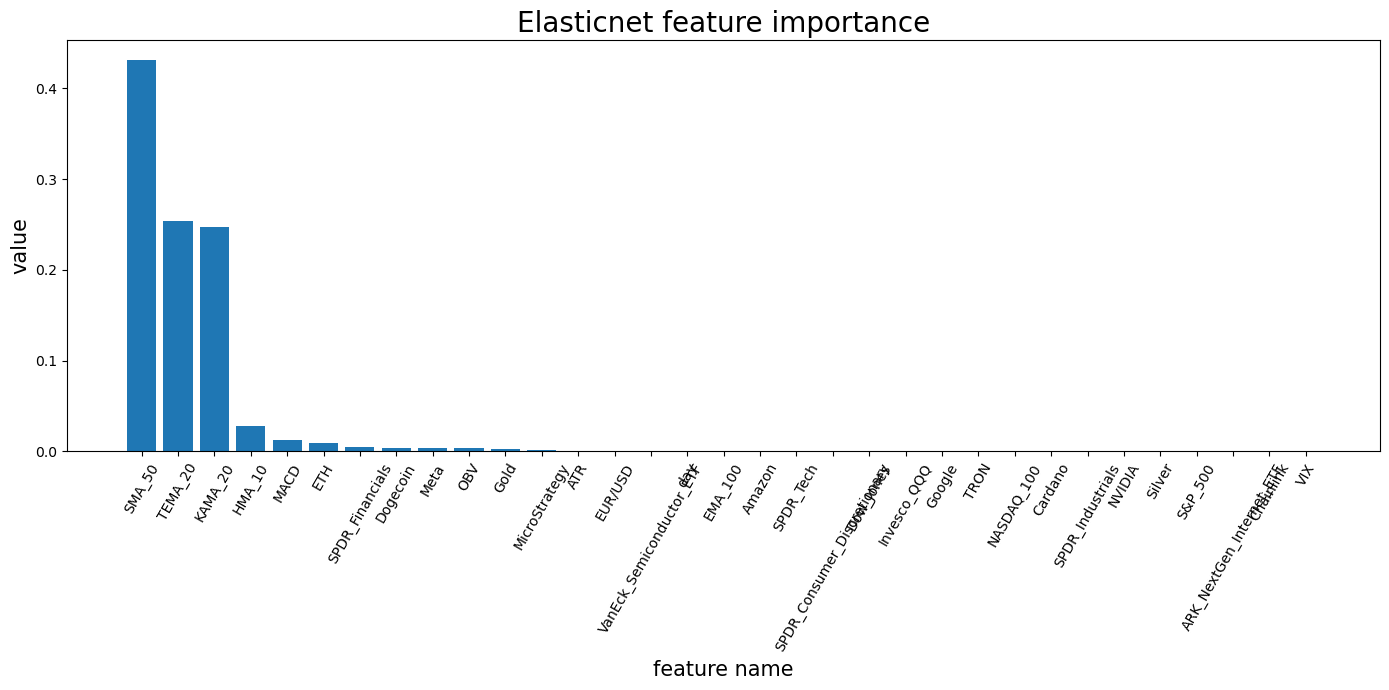

In [ ]:
# ridge_hour_fi = get_feature_importance(model=ridge_hour, X=X_hour)
# lasso_hour_fi = get_feature_importance(model=lasso_hour, X=X_hour)
# elastic_hour_fi = get_feature_importance(model=elastic_hour, X=X_hour)